In [2]:
print("hello world")

hello world


# Multimodal Biomarker Feature Importance Analysis for rTMS in Alzheimer's Disease

## Phase 1: Binary Classification Analysis

This notebook implements a comprehensive machine learning pipeline to identify predictive biomarkers for treatment response in Alzheimer's Disease patients undergoing repetitive Transcranial Magnetic Stimulation (rTMS).

### Objectives
- **Data Preparation**: Load and preprocess clinical and neuroimaging data
- **Feature Analysis**: Statistical analysis of feature-target relationships
- **Model Training**: Train and evaluate L1 Logistic Regression, Random Forest, and XGBoost classifiers
- **Interpretation**: Extract feature importance using coefficients, permutation importance, and SHAP values

### Target Variable
- **Declined (1)**: Patients who declined after treatment (positive class)
- **Improved (0)**: Patients who improved after treatment (negative class)

---


## 1. Environment Setup

Check system resources and Python environment configuration.


In [3]:
import psutil, platform, os

print("Python:", platform.python_version())
print("OS:", platform.system(), platform.release())
print("CPU count (logical):", psutil.cpu_count())
print("Total RAM (GB):", round(psutil.virtual_memory().total / 1e9, 2))

# Disk space (works on both Windows and Linux)
disk = psutil.disk_usage(os.getcwd())
print(f"Disk free (GB): {round(disk.free / 1e9, 2)}")



Python: 3.12.12
OS: Linux 6.6.105+
CPU count (logical): 2
Total RAM (GB): 13.61
Disk free (GB): 79.44


## 2. Data Loading

Mount Google Drive and set up the project directory.


In [4]:
import os
import platform

# ============================================================
# CONFIGURATION: Set your data path here
# ============================================================
# Option 1: Google Drive Desktop App (syncs to local folder)
#   - Windows default: "G:/My Drive/..." or "C:/Users/<username>/Google Drive/..."
#   - Find your path in File Explorer where Google Drive syncs
#
# Option 2: Download data locally to this project folder
# ============================================================

if platform.system() == "Windows":
    # Local path to Google Drive folder
    PROJECT_DIR = r"D:\My Drive\Dr_Moussavi"
else:
    # Colab / Linux path
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT_DIR = "/content/drive/MyDrive/Dr_Moussavi"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"\nFiles in project directory:")
for f in os.listdir(".")[:20]:  # Show first 20 files
    print(f"  {f}")


Mounted at /content/drive
Working directory: /content/drive/MyDrive/Dr_Moussavi

Files in project directory:
  Studies Papers
  Project
  Notes
  Dataset
  docker
  Presentation
  model_params_generic_soft
  plots_l1_confusion_matrices_l1.png
  plots_l1_metrics_main_vs_diag_l1.png
  plots_l1_probability_distribution_l1.png
  plots_l1_probability_distribution_l1_diag.png
  plots_l1_l1_coeffs_odds_l1.png
  plots_l1_l1_vs_diag_coeffs_l1.png
  plots_l1_perm_importance_l1.png
  plots_l1_shap_summary_l1.png
  plots_rf_confusion_matrices_rf.png
  plots_l1_shap_dependence_l1.png
  plots_l1_shap_force_sample0_l1.html
  plots_xgb_probability_distribution_xgb.png
  plots_xgb_confusion_matrices_xgb.png


### 2.1 Verify Data Path


In [5]:
print(os.path.abspath('../Dr_Moussavi/Dataset/Combined_v6_Updated.xlsx'))
print(os.path.exists('../Dr_Moussavi/Dataset/Combined_v6_Updated.xlsx'))


/content/drive/MyDrive/Dr_Moussavi/Dataset/Combined_v6_Updated.xlsx
True


## 3. Data Preparation

### 3.1 Load and Filter Dataset

Load the Excel dataset and create filtered dataframes for different analysis groups:
- **Active Group (R2/R4)**: Patients receiving active rTMS treatment
- **Sham Group (S4)**: Patients receiving sham treatment
- **Combined (Active + Sham)**: All patients

For each group, we create:
- Binary classification targets (threshold 0 and threshold 1)
- Multiclass classification targets


In [6]:
import pandas as pd
import numpy as np
import io
import contextlib
import sys

class TeeStdout:
    def __init__(self, *streams):
        self.streams = streams
    def write(self, data):
        for s in self.streams:
            s.write(data)
    def flush(self):
        for s in self.streams:
            s.flush()

# -------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------
df = pd.read_excel('../Dr_Moussavi/Dataset/Combined_v6_Updated.xlsx')
# print(df.shape)
# print(df['w5_change_binary_one_threshold'].value_counts(dropna=False))

# -------------------------------------------------------------------
# 2. DATA CLEANING AND PREPARATION PIPELINE Active
# -------------------------------------------------------------------

print("\nActive\n" + "="*50)
# -------------------------------------------------------------------
# Active
# Binary class target 0
features_to_keep_binary_0= [
    'Age at Enrollment',
    'Gender',
    'CDR',
    'MoCA',
    'CSDD',
    'HIS_2_Threshold',
    'Norm_V_R_DLPFC_GM',
    'Norm_V_L_DLPFC_GM',
    'Norm_V_R_DLPFC_WM',
    'Norm_V_L_DLPFC_WM',
    'GM_Asymmetry_Index',
    'WM_Asymmetry_Index',
    'Norm_WMH',
    'Norm_WMH_FL',
    'Norm_WMH_R_DLPFC_mm',
    'Norm_WMH_L_DLPFC_mm',
    'w5_change_binary_zero_threshold'
]

df_binary_0_a = df[
    df['w5_change_binary_zero_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['R2', 'R4'])
][features_to_keep_binary_0].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Active Binary class target 0:")
print(df_binary_0_a.shape)
print(df_binary_0_a['w5_change_binary_zero_threshold'].value_counts(dropna=False))
# df_binary_0_a

# -------------------------------------------------------------------
# Binary class target 1
features_to_keep_binary_1 = [
    'Age at Enrollment',
    'Gender',
    'CDR',
    'MoCA',
    'CSDD',
    'HIS_2_Threshold',
    'Norm_V_R_DLPFC_GM',
    'Norm_V_L_DLPFC_GM',
    'Norm_V_R_DLPFC_WM',
    'Norm_V_L_DLPFC_WM',
    'GM_Asymmetry_Index',
    'WM_Asymmetry_Index',
    'Norm_WMH',
    'Norm_WMH_FL',
    'Norm_WMH_R_DLPFC_mm',
    'Norm_WMH_L_DLPFC_mm',
    'w5_change_binary_one_threshold'
]

df_binary_1_a = df[
    df['w5_change_binary_one_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['R2', 'R4'])
][features_to_keep_binary_1].copy().reset_index(drop=True)


print("\n" + "-"*50)
print("Active Binary class target 1:")
print(df_binary_1_a.shape)
print(df_binary_1_a['w5_change_binary_one_threshold'].value_counts(dropna=False))
# df_binary_1_a

# -------------------------------------------------------------------
# Multiclass target
features_to_keep_multi = [
    'Age at Enrollment',
    'Gender',
    'CDR',
    'MoCA',
    'CSDD',
    'HIS_2_Threshold',
    'Norm_V_R_DLPFC_GM',
    'Norm_V_L_DLPFC_GM',
    'Norm_V_R_DLPFC_WM',
    'Norm_V_L_DLPFC_WM',
    'GM_Asymmetry_Index',
    'WM_Asymmetry_Index',
    'Norm_WMH',
    'Norm_WMH_FL',
    'Norm_WMH_R_DLPFC_mm',
    'Norm_WMH_L_DLPFC_mm',
    'w5_change_multiclass_one_threshold'
]

df_multiclass_1_a = df[
    df['w5_change_multiclass_one_threshold'].isin(['Declined', 'Improved', 'No Change']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['R2', 'R4'])
][features_to_keep_multi].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Active Multi class target 1:")
print(df_multiclass_1_a.shape)
print(df_multiclass_1_a['w5_change_multiclass_one_threshold'].value_counts(dropna=False))
# df_multiclass_1_a

print("\nSham\n" + "="*50)
# -------------------------------------------------------------------
# Sham

# -------------------------------------------------------------------
# Binary class target 0
df_binary_0_s = df[
    df['w5_change_binary_zero_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4'])
][features_to_keep_binary_0].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Sham Binary class target 0:")
print(df_binary_0_s.shape)
print(df_binary_0_s['w5_change_binary_zero_threshold'].value_counts(dropna=False))
# df_binary_0_s

# -------------------------------------------------------------------
# Binary class target 1
df_binary_1_s = df[
    df['w5_change_binary_one_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4'])
][features_to_keep_binary_1].copy().reset_index(drop=True)


print("\n" + "-"*50)
print("Sham Binary class target 1:")
print(df_binary_1_s.shape)
print(df_binary_1_s['w5_change_binary_one_threshold'].value_counts(dropna=False))
# df_binary_1_s

# -------------------------------------------------------------------
# Multiclass target
df_multiclass_1_s = df[
    df['w5_change_multiclass_one_threshold'].isin(['Declined', 'Improved', 'No Change']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4'])
][features_to_keep_multi].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Sham Multi class target 1:")
print(df_multiclass_1_s.shape)
print(df_multiclass_1_s['w5_change_multiclass_one_threshold'].value_counts(dropna=False))
# df_multiclass_1_s

print("\nActive + Sham\n" + "="*50)
# -------------------------------------------------------------------
# Active + Sham

# -------------------------------------------------------------------
# Binary class target 0
df_binary_0_as = df[
    df['w5_change_binary_zero_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4', 'R2', 'R4'])
][features_to_keep_binary_0].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Active + Sham Binary class target 0:")
print(df_binary_0_as.shape)
print(df_binary_0_as['w5_change_binary_zero_threshold'].value_counts(dropna=False))
# df_binary_0_as

# -------------------------------------------------------------------
# Binary class target 1
df_binary_1_as = df[
    df['w5_change_binary_one_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4', 'R2', 'R4'])
][features_to_keep_binary_1].copy().reset_index(drop=True)


print("\n" + "-"*50)
print("Active + Sham Binary class target 1:")
print(df_binary_1_as.shape)
print(df_binary_1_as['w5_change_binary_one_threshold'].value_counts(dropna=False))
# df_binary_1_as

# -------------------------------------------------------------------
# Multiclass target
df_multiclass_1_as = df[
    df['w5_change_multiclass_one_threshold'].isin(['Declined', 'Improved', 'No Change']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4', 'R2', 'R4'])
][features_to_keep_multi].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Active + Sham Multi class target 1:")
print(df_multiclass_1_as.shape)
print(df_multiclass_1_as['w5_change_multiclass_one_threshold'].value_counts(dropna=False))
# df_multiclass_1_as


Active

--------------------------------------------------
Active Binary class target 0:
(74, 17)
w5_change_binary_zero_threshold
Improved    52
Declined    22
Name: count, dtype: int64

--------------------------------------------------
Active Binary class target 1:
(58, 17)
w5_change_binary_one_threshold
Improved    46
Declined    12
Name: count, dtype: int64

--------------------------------------------------
Active Multi class target 1:
(74, 17)
w5_change_multiclass_one_threshold
Improved     46
No Change    16
Declined     12
Name: count, dtype: int64

Sham

--------------------------------------------------
Sham Binary class target 0:
(35, 17)
w5_change_binary_zero_threshold
Improved    20
Declined    15
Name: count, dtype: int64

--------------------------------------------------
Sham Binary class target 1:
(28, 17)
w5_change_binary_one_threshold
Improved    19
Declined     9
Name: count, dtype: int64

--------------------------------------------------
Sham Multi class target 1

### 3.2 Display Settings


In [7]:
pd.set_option("display.max_rows", None)        # or a large number like 500
pd.set_option("display.max_columns", None)     # show all columns
pd.set_option("display.width", 0)              # auto-detect width
pd.set_option("display.max_colwidth", None)    # don't truncate column content

### 3.3 Preview Data

Preview the Active group binary threshold 1 dataset.


In [8]:
df_binary_1_a.head()

,Age at Enrollment,Gender,CDR,MoCA,CSDD,HIS_2_Threshold,Norm_V_R_DLPFC_GM,Norm_V_L_DLPFC_GM,Norm_V_R_DLPFC_WM,Norm_V_L_DLPFC_WM,GM_Asymmetry_Index,WM_Asymmetry_Index,Norm_WMH,Norm_WMH_FL,Norm_WMH_R_DLPFC_mm,Norm_WMH_L_DLPFC_mm,w5_change_binary_one_threshold
0,72,Male,2.0,18,6,Low,0.000448,0.000590,0.000330,0.000369,13.614104,5.633923,0.002573,0.001169,0.000000e+00,2.033586e-07,Improved
1,73,Male,1.0,14,17,High,0.000527,0.000497,0.000309,0.000340,2.953389,4.818165,0.012035,0.005307,8.251911e-06,6.787590e-07,Improved
2,82,Male,1.0,22,8,High,0.000386,0.000557,0.000354,0.000228,18.101388,21.619925,0.002469,0.000849,0.000000e+00,1.690165e-08,Improved
3,79,Male,1.0,13,2,High,0.000357,0.000436,0.000478,0.000368,10.011159,13.016158,0.014435,0.005184,5.188485e-06,9.031499e-08,Improved
4,63,Female,1.0,16,4,Low,0.000401,0.000446,0.000351,0.000308,5.324107,6.537135,0.005075,0.002065,3.259019e-07,8.283270e-07,Improved


### 3.4 Encode Target and Binary Features

Encode categorical variables for modeling:
- **Target**: Declined → 1 (positive class), Improved → 0 (negative class)
- **Gender**: Male → 1, Female → 0
- **HIS_2_Threshold**: High → 1, Low → 0


In [9]:
# -------------------------------------------------------------------
# 1. DATA PREPARATION (Using loaded df_binary_1_a)
# -------------------------------------------------------------------
print("--- Phase 1 Analysis: Active Group (R2/R4), Extreme Threshold ---")

# Create a working copy to avoid SettingWithCopy warnings
df_analysis_binary_1_a = df_binary_1_a.copy()

print(f"Total Samples: {len(df_analysis_binary_1_a)}")
print("Original Target Counts:")
print(df_analysis_binary_1_a['w5_change_binary_one_threshold'].value_counts())

# --- ENCODING ---
# 1. Target: Declined (Positive Class) = 1, Improved (Negative Class) = 0
target_map = {'Declined': 1, 'Improved': 0}
df_analysis_binary_1_a['w5_change_binary_one_threshold'] = df_analysis_binary_1_a['w5_change_binary_one_threshold'].map(target_map)

# 2. Binary Features Encoding
# Check actual values in your DF to ensure mapping is correct
# Assuming Gender is 'Male'/'Female' and HIS is 'High'/'Low'
gender_map = {'Male': 1, 'Female': 0}
his_map = {'High': 1, 'Low': 0}

# Safe mapping (handles potential variations if needed, but assumes standard)
if 'Gender' in df_analysis_binary_1_a.columns:
    df_analysis_binary_1_a['Gender'] = df_analysis_binary_1_a['Gender'].map(gender_map)
if 'HIS_2_Threshold' in df_analysis_binary_1_a.columns:
    df_analysis_binary_1_a['HIS_2_Threshold'] = df_analysis_binary_1_a['HIS_2_Threshold'].map(his_map)


--- Phase 1 Analysis: Active Group (R2/R4), Extreme Threshold ---
Total Samples: 58
Original Target Counts:
w5_change_binary_one_threshold
Improved    46
Declined    12
Name: count, dtype: int64


### 3.5 Verify Encoded Data


In [10]:
df_analysis_binary_1_a.head(3)

,Age at Enrollment,Gender,CDR,MoCA,CSDD,HIS_2_Threshold,Norm_V_R_DLPFC_GM,Norm_V_L_DLPFC_GM,Norm_V_R_DLPFC_WM,Norm_V_L_DLPFC_WM,GM_Asymmetry_Index,WM_Asymmetry_Index,Norm_WMH,Norm_WMH_FL,Norm_WMH_R_DLPFC_mm,Norm_WMH_L_DLPFC_mm,w5_change_binary_one_threshold
0,72,1,2.0,18,6,0,0.000448,0.000590,0.000330,0.000369,13.614104,5.633923,0.002573,0.001169,0.000000,2.033586e-07,0
1,73,1,1.0,14,17,1,0.000527,0.000497,0.000309,0.000340,2.953389,4.818165,0.012035,0.005307,0.000008,6.787590e-07,0
2,82,1,1.0,22,8,1,0.000386,0.000557,0.000354,0.000228,18.101388,21.619925,0.002469,0.000849,0.000000,1.690165e-08,0


---

## 4. Exploratory Data Analysis

### 4.1 Descriptive Statistics by Target Class

Summary statistics for each feature grouped by outcome (Improved vs Declined).


In [ ]:
# Use groupby and describe to summarize numeric features for each group:
grouped_stats = df_analysis_binary_1_a.groupby("w5_change_binary_one_threshold").describe().T
grouped_stats.to_csv("grouped_stats_full.csv")
print(grouped_stats)


w5_change_binary_one_threshold             0             1
Age at Enrollment   count       4.600000e+01  1.200000e+01
                    mean        7.267391e+01  7.500000e+01
                    std         8.080303e+00  6.755469e+00
                    min         5.500000e+01  6.600000e+01
                    25%         6.900000e+01  6.925000e+01
                    50%         7.400000e+01  7.600000e+01
                    75%         7.800000e+01  7.875000e+01
                    max         8.900000e+01  8.600000e+01
Gender              count       4.600000e+01  1.200000e+01
                    mean        5.652174e-01  5.000000e-01
                    std         5.012063e-01  5.222330e-01
                    min         0.000000e+00  0.000000e+00
                    25%         0.000000e+00  0.000000e+00
                    50%         1.000000e+00  5.000000e-01
                    75%         1.000000e+00  1.000000e+00
                    max         1.000000e+00  1.000000e+

### 4.2 Train/Test Split

Create stratified train/test split to preserve class distribution.


In [ ]:
from sklearn.model_selection import train_test_split
# 3. Define X and y
# Drop the target columns
cols_to_drop = ['w5_change_binary_one_threshold']
# Only drop if they exist
X = df_analysis_binary_1_a.drop(columns=[c for c in cols_to_drop if c in df_analysis_binary_1_a.columns])
y = df_analysis_binary_1_a['w5_change_binary_one_threshold']

# Handle any remaining NaNs (e.g. if mapping failed or missing values existed)
if X.isnull().values.any():
    print("Warning: NaN values found in features. Imputing with median/mode...")
    X = X.fillna(X.median(numeric_only=True))
    # For binary columns that might be NaN after mapping
    for col in ['Gender', 'HIS_2_Threshold']:
        if col in X.columns:
             X[col] = X[col].fillna(X[col].mode()[0])

# 4. Train/Test Split
# Using 20% split. With 12 positives, this puts ~2-3 in test set.
# Stratify is crucial for small, imbalanced data.
RND = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RND
)

print("-" * 30)
print(f"Train Shape: {X_train.shape}, Positives (Decliners): {y_train.sum()}, Negatives (Improvers): {len(y_train) - y_train.sum()}")
print(f"Test Shape: {X_test.shape}, Positives (Decliners): {y_test.sum()}, Negatives (Improvers): {len(y_test) - y_test.sum()}")
print("-" * 30)

------------------------------
Train Shape: (46, 16), Positives (Decliners): 10, Negatives (Improvers): 36
Test Shape: (12, 16), Positives (Decliners): 2, Negatives (Improvers): 10
------------------------------


### 4.3 Gender Distribution by Outcome


In [ ]:
gender_counts = df_analysis_binary_1_a.groupby(['w5_change_binary_one_threshold', 'Gender']).size().unstack(fill_value=0)
display(gender_counts)

Gender,0,1
w5_change_binary_one_threshold,,
0,20,26
1,6,6


---

## 5. Statistical Feature Analysis

Univariate statistical analysis to assess feature-target relationships:
- **Pearson Correlation**: Linear relationship strength
- **Spearman Correlation**: Monotonic relationship strength  
- **Phi Coefficient**: Association between binary variables
- **Univariate ROC-AUC**: Discriminative power of individual features
- **Mutual Information**: Non-linear dependency measure


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
# --------------------- STATISTICAL ANALYSES ---------------------

# 1) Pearson (rank by absolute value, print signed)
print("Calculating Pearson...")
pearson = X.corrwith(y, method="pearson")
pearson_abs_ranked = pearson.loc[pearson.abs().sort_values(ascending=False).index]

# 2) Spearman (rank by absolute value, print signed)
print("Calculating Spearman...")
spearman = X.corrwith(y, method="spearman")
spearman_abs_ranked = spearman.loc[spearman.abs().sort_values(ascending=False).index]

# 3) Phi coefficient for Gender & HIS vs target (Pearson on two binaries)
print("Calculating Phi...")
phi_features = {}
for binary_col in ["Gender", "HIS_2_Threshold"]:
    if binary_col in X.columns:
        # Pearson corr on two binary vars IS the Phi coefficient
        phi_val = X[binary_col].corr(y, method="pearson")
        phi_features[binary_col] = phi_val

phi_series = pd.Series(phi_features)
phi_abs_ranked = phi_series.loc[phi_series.abs().sort_values(ascending=False).index]

# 4) Univariate ROC AUC and signed AUC per feature
print("Calculating Univariate AUC...")
auc = {}
signed_auc = {}
for col in X.columns:
    xi = X[col]
    yi = y

    # Skip constants or single-class slices (cannot calc AUC)
    if xi.nunique() <= 1 or yi.nunique() <= 1:
        auc[col] = np.nan
        signed_auc[col] = np.nan
        continue
    try:
        a = roc_auc_score(yi, xi)
        auc[col] = a
        signed_auc[col] = 2 * (a - 0.5)  # [-1, 1], sign indicates direction
    except Exception as e:
        print(f"Could not calc AUC for {col}: {e}")
        auc[col] = np.nan
        signed_auc[col] = np.nan

auc = pd.Series(auc)
signed_auc = pd.Series(signed_auc)

# Rank AUC by |AUC - 0.5| (print raw AUC in that order)
auc_absdev_rank_idx = (auc - 0.5).abs().sort_values(ascending=False).index
auc_absdev_ranked = auc.loc[auc_absdev_rank_idx]

# Rank signed AUC by absolute value (print signed)
signed_auc_abs_ranked = signed_auc.loc[signed_auc.abs().sort_values(ascending=False).index]

# 5) Mutual Information (non-linear dependency) (rank by absolute value, print value)
print("Calculating Mutual Information...")
# Identify discrete features for MI (Gender and HIS_2_Threshold are binary/discrete)
discrete_cols = ["Gender", "HIS_2_Threshold"]
discrete_mask = [col in discrete_cols for col in X.columns]

mi_vals = mutual_info_classif(X.values, y.values, discrete_features=discrete_mask, random_state=42)
mi = pd.Series(mi_vals, index=X.columns)
mi_abs_ranked = mi.sort_values(ascending=False)


# --------------------- PRINT RESULTS ---------------------
print("\n" + "="*60)
print("STATISTICAL ANALYSIS RESULTS (Active Group, Declined=1)")
print("="*60)

print("\n--- [PEARSON] (Linear Correlation) ---")
print("Ranked by Magnitude (|r|), showing signed value:")
print(pearson_abs_ranked.to_string())

print("\n--- [SPEARMAN] (Monotonic Correlation) ---")
print("Ranked by Magnitude (|rho|), showing signed value:")
print(spearman_abs_ranked.to_string())

print("\n--- [PHI COEFFICIENT] (Binary vs Binary) ---")
print("Ranked by Magnitude (|phi|):")
print(phi_abs_ranked.to_string())

print("\n--- [Univariate ROC AUC] (Discriminative Power) ---")
print("Ranked by Separation Power (|AUC - 0.5|), showing raw AUC:")
print(auc_absdev_ranked.to_string())

print("\n--- [Signed AUC] (Directional Discrimination) ---")
print("Ranked by Magnitude (|Signed AUC|), showing signed value:")
print(signed_auc_abs_ranked.to_string())

print("\n--- [MUTUAL INFORMATION] (Non-Linear Dependency) ---")
print("Ranked by Information Gain (Higher is better):")
print(mi_abs_ranked.to_string())
print("="*60)

Calculating Pearson...
Calculating Spearman...
Calculating Phi...
Calculating Univariate AUC...
Calculating Mutual Information...

STATISTICAL ANALYSIS RESULTS (Active Group, Declined=1)

--- [PEARSON] (Linear Correlation) ---
Ranked by Magnitude (|r|), showing signed value:
GM_Asymmetry_Index    -0.290904
HIS_2_Threshold        0.175820
Norm_V_R_DLPFC_GM      0.156287
Norm_V_R_DLPFC_WM      0.124682
Age at Enrollment      0.121442
Norm_V_L_DLPFC_WM      0.096783
CDR                    0.083162
Norm_WMH_R_DLPFC_mm   -0.073946
Norm_WMH               0.070450
WM_Asymmetry_Index     0.061167
Gender                -0.053122
Norm_WMH_L_DLPFC_mm   -0.046042
Norm_V_L_DLPFC_GM      0.042655
CSDD                   0.034988
Norm_WMH_FL            0.030957
MoCA                   0.002868

--- [SPEARMAN] (Monotonic Correlation) ---
Ranked by Magnitude (|rho|), showing signed value:
GM_Asymmetry_Index    -0.300013
Norm_WMH               0.277130
Norm_WMH_FL            0.223738
Norm_WMH_R_DLPFC_mm  

---

## 5.1 ANOVA Feature Selection

Analysis of Variance (ANOVA) F-test to identify features with significant differences between outcome groups. Features with low F-scores (high p-values) may be redundant and candidates for removal.

**Interpretation:**
- **High F-score**: Feature shows significant variance between groups → potentially predictive
- **Low F-score / High p-value**: Feature does not discriminate between groups → candidate for removal


In [ ]:
from sklearn.feature_selection import f_classif, SelectKBest
from scipy import stats

# ============================================================
# ANOVA F-test for Feature Selection
# ============================================================

# Get feature matrix and target (using the encoded data)
X_anova = df_analysis_binary_1_a.drop(columns=['w5_change_binary_one_threshold'])
y_anova = df_analysis_binary_1_a['w5_change_binary_one_threshold']

# Compute ANOVA F-scores and p-values
f_scores, p_values = f_classif(X_anova, y_anova)

# Create results DataFrame
anova_results = pd.DataFrame({
    'Feature': X_anova.columns,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

# Add significance indicator
anova_results['Significant'] = anova_results['P_Value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)

print("=" * 70)
print("ANOVA F-TEST RESULTS")
print("=" * 70)
print("\nFeatures ranked by F-score (higher = more discriminative):\n")
print(anova_results.to_string(index=False))

# Identify potentially redundant features (p > 0.1)
redundant_features = anova_results[anova_results['P_Value'] > 0.1]['Feature'].tolist()
significant_features = anova_results[anova_results['P_Value'] < 0.05]['Feature'].tolist()

print("\n" + "-" * 70)
print(f"\n✓ Significant features (p < 0.05): {significant_features if significant_features else 'None'}")
print(f"\n⚠ Potentially redundant features (p > 0.1): {redundant_features if redundant_features else 'None'}")
print("\n" + "=" * 70)


ANOVA F-TEST RESULTS

Features ranked by F-score (higher = more discriminative):

            Feature  F_Score  P_Value Significant
 GM_Asymmetry_Index 5.177123 0.026734           *
    HIS_2_Threshold 1.786322 0.186780            
  Norm_V_R_DLPFC_GM 1.402085 0.241376            
  Norm_V_R_DLPFC_WM 0.884301 0.351065            
  Age at Enrollment 0.838260 0.363821            
  Norm_V_L_DLPFC_WM 0.529509 0.469845            
                CDR 0.389988 0.534842            
Norm_WMH_R_DLPFC_mm 0.307888 0.581189            
           Norm_WMH 0.279327 0.599231            
 WM_Asymmetry_Index 0.210303 0.648305            
             Gender 0.158474 0.692079            
Norm_WMH_L_DLPFC_mm 0.118963 0.731454            
  Norm_V_L_DLPFC_GM 0.102073 0.750545            
               CSDD 0.068636 0.794294            
        Norm_WMH_FL 0.053718 0.817561            
               MoCA 0.000460 0.982956            

-------------------------------------------------------------------

---

## 5.1.0 Feature Directionality Analysis

Understanding **which direction** each feature pushes the prediction:
- **↑ Higher → Declined**: Higher values of this feature are associated with worse outcomes
- **↓ Higher → Improved**: Higher values of this feature are associated with better outcomes

### Method:
- Compare mean feature values between Declined (1) and Improved (0) groups
- Calculate **Cohen's d** effect size to quantify the magnitude of difference

### Why This Matters:
- ANOVA/ANCOVA tell you IF a feature differs between groups
- This tells you HOW it differs (direction)
- Essential for clinical interpretation (e.g., "higher GM asymmetry predicts decline")


FEATURE DIRECTIONALITY ANALYSIS
Comparing mean feature values: Declined (1) vs Improved (0)
----------------------------------------------------------------------

📊 FEATURE DIRECTION TABLE:

            Feature  Mean_Declined  Mean_Improved  Effect_Size           Direction Effect_Magnitude
 GM_Asymmetry_Index   5.169638e+00       9.784565    -0.711921 ↓ Higher → Improved           Medium
    HIS_2_Threshold   5.833333e-01       0.369565     0.430278 ↑ Higher → Declined            Small
  Norm_V_R_DLPFC_GM   4.656245e-04       0.000438     0.382477 ↑ Higher → Declined            Small
  Norm_V_R_DLPFC_WM   4.096031e-04       0.000389     0.305131 ↑ Higher → Declined            Small
  Age at Enrollment   7.500000e+01      72.673913     0.297201 ↑ Higher → Declined            Small
  Norm_V_L_DLPFC_WM   3.587346e-04       0.000343     0.236854 ↑ Higher → Declined            Small
                CDR   1.166667e+00       1.097826     0.203520 ↑ Higher → Declined            Small
Norm_WMH

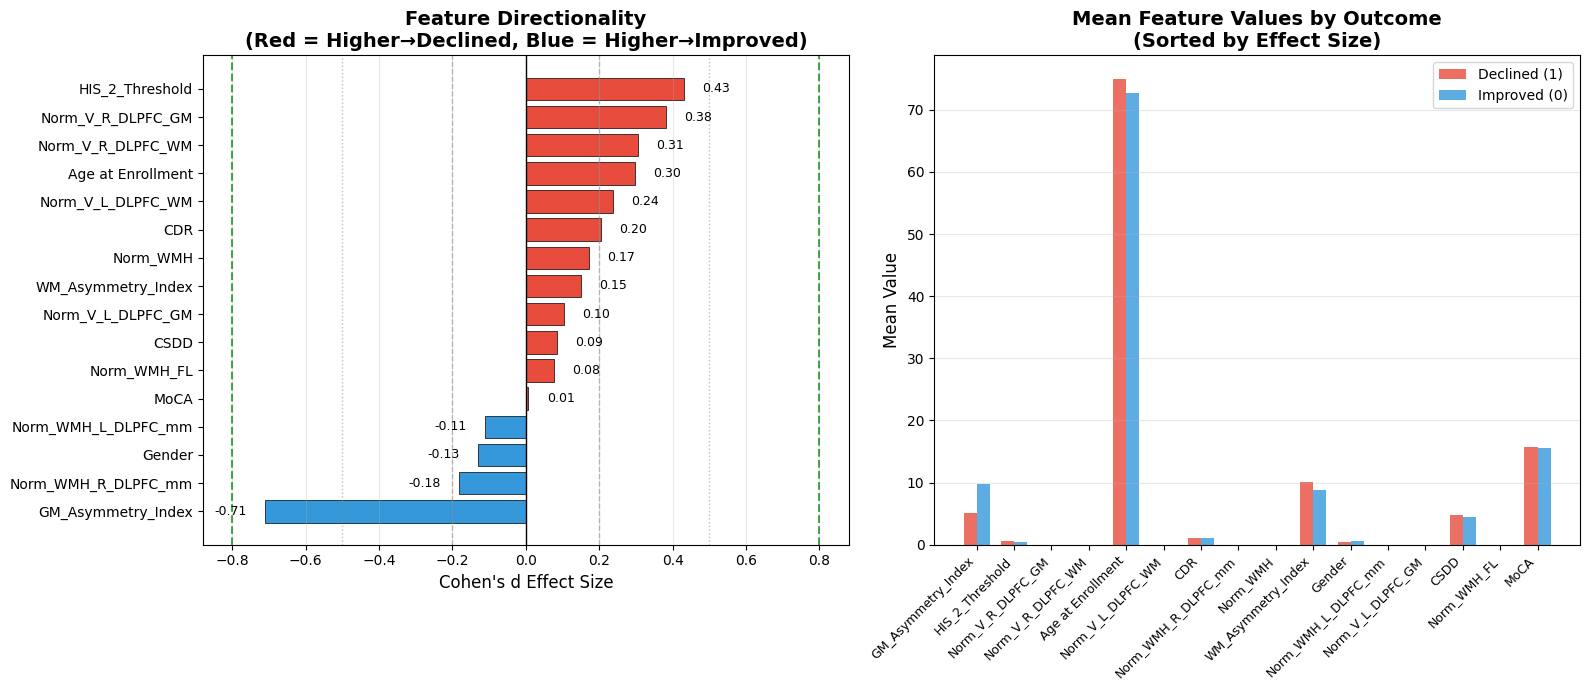


✓ Plot saved: feature_directionality.png

----------------------------------------------------------------------

📋 INTERPRETATION GUIDE:
   ↑ Higher → Declined: Higher values associated with worse outcome
   ↓ Higher → Improved: Higher values associated with better outcome

   Effect Size Thresholds (Cohen's d):
   |d| > 0.8 = Large | |d| > 0.5 = Medium | |d| > 0.2 = Small

🔍 NOTABLE EFFECTS (|d| > 0.5):
   • GM_Asymmetry_Index: d=-0.71 (↓ Higher → Improved)

✓ Stored: FEATURE_DIRECTIONS, FEATURE_EFFECT_SIZES


In [ ]:
# ============================================================
# FEATURE DIRECTIONALITY: Which direction predicts Decline?
# ============================================================
import matplotlib.pyplot as plt

print("=" * 70)
print("FEATURE DIRECTIONALITY ANALYSIS")
print("=" * 70)
print("Comparing mean feature values: Declined (1) vs Improved (0)")
print("-" * 70)

# Group by target
grouped = df_analysis_binary_1_a.groupby('w5_change_binary_one_threshold')

# Calculate means for each group
means = grouped.mean()
declined_means = means.loc[1]  # Target = 1 (Declined)
improved_means = means.loc[0]  # Target = 0 (Improved)

# Create direction DataFrame
direction_df = pd.DataFrame({
    'Feature': declined_means.index,
    'Mean_Declined': declined_means.values,
    'Mean_Improved': improved_means.values
})

# Calculate difference and direction
direction_df['Difference'] = direction_df['Mean_Declined'] - direction_df['Mean_Improved']
direction_df['Direction'] = direction_df['Difference'].apply(
    lambda d: '↑ Higher → Declined' if d > 0 else '↓ Higher → Improved'
)

# Add effect size (Cohen's d)
# Using pooled standard deviation
pooled_std = df_analysis_binary_1_a.drop(columns=['w5_change_binary_one_threshold']).std()
direction_df['Effect_Size'] = direction_df['Difference'] / pooled_std.values
direction_df['Abs_Effect'] = direction_df['Effect_Size'].abs()
direction_df['Effect_Magnitude'] = direction_df['Abs_Effect'].apply(
    lambda d: 'Large' if d > 0.8 else ('Medium' if d > 0.5 else ('Small' if d > 0.2 else 'Negligible'))
)

# Sort by absolute effect size
direction_df = direction_df.sort_values('Abs_Effect', ascending=False)

print("\n📊 FEATURE DIRECTION TABLE:\n")
display_cols = ['Feature', 'Mean_Declined', 'Mean_Improved', 'Effect_Size', 'Direction', 'Effect_Magnitude']
print(direction_df[display_cols].to_string(index=False))

# ============================================================
# Visualization: Direction and Effect Size
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Effect size bar chart (sorted)
ax1 = axes[0]
plot_data = direction_df.sort_values('Effect_Size', ascending=True)

# Color by direction
colors = ['#e74c3c' if d > 0 else '#3498db' for d in plot_data['Effect_Size']]

ax1.barh(plot_data['Feature'], plot_data['Effect_Size'], color=colors, edgecolor='black', linewidth=0.5)
ax1.axvline(x=0, color='black', linewidth=1)
ax1.axvline(x=0.2, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=-0.2, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=-0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=0.8, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
ax1.axvline(x=-0.8, color='green', linestyle='--', alpha=0.7, linewidth=1.5)

ax1.set_xlabel("Cohen's d Effect Size", fontsize=12)
ax1.set_title("Feature Directionality\n(Red = Higher→Declined, Blue = Higher→Improved)",
              fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add effect size labels
for i, (feat, es) in enumerate(zip(plot_data['Feature'], plot_data['Effect_Size'])):
    offset = 0.05 if es >= 0 else -0.05
    ha = 'left' if es >= 0 else 'right'
    ax1.text(es + offset, i, f'{es:.2f}', va='center', ha=ha, fontsize=9)

# Right: Grouped bar chart (means comparison)
ax2 = axes[1]
x_pos = np.arange(len(direction_df))
width = 0.35

# Sort by effect size for consistency
plot_data2 = direction_df.sort_values('Abs_Effect', ascending=False)

bars1 = ax2.bar(x_pos - width/2, plot_data2['Mean_Declined'], width,
                label='Declined (1)', color='#e74c3c', alpha=0.8)
bars2 = ax2.bar(x_pos + width/2, plot_data2['Mean_Improved'], width,
                label='Improved (0)', color='#3498db', alpha=0.8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(plot_data2['Feature'], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Mean Value', fontsize=12)
ax2.set_title('Mean Feature Values by Outcome\n(Sorted by Effect Size)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_directionality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved: feature_directionality.png")

# ============================================================
# Summary
# ============================================================
print("\n" + "-" * 70)
print("\n📋 INTERPRETATION GUIDE:")
print("   ↑ Higher → Declined: Higher values associated with worse outcome")
print("   ↓ Higher → Improved: Higher values associated with better outcome")
print("\n   Effect Size Thresholds (Cohen's d):")
print("   |d| > 0.8 = Large | |d| > 0.5 = Medium | |d| > 0.2 = Small")

# Highlight key findings
large_effects = direction_df[direction_df['Abs_Effect'] > 0.5]
if not large_effects.empty:
    print(f"\n🔍 NOTABLE EFFECTS (|d| > 0.5):")
    for _, row in large_effects.iterrows():
        print(f"   • {row['Feature']}: d={row['Effect_Size']:.2f} ({row['Direction']})")

# Store for later reference
FEATURE_DIRECTIONS = direction_df.set_index('Feature')['Direction'].to_dict()
FEATURE_EFFECT_SIZES = direction_df.set_index('Feature')['Effect_Size'].to_dict()

print(f"\n✓ Stored: FEATURE_DIRECTIONS, FEATURE_EFFECT_SIZES")
print("=" * 70)


---

## 5.1.1 ANCOVA Feature Analysis

**ANCOVA (Analysis of Covariance)** extends ANOVA by controlling for confounding variables (covariates). While ANOVA tests raw group differences, ANCOVA asks:

> "Does this feature still predict the outcome *after accounting for other variables*?"

### Three Variations Implemented:

1. **Standard ANCOVA (Age + Gender)**: Controls for demographic confounders
2. **Full ANCOVA (All Features)**: Each feature controlled for all others (experimental)
3. **Comparison**: Identifies features whose ANOVA significance changes after covariate adjustment

### Interpretation:
- **ANOVA significant → ANCOVA significant**: Robust predictor (effect is independent of covariates)
- **ANOVA significant → ANCOVA non-significant**: Confounded effect (demographics explain the relationship)
- **ANOVA non-significant → ANCOVA significant**: Suppressor effect (masked by covariates)
- **Both non-significant**: Likely not predictive


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import warnings

# ============================================================
# ANCOVA ANALYSIS - THREE VARIATIONS
# ============================================================

# Prepare data (using the same data as ANOVA)
ancova_df = df_analysis_binary_1_a.copy()
target_col = 'w5_change_binary_one_threshold'
feature_cols = [c for c in ancova_df.columns if c != target_col]

# Identify demographic covariates
DEMOGRAPHIC_COVARIATES = ['Age at Enrollment', 'Gender']
# Verify they exist
demographic_available = [c for c in DEMOGRAPHIC_COVARIATES if c in feature_cols]
print(f"Demographic covariates available: {demographic_available}")

# ============================================================
# Helper function for ANCOVA
# ============================================================
def run_ancova(data, feature, target, covariates):
    """
    Run ANCOVA for a single feature controlling for covariates.
    Returns F-statistic and p-value for the feature effect.

    Uses Type II Sum of Squares (standard for ANCOVA).
    """
    if feature in covariates:
        return np.nan, np.nan, "Feature is a covariate"

    # Build formula: target ~ feature + covariate1 + covariate2 + ...
    covariate_terms = ' + '.join([f'Q("{c}")' for c in covariates])
    formula = f'Q("{target}") ~ Q("{feature}") + {covariate_terms}'

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = ols(formula, data=data).fit()
            anova_table = anova_lm(model, typ=2)  # Type II SS

            # Extract feature effect (first row after intercept)
            feature_key = f'Q("{feature}")'
            if feature_key in anova_table.index:
                f_stat = anova_table.loc[feature_key, 'F']
                p_val = anova_table.loc[feature_key, 'PR(>F)']
                return f_stat, p_val, "OK"
            else:
                return np.nan, np.nan, "Feature not in table"
    except Exception as e:
        return np.nan, np.nan, str(e)

# ============================================================
# VARIATION 1: Standard ANCOVA (Age + Gender)
# ============================================================
print("=" * 70)
print("ANCOVA VARIATION 1: STANDARD (Age + Gender)")
print("=" * 70)
print(f"Covariates: {demographic_available}")
print("-" * 70)

ancova_standard_results = []
for feature in feature_cols:
    if feature in demographic_available:
        # Skip - this is a covariate
        continue

    f_stat, p_val, status = run_ancova(
        ancova_df, feature, target_col, demographic_available
    )

    ancova_standard_results.append({
        'Feature': feature,
        'F_Score_ANCOVA': f_stat,
        'P_Value_ANCOVA': p_val,
        'Status': status
    })

ancova_standard_df = pd.DataFrame(ancova_standard_results)
ancova_standard_df = ancova_standard_df.sort_values('F_Score_ANCOVA', ascending=False)
ancova_standard_df['Significant_ANCOVA'] = ancova_standard_df['P_Value_ANCOVA'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)

print("\nFeatures ranked by ANCOVA F-score (controlling for Age + Gender):\n")
print(ancova_standard_df[['Feature', 'F_Score_ANCOVA', 'P_Value_ANCOVA', 'Significant_ANCOVA']].to_string(index=False))

significant_ancova_std = ancova_standard_df[ancova_standard_df['P_Value_ANCOVA'] < 0.05]['Feature'].tolist()
print(f"\n✓ Significant after controlling for demographics: {significant_ancova_std if significant_ancova_std else 'None'}")

# ============================================================
# VARIATION 2: Full ANCOVA (Each feature vs All Others)
# ============================================================
print("\n" + "=" * 70)
print("ANCOVA VARIATION 2: FULL (Each Feature Controlled for All Others)")
print("=" * 70)
print("⚠ Note: May be unstable with many features or multicollinearity")
print("-" * 70)

ancova_full_results = []
for feature in feature_cols:
    # Use all OTHER features as covariates
    other_features = [f for f in feature_cols if f != feature]

    f_stat, p_val, status = run_ancova(
        ancova_df, feature, target_col, other_features
    )

    ancova_full_results.append({
        'Feature': feature,
        'F_Score_ANCOVA_Full': f_stat,
        'P_Value_ANCOVA_Full': p_val,
        'Status': status
    })

ancova_full_df = pd.DataFrame(ancova_full_results)
ancova_full_df = ancova_full_df.sort_values('F_Score_ANCOVA_Full', ascending=False)
ancova_full_df['Significant_ANCOVA_Full'] = ancova_full_df['P_Value_ANCOVA_Full'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '' if pd.notna(p) else 'N/A'))
)

print("\nFeatures ranked by Full ANCOVA F-score (each controlled for ALL others):\n")
print(ancova_full_df[['Feature', 'F_Score_ANCOVA_Full', 'P_Value_ANCOVA_Full', 'Significant_ANCOVA_Full']].to_string(index=False))

significant_ancova_full = ancova_full_df[ancova_full_df['P_Value_ANCOVA_Full'] < 0.05]['Feature'].tolist()
print(f"\n✓ Significant after controlling for ALL other features: {significant_ancova_full if significant_ancova_full else 'None'}")

print("\n" + "=" * 70)


Demographic covariates available: ['Age at Enrollment', 'Gender']
ANCOVA VARIATION 1: STANDARD (Age + Gender)
Covariates: ['Age at Enrollment', 'Gender']
----------------------------------------------------------------------

Features ranked by ANCOVA F-score (controlling for Age + Gender):

            Feature  F_Score_ANCOVA  P_Value_ANCOVA Significant_ANCOVA
 GM_Asymmetry_Index        5.049079        0.028748                  *
    HIS_2_Threshold        1.727632        0.194269                   
  Norm_V_R_DLPFC_WM        1.227512        0.272802                   
  Norm_V_R_DLPFC_GM        1.160726        0.286104                   
  Norm_V_L_DLPFC_WM        1.032738        0.314048                   
                CDR        0.417631        0.520859                   
Norm_WMH_R_DLPFC_mm        0.379920        0.540236                   
Norm_WMH_L_DLPFC_mm        0.125305        0.724728                   
 WM_Asymmetry_Index        0.081452        0.776431                 

In [ ]:
# ============================================================
# VARIATION 3: ANOVA vs ANCOVA COMPARISON
# ============================================================
# Connect ANCOVA results back to ANOVA to identify:
# - Robust features (significant in both)
# - Confounded features (ANOVA sig, ANCOVA not sig)
# - Suppressor features (ANOVA not sig, ANCOVA sig)

print("=" * 70)
print("ANCOVA VARIATION 3: COMPARISON WITH ANOVA")
print("=" * 70)
print("Identifying how covariate adjustment changes significance")
print("-" * 70)

# Merge ANOVA and ANCOVA results
# Use anova_results from previous cell
comparison_df = anova_results[['Feature', 'F_Score', 'P_Value', 'Significant']].copy()
comparison_df = comparison_df.rename(columns={
    'F_Score': 'ANOVA_F',
    'P_Value': 'ANOVA_P',
    'Significant': 'ANOVA_Sig'
})

# Add Standard ANCOVA (Age + Gender)
ancova_std_merge = ancova_standard_df[['Feature', 'F_Score_ANCOVA', 'P_Value_ANCOVA', 'Significant_ANCOVA']].copy()
ancova_std_merge = ancova_std_merge.rename(columns={
    'F_Score_ANCOVA': 'ANCOVA_Std_F',
    'P_Value_ANCOVA': 'ANCOVA_Std_P',
    'Significant_ANCOVA': 'ANCOVA_Std_Sig'
})
comparison_df = comparison_df.merge(ancova_std_merge, on='Feature', how='left')

# Add Full ANCOVA (All features)
ancova_full_merge = ancova_full_df[['Feature', 'F_Score_ANCOVA_Full', 'P_Value_ANCOVA_Full', 'Significant_ANCOVA_Full']].copy()
ancova_full_merge = ancova_full_merge.rename(columns={
    'F_Score_ANCOVA_Full': 'ANCOVA_Full_F',
    'P_Value_ANCOVA_Full': 'ANCOVA_Full_P',
    'Significant_ANCOVA_Full': 'ANCOVA_Full_Sig'
})
comparison_df = comparison_df.merge(ancova_full_merge, on='Feature', how='left')

# Classify each feature based on ANOVA vs ANCOVA(Standard) comparison
def classify_feature(row):
    anova_sig = row['ANOVA_P'] < 0.05 if pd.notna(row['ANOVA_P']) else False
    ancova_sig = row['ANCOVA_Std_P'] < 0.05 if pd.notna(row['ANCOVA_Std_P']) else False

    if anova_sig and ancova_sig:
        return "🟢 Robust (both sig)"
    elif anova_sig and not ancova_sig:
        return "🟡 Confounded (ANOVA only)"
    elif not anova_sig and ancova_sig:
        return "🔵 Suppressor (ANCOVA only)"
    else:
        return "⚪ Not significant"

comparison_df['Interpretation'] = comparison_df.apply(classify_feature, axis=1)

# Sort by ANOVA F-score
comparison_df = comparison_df.sort_values('ANOVA_F', ascending=False)

print("\n📊 FULL COMPARISON TABLE:\n")
display_cols = ['Feature', 'ANOVA_F', 'ANOVA_Sig', 'ANCOVA_Std_F', 'ANCOVA_Std_Sig',
                'ANCOVA_Full_F', 'ANCOVA_Full_Sig', 'Interpretation']
print(comparison_df[display_cols].to_string(index=False))

# Summary statistics
print("\n" + "-" * 70)
print("\n📋 INTERPRETATION SUMMARY:\n")

interpretation_counts = comparison_df['Interpretation'].value_counts()
for interp, count in interpretation_counts.items():
    features = comparison_df[comparison_df['Interpretation'] == interp]['Feature'].tolist()
    print(f"{interp}: {count} feature(s)")
    print(f"   → {features}")

# Highlight key findings
print("\n" + "-" * 70)
print("\n🔍 KEY FINDINGS:\n")

robust = comparison_df[comparison_df['Interpretation'].str.contains('Robust')]['Feature'].tolist()
confounded = comparison_df[comparison_df['Interpretation'].str.contains('Confounded')]['Feature'].tolist()
suppressor = comparison_df[comparison_df['Interpretation'].str.contains('Suppressor')]['Feature'].tolist()

if robust:
    print(f"✓ ROBUST PREDICTORS (independent of demographics):")
    print(f"   These features predict outcome regardless of Age/Gender: {robust}")

if confounded:
    print(f"\n⚠ CONFOUNDED FEATURES (effect explained by demographics):")
    print(f"   These features appeared significant but may be proxies for Age/Gender: {confounded}")

if suppressor:
    print(f"\n🔎 SUPPRESSOR FEATURES (hidden significance revealed):")
    print(f"   These features become significant when controlling for demographics: {suppressor}")

if not (robust or confounded or suppressor):
    print("   No features showed significant effects in either analysis.")

print("\n" + "=" * 70)


ANCOVA VARIATION 3: COMPARISON WITH ANOVA
Identifying how covariate adjustment changes significance
----------------------------------------------------------------------

📊 FULL COMPARISON TABLE:

            Feature  ANOVA_F ANOVA_Sig  ANCOVA_Std_F ANCOVA_Std_Sig  ANCOVA_Full_F ANCOVA_Full_Sig      Interpretation
 GM_Asymmetry_Index 5.177123         *      5.049079              *       7.328395              ** 🟢 Robust (both sig)
    HIS_2_Threshold 1.786322                1.727632                      2.080892                   ⚪ Not significant
  Norm_V_R_DLPFC_GM 1.402085                1.160726                      2.065957                   ⚪ Not significant
  Norm_V_R_DLPFC_WM 0.884301                1.227512                      0.919966                   ⚪ Not significant
  Age at Enrollment 0.838260                     NaN            NaN       0.181373                   ⚪ Not significant
  Norm_V_L_DLPFC_WM 0.529509                1.032738                      1.797945      

C:\Users\arshi\AppData\Local\Temp\ipykernel_4192\3920914601.py:73: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\arshi\AppData\Local\Temp\ipykernel_4192\3920914601.py:74: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('ancova_anova_comparison.png', dpi=150, bbox_inches='tight')
a:\QueensU\Research\2nd_Phase_Analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


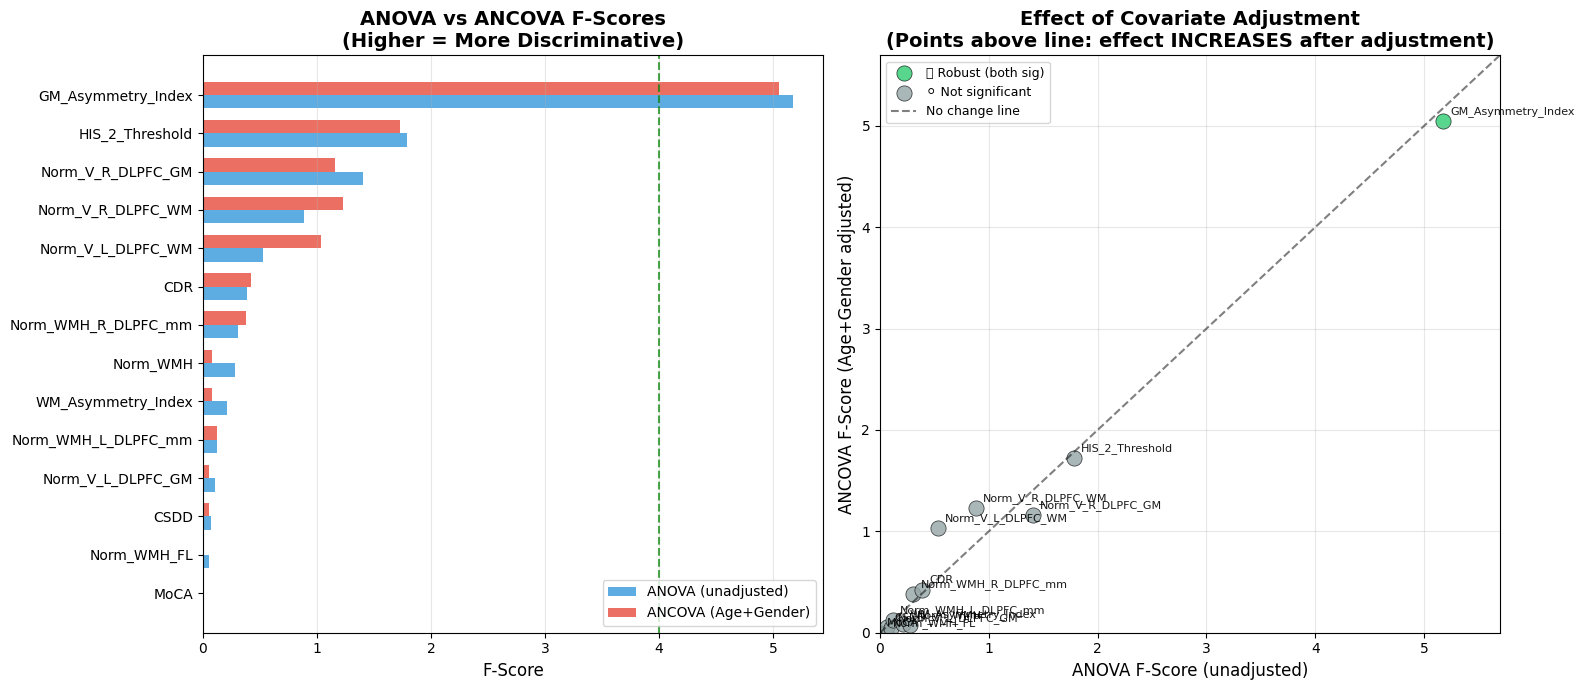

✓ Plot saved: ancova_anova_comparison.png

CONNECTING ANOVA AND ANCOVA: WHAT WE LEARNED

📌 ANOVA told us which features differ between groups (raw effect)
📌 ANCOVA tells us which effects are INDEPENDENT of demographics

INTERPRETATION FOR YOUR ML MODELS:
----------------------------------------------------------------------

1. PRIORITIZE these robust features in your models:
   ['GM_Asymmetry_Index']
   → These are true predictors, not confounded by Age/Gender

✓ Results stored in: ANCOVA_ROBUST_FEATURES, ANCOVA_CONFOUNDED_FEATURES, ANCOVA_SUPPRESSOR_FEATURES


In [ ]:
# ============================================================
# VISUALIZATION: ANOVA vs ANCOVA F-Score Comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Prepare data for plotting
plot_df = comparison_df.dropna(subset=['ANOVA_F', 'ANCOVA_Std_F']).copy()
plot_df = plot_df.sort_values('ANOVA_F', ascending=True)  # Sort for horizontal bar

# Define colors based on interpretation
color_map = {
    '🟢 Robust (both sig)': '#2ecc71',      # Green
    '🟡 Confounded (ANOVA only)': '#f39c12', # Orange
    '🔵 Suppressor (ANCOVA only)': '#3498db', # Blue
    '⚪ Not significant': '#95a5a6'           # Gray
}
colors = [color_map.get(interp, '#95a5a6') for interp in plot_df['Interpretation']]

# --- LEFT PLOT: Grouped Bar Chart ---
ax1 = axes[0]
y_pos = np.arange(len(plot_df))
bar_height = 0.35

bars1 = ax1.barh(y_pos - bar_height/2, plot_df['ANOVA_F'], bar_height,
                  label='ANOVA (unadjusted)', color='#3498db', alpha=0.8)
bars2 = ax1.barh(y_pos + bar_height/2, plot_df['ANCOVA_Std_F'], bar_height,
                  label='ANCOVA (Age+Gender)', color='#e74c3c', alpha=0.8)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(plot_df['Feature'], fontsize=10)
ax1.set_xlabel('F-Score', fontsize=12)
ax1.set_title('ANOVA vs ANCOVA F-Scores\n(Higher = More Discriminative)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.axvline(x=0, color='black', linewidth=0.5)
ax1.grid(axis='x', alpha=0.3)

# Add significance threshold line (F ~ 4 for α=0.05 with df ≈ 1, 50)
# This is approximate - actual threshold depends on degrees of freedom
ax1.axvline(x=4, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Approx. α=0.05')

# --- RIGHT PLOT: Scatter Plot (ANOVA vs ANCOVA) ---
ax2 = axes[1]

for interp, color in color_map.items():
    mask = plot_df['Interpretation'] == interp
    if mask.any():
        ax2.scatter(plot_df.loc[mask, 'ANOVA_F'],
                   plot_df.loc[mask, 'ANCOVA_Std_F'],
                   c=color, label=interp, s=120, alpha=0.8, edgecolors='black', linewidth=0.5)

        # Add labels
        for idx, row in plot_df[mask].iterrows():
            ax2.annotate(row['Feature'], (row['ANOVA_F'], row['ANCOVA_Std_F']),
                        textcoords="offset points", xytext=(5, 5), fontsize=8, alpha=0.9)

# Add diagonal reference line (ANOVA = ANCOVA)
max_val = max(plot_df['ANOVA_F'].max(), plot_df['ANCOVA_Std_F'].max()) * 1.1
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='No change line')

ax2.set_xlabel('ANOVA F-Score (unadjusted)', fontsize=12)
ax2.set_ylabel('ANCOVA F-Score (Age+Gender adjusted)', fontsize=12)
ax2.set_title('Effect of Covariate Adjustment\n(Points above line: effect INCREASES after adjustment)',
              fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max_val)
ax2.set_ylim(0, max_val)

plt.tight_layout()
plt.savefig('ancova_anova_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot saved: ancova_anova_comparison.png")

# ============================================================
# FINAL SUMMARY: What ANCOVA Tells Us About ANOVA Results
# ============================================================
print("\n" + "=" * 70)
print("CONNECTING ANOVA AND ANCOVA: WHAT WE LEARNED")
print("=" * 70)

print("\n📌 ANOVA told us which features differ between groups (raw effect)")
print("📌 ANCOVA tells us which effects are INDEPENDENT of demographics\n")

print("INTERPRETATION FOR YOUR ML MODELS:")
print("-" * 70)

if robust:
    print(f"\n1. PRIORITIZE these robust features in your models:")
    print(f"   {robust}")
    print("   → These are true predictors, not confounded by Age/Gender")

if confounded:
    print(f"\n2. BE CAUTIOUS with these confounded features:")
    print(f"   {confounded}")
    print("   → Their ANOVA significance may be due to demographic differences")
    print("   → Consider removing or including Age/Gender as covariates in models")

if suppressor:
    print(f"\n3. DON'T OVERLOOK these suppressor features:")
    print(f"   {suppressor}")
    print("   → They become important when demographics are controlled")
    print("   → May be valuable in models that include Age/Gender")

# Store key results for downstream use
ANCOVA_ROBUST_FEATURES = robust
ANCOVA_CONFOUNDED_FEATURES = confounded
ANCOVA_SUPPRESSOR_FEATURES = suppressor

print(f"\n✓ Results stored in: ANCOVA_ROBUST_FEATURES, ANCOVA_CONFOUNDED_FEATURES, ANCOVA_SUPPRESSOR_FEATURES")
print("=" * 70)


---

## 5.1.2 PCA-Based Feature Ranking (Variance Contribution)

**Principal Component Analysis (PCA)** identifies features that contribute most to data variance. While PCA is typically used for dimensionality reduction, we use it here for **feature ranking**:

### Approach:
1. Fit PCA on standardized features
2. Calculate each feature's **loading** on each principal component
3. Weight loadings by explained variance ratio
4. Rank features by their **total variance contribution**

### Interpretation:
- **High contribution**: Feature captures significant data variance (informative)
- **Low contribution**: Feature adds little unique information (potentially redundant)

> **Note**: High variance contribution doesn't guarantee predictive power. This complements ANOVA/ANCOVA which test target-relationship.


PCA-BASED FEATURE RANKING (Variance Contribution)

📊 EXPLAINED VARIANCE BY COMPONENT:

   PC 1:  21.2% | Cumulative:  21.2% | ██████████
   PC 2:  14.3% | Cumulative:  35.5% | ███████
   PC 3:  11.7% | Cumulative:  47.2% | █████
   PC 4:   9.1% | Cumulative:  56.2% | ████
   PC 5:   8.6% | Cumulative:  64.9% | ████
   PC 6:   6.9% | Cumulative:  71.8% | ███
   PC 7:   6.4% | Cumulative:  78.1% | ███
   PC 8:   5.6% | Cumulative:  83.7% | ██
   PC 9:   5.4% | Cumulative:  89.2% | ██
   PC10:   4.0% | Cumulative:  93.2% | ██
   PC11:   2.8% | Cumulative:  96.0% | █
   ... (5 more components for remaining 4.0%)

✓ Components needed for 95% variance: 11

----------------------------------------------------------------------

📋 FEATURE RANKING BY VARIANCE CONTRIBUTION:

            Feature  Variance_Contribution  Variance_Contribution_Pct  PCA_Rank
               CSDD                 0.0625                       6.25         1
Norm_WMH_R_DLPFC_mm                 0.0625                      

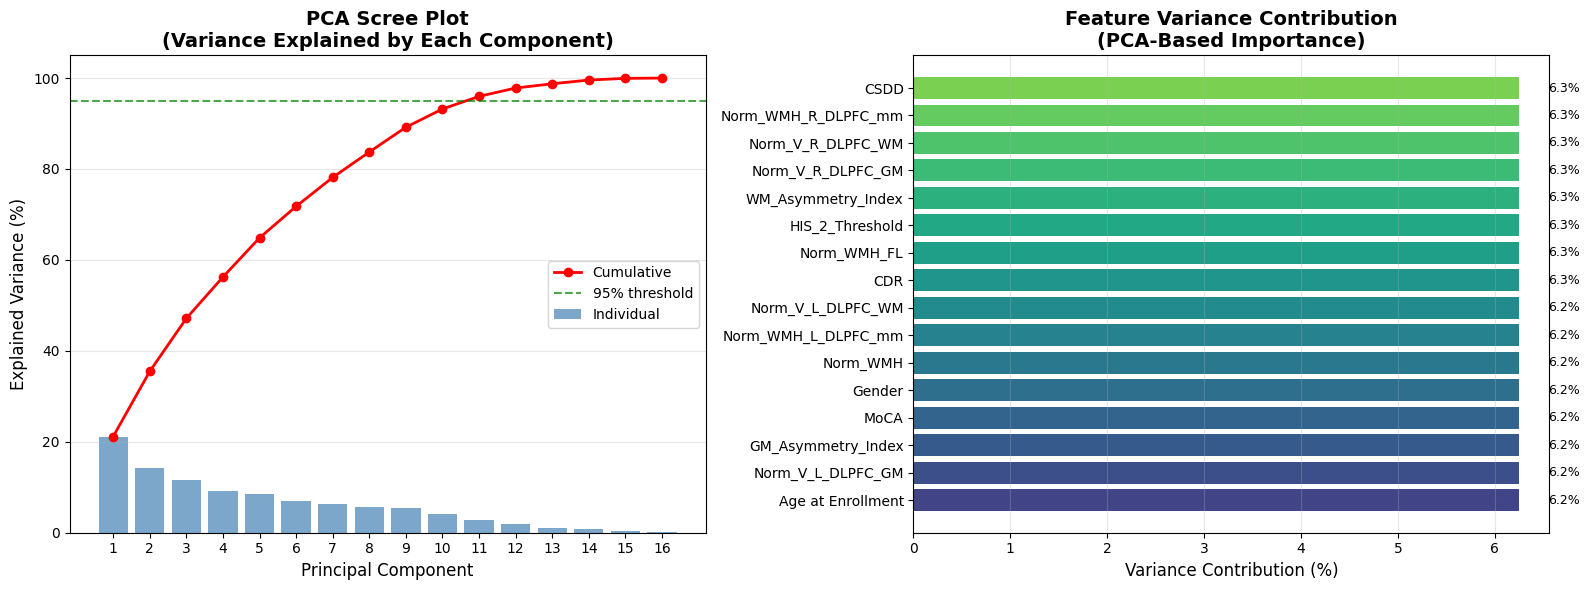


✓ Plot saved: pca_feature_ranking.png

----------------------------------------------------------------------

🔝 TOP 5 features by variance contribution: ['CSDD', 'Norm_WMH_R_DLPFC_mm', 'Norm_V_R_DLPFC_WM', 'Norm_V_R_DLPFC_GM', 'WM_Asymmetry_Index']
🔻 BOTTOM 5 features by variance contribution: ['Gender', 'MoCA', 'GM_Asymmetry_Index', 'Norm_V_L_DLPFC_GM', 'Age at Enrollment']

✓ PCA rankings stored in: PCA_FEATURE_RANKING


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ============================================================
# PCA-BASED FEATURE RANKING
# ============================================================

# Prepare data
X_pca = df_analysis_binary_1_a.drop(columns=['w5_change_binary_one_threshold'])
feature_names_pca = X_pca.columns.tolist()

# Standardize features (required for meaningful PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Fit PCA (keep all components for analysis)
pca = PCA()
pca.fit(X_scaled)

print("=" * 70)
print("PCA-BASED FEATURE RANKING (Variance Contribution)")
print("=" * 70)

# ============================================================
# 1. Explained Variance by Component
# ============================================================
print("\n📊 EXPLAINED VARIANCE BY COMPONENT:\n")
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
for i, (var, cum_var) in enumerate(zip(pca.explained_variance_ratio_, cumulative_var)):
    bar = "█" * int(var * 50)
    print(f"   PC{i+1:2d}: {var*100:5.1f}% | Cumulative: {cum_var*100:5.1f}% | {bar}")
    if cum_var > 0.95:  # Stop showing after 95% explained
        remaining = len(pca.explained_variance_ratio_) - i - 1
        if remaining > 0:
            print(f"   ... ({remaining} more components for remaining {(1-cum_var)*100:.1f}%)")
        break

# Number of components for 95% variance
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"\n✓ Components needed for 95% variance: {n_components_95}")

# ============================================================
# 2. Feature Loadings and Variance Contribution
# ============================================================
# Calculate feature importance as weighted sum of squared loadings
# Weight = explained variance ratio of each component

loadings = pca.components_.T  # Shape: (n_features, n_components)
variance_weights = pca.explained_variance_ratio_

# Weighted contribution: sum of (loading^2 * variance_ratio) across components
feature_variance_contribution = np.sum(loadings**2 * variance_weights, axis=1)

# Normalize to percentage
feature_variance_contribution_pct = feature_variance_contribution / feature_variance_contribution.sum() * 100

# Create results DataFrame
pca_ranking_df = pd.DataFrame({
    'Feature': feature_names_pca,
    'Variance_Contribution': feature_variance_contribution,
    'Variance_Contribution_Pct': feature_variance_contribution_pct
}).sort_values('Variance_Contribution', ascending=False)

# Add rank
pca_ranking_df['PCA_Rank'] = range(1, len(pca_ranking_df) + 1)

print("\n" + "-" * 70)
print("\n📋 FEATURE RANKING BY VARIANCE CONTRIBUTION:\n")
print(pca_ranking_df.to_string(index=False))

# ============================================================
# 3. Visualization: PCA Feature Importance
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Scree plot with cumulative variance
ax1 = axes[0]
x_range = range(1, len(pca.explained_variance_ratio_) + 1)
ax1.bar(x_range, pca.explained_variance_ratio_ * 100, alpha=0.7, color='steelblue', label='Individual')
ax1.plot(x_range, cumulative_var * 100, 'ro-', linewidth=2, markersize=6, label='Cumulative')
ax1.axhline(y=95, color='green', linestyle='--', alpha=0.7, label='95% threshold')
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance (%)', fontsize=12)
ax1.set_title('PCA Scree Plot\n(Variance Explained by Each Component)', fontsize=14, fontweight='bold')
ax1.legend(loc='center right', fontsize=10)
ax1.set_xticks(x_range)
ax1.grid(axis='y', alpha=0.3)

# Right: Feature importance bar chart
ax2 = axes[1]
sorted_df = pca_ranking_df.sort_values('Variance_Contribution_Pct', ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_df)))
ax2.barh(sorted_df['Feature'], sorted_df['Variance_Contribution_Pct'], color=colors)
ax2.set_xlabel('Variance Contribution (%)', fontsize=12)
ax2.set_title('Feature Variance Contribution\n(PCA-Based Importance)', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add percentage labels
for i, (feat, pct) in enumerate(zip(sorted_df['Feature'], sorted_df['Variance_Contribution_Pct'])):
    ax2.text(pct + 0.3, i, f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('pca_feature_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved: pca_feature_ranking.png")

# ============================================================
# 4. Top and Bottom Features
# ============================================================
print("\n" + "-" * 70)
n_top = 5
top_pca_features = pca_ranking_df.head(n_top)['Feature'].tolist()
bottom_pca_features = pca_ranking_df.tail(n_top)['Feature'].tolist()

print(f"\n🔝 TOP {n_top} features by variance contribution: {top_pca_features}")
print(f"🔻 BOTTOM {n_top} features by variance contribution: {bottom_pca_features}")

# Store for later comparison
PCA_FEATURE_RANKING = pca_ranking_df[['Feature', 'PCA_Rank']].set_index('Feature')['PCA_Rank'].to_dict()

print(f"\n✓ PCA rankings stored in: PCA_FEATURE_RANKING")
print("=" * 70)


---

## 5.1.3 Correlation-Based Redundancy Removal

Highly correlated features carry **redundant information**. Including them can:
- Inflate model complexity without adding predictive value
- Cause multicollinearity issues in linear models
- Reduce interpretability

### Approach:
1. Compute pairwise Pearson correlations between all features
2. Identify pairs with |correlation| > threshold (default: 0.8)
3. For each redundant pair, keep the feature with **higher ANOVA F-score** (more predictive)
4. Flag features for potential removal

### Thresholds:
- **|r| > 0.8**: High redundancy (strong candidates for removal)
- **|r| > 0.9**: Very high redundancy (almost certainly remove one)


CORRELATION-BASED REDUNDANCY ANALYSIS


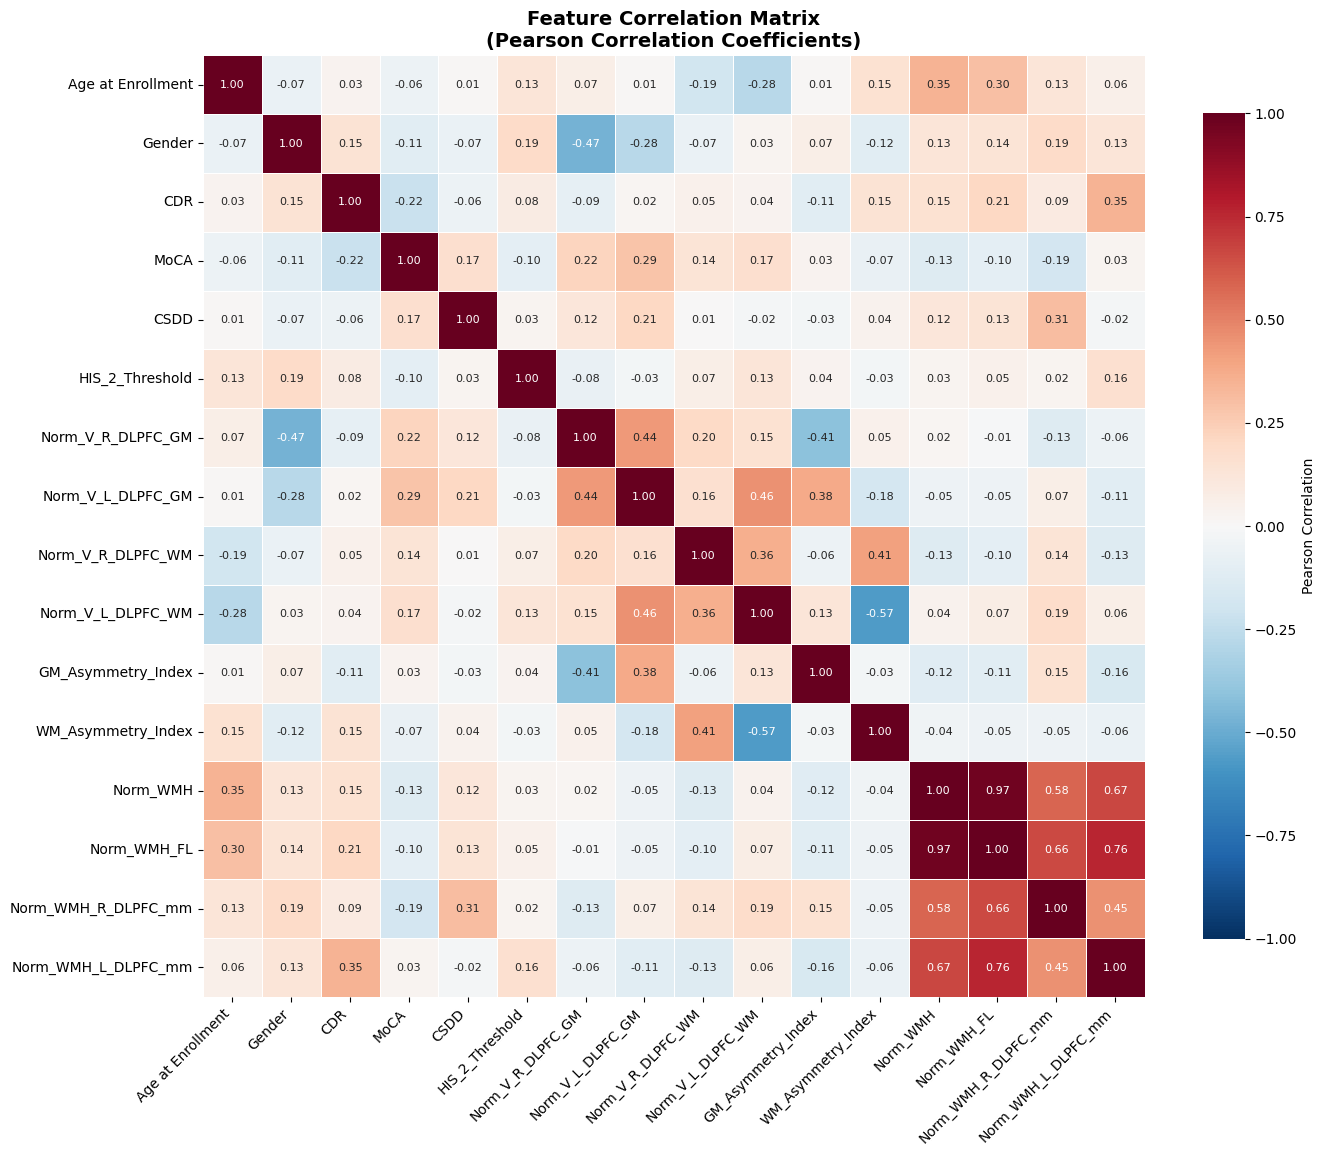

✓ Correlation heatmap saved: correlation_matrix.png

----------------------------------------------------------------------

📊 HIGHLY CORRELATED PAIRS (|r| > 0.8):

Feature_1   Feature_2  Correlation  Abs_Correlation
 Norm_WMH Norm_WMH_FL     0.974327         0.974327

----------------------------------------------------------------------

🔧 REDUNDANCY RESOLUTION (keeping higher ANOVA F-score feature):

                    Pair Correlation     Keep Keep_F      Remove Remove_F
Norm_WMH <-> Norm_WMH_FL       0.974 Norm_WMH  0.279 Norm_WMH_FL    0.054

----------------------------------------------------------------------

📋 REDUNDANCY REMOVAL SUMMARY:

   Total features: 16
   Features flagged for removal: 1
   Features to keep: 15

⚠ FEATURES TO CONSIDER REMOVING (redundant):
   - Norm_WMH_FL (ANOVA F=0.054)

✓ FEATURES TO KEEP (non-redundant):
   - Age at Enrollment (ANOVA F=0.838)
   - Gender (ANOVA F=0.158)
   - CDR (ANOVA F=0.390)
   - MoCA (ANOVA F=0.000)
   - CSDD (ANOVA F=0.069)


In [ ]:
# ============================================================
# CORRELATION-BASED REDUNDANCY REMOVAL
# ============================================================
import seaborn as sns

# Configuration
CORRELATION_THRESHOLD_HIGH = 0.8   # Flag for redundancy
CORRELATION_THRESHOLD_VERY_HIGH = 0.9  # Strong candidate for removal

# Prepare data
X_corr = df_analysis_binary_1_a.drop(columns=['w5_change_binary_one_threshold'])
feature_names_corr = X_corr.columns.tolist()

# Compute correlation matrix
corr_matrix = X_corr.corr(method='pearson')

print("=" * 70)
print("CORRELATION-BASED REDUNDANCY ANALYSIS")
print("=" * 70)

# ============================================================
# 1. Correlation Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(14, 12))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Heatmap
sns.heatmap(corr_matrix, mask=None, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'},
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Feature Correlation Matrix\n(Pearson Correlation Coefficients)',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Correlation heatmap saved: correlation_matrix.png")

# ============================================================
# 2. Identify Highly Correlated Pairs
# ============================================================
print("\n" + "-" * 70)
print(f"\n📊 HIGHLY CORRELATED PAIRS (|r| > {CORRELATION_THRESHOLD_HIGH}):\n")

# Extract pairs from upper triangle
high_corr_pairs = []
very_high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > CORRELATION_THRESHOLD_HIGH:
            feat1 = corr_matrix.columns[i]
            feat2 = corr_matrix.columns[j]
            high_corr_pairs.append({
                'Feature_1': feat1,
                'Feature_2': feat2,
                'Correlation': corr_val,
                'Abs_Correlation': abs(corr_val)
            })
            if abs(corr_val) > CORRELATION_THRESHOLD_VERY_HIGH:
                very_high_corr_pairs.append((feat1, feat2, corr_val))

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Abs_Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("   No pairs with |correlation| > 0.8 found.")
    high_corr_df = pd.DataFrame()

# ============================================================
# 3. Redundancy Resolution (using ANOVA F-scores)
# ============================================================
print("\n" + "-" * 70)
print("\n🔧 REDUNDANCY RESOLUTION (keeping higher ANOVA F-score feature):\n")

# Get ANOVA F-scores from previous analysis
anova_f_scores = anova_results.set_index('Feature')['F_Score'].to_dict()

features_to_remove = set()
resolution_log = []

for pair in high_corr_pairs:
    feat1, feat2 = pair['Feature_1'], pair['Feature_2']
    corr_val = pair['Correlation']

    f1 = anova_f_scores.get(feat1, 0)
    f2 = anova_f_scores.get(feat2, 0)

    if f1 >= f2:
        keep, remove = feat1, feat2
        keep_f, remove_f = f1, f2
    else:
        keep, remove = feat2, feat1
        keep_f, remove_f = f2, f1

    features_to_remove.add(remove)
    resolution_log.append({
        'Pair': f"{feat1} <-> {feat2}",
        'Correlation': f"{corr_val:.3f}",
        'Keep': keep,
        'Keep_F': f"{keep_f:.3f}",
        'Remove': remove,
        'Remove_F': f"{remove_f:.3f}"
    })

if resolution_log:
    resolution_df = pd.DataFrame(resolution_log)
    print(resolution_df.to_string(index=False))
else:
    resolution_df = pd.DataFrame()
    print("   No redundant features to resolve.")

# ============================================================
# 4. Summary
# ============================================================
print("\n" + "-" * 70)
print("\n📋 REDUNDANCY REMOVAL SUMMARY:\n")

features_to_keep = [f for f in feature_names_corr if f not in features_to_remove]

print(f"   Total features: {len(feature_names_corr)}")
print(f"   Features flagged for removal: {len(features_to_remove)}")
print(f"   Features to keep: {len(features_to_keep)}")

if features_to_remove:
    print(f"\n⚠ FEATURES TO CONSIDER REMOVING (redundant):")
    for feat in sorted(features_to_remove):
        f_score = anova_f_scores.get(feat, 0)
        print(f"   - {feat} (ANOVA F={f_score:.3f})")

print(f"\n✓ FEATURES TO KEEP (non-redundant):")
for feat in features_to_keep:
    f_score = anova_f_scores.get(feat, 0)
    print(f"   - {feat} (ANOVA F={f_score:.3f})")

# Store results
CORRELATION_FEATURES_TO_REMOVE = list(features_to_remove)
CORRELATION_FEATURES_TO_KEEP = features_to_keep

print(f"\n✓ Results stored in: CORRELATION_FEATURES_TO_REMOVE, CORRELATION_FEATURES_TO_KEEP")
print("=" * 70)


INTEGRATED FEATURE SELECTION SUMMARY

Combining insights from: ANOVA, ANCOVA, PCA, and Correlation Analysis

----------------------------------------------------------------------

📊 MASTER FEATURE RANKING TABLE:

            Feature  ANOVA_F  ANOVA_Sig  ANCOVA_F  ANCOVA_Sig  PCA_Rank  Redundant  Composite_Score
 GM_Asymmetry_Index 5.177123       True  5.049079        True        14      False            80.00
    HIS_2_Threshold 1.786322      False  1.727632       False         6      False            48.12
  Norm_V_R_DLPFC_GM 1.402085      False  1.160726       False         4      False            46.25
  Norm_V_R_DLPFC_WM 0.884301      False  1.227512       False         3      False            44.37
  Age at Enrollment 0.838260      False       NaN       False        16      False            42.50
  Norm_V_L_DLPFC_WM 0.529509      False  1.032738       False         9      False            40.62
                CDR 0.389988      False  0.417631       False         8      False    

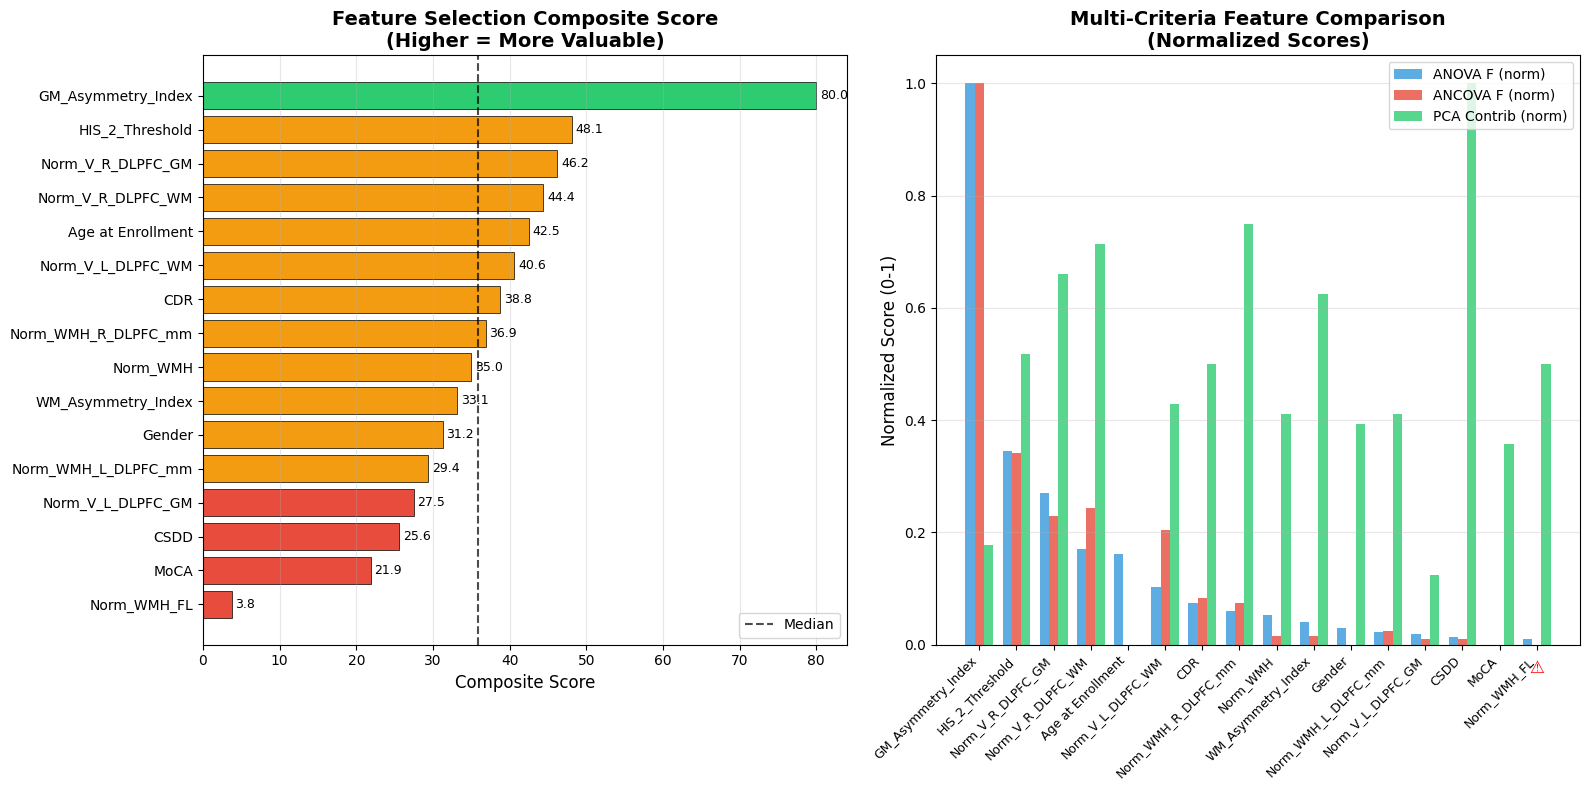


✓ Plot saved: feature_selection_summary.png

FINAL FEATURE SELECTION RECOMMENDATIONS

📌 RECOMMENDED FEATURE SET (Tier 1 + Tier 2):
   ['GM_Asymmetry_Index', 'HIS_2_Threshold', 'Norm_V_R_DLPFC_GM', 'Norm_V_R_DLPFC_WM', 'Age at Enrollment', 'Norm_V_L_DLPFC_WM', 'CDR', 'Norm_WMH_R_DLPFC_mm', 'Norm_WMH', 'WM_Asymmetry_Index', 'Gender', 'Norm_WMH_L_DLPFC_mm']
   Total: 12 features

📌 MINIMAL FEATURE SET (Tier 1 only - for simpler models):
   ['GM_Asymmetry_Index']
   Total: 1 features

📌 FEATURES TO AVOID (redundant or low value):
   ['Norm_WMH_FL', 'Norm_V_L_DLPFC_GM', 'CSDD', 'MoCA']

✓ Stored: RECOMMENDED_FEATURES (12), MINIMAL_FEATURES (1)


In [ ]:
# ============================================================
# COMBINED FEATURE SELECTION SUMMARY
# ============================================================
# Integrate all feature selection methods to make informed decisions

print("=" * 70)
print("INTEGRATED FEATURE SELECTION SUMMARY")
print("=" * 70)
print("\nCombining insights from: ANOVA, ANCOVA, PCA, and Correlation Analysis")

# ============================================================
# 1. Create Master Feature Table
# ============================================================

# Start with ANOVA results
master_df = anova_results[['Feature', 'F_Score', 'P_Value']].copy()
master_df = master_df.rename(columns={
    'F_Score': 'ANOVA_F',
    'P_Value': 'ANOVA_P'
})

# Add ANOVA significance
master_df['ANOVA_Sig'] = master_df['ANOVA_P'] < 0.05

# Add ANCOVA (Standard) results
ancova_std_summary = ancova_standard_df[['Feature', 'F_Score_ANCOVA', 'P_Value_ANCOVA']].copy()
ancova_std_summary = ancova_std_summary.rename(columns={
    'F_Score_ANCOVA': 'ANCOVA_F',
    'P_Value_ANCOVA': 'ANCOVA_P'
})
master_df = master_df.merge(ancova_std_summary, on='Feature', how='left')
master_df['ANCOVA_Sig'] = master_df['ANCOVA_P'] < 0.05

# Add PCA ranking
master_df['PCA_Rank'] = master_df['Feature'].map(PCA_FEATURE_RANKING)
master_df['PCA_Contribution'] = master_df['Feature'].map(
    pca_ranking_df.set_index('Feature')['Variance_Contribution_Pct'].to_dict()
)

# Add correlation redundancy flag
master_df['Redundant'] = master_df['Feature'].isin(CORRELATION_FEATURES_TO_REMOVE)

# Add interpretation category (from ANCOVA comparison)
interpretation_map = comparison_df.set_index('Feature')['Interpretation'].to_dict()
master_df['ANOVA_ANCOVA_Status'] = master_df['Feature'].map(interpretation_map)

# ============================================================
# 2. Create Composite Score
# ============================================================
# Higher is better for feature selection

def compute_feature_score(row):
    """Compute a composite feature importance score."""
    score = 0

    # ANOVA contribution (0-30 points based on F-score rank)
    anova_rank = master_df['ANOVA_F'].rank(ascending=False)
    anova_percentile = 1 - (anova_rank[row.name] - 1) / len(master_df)
    score += anova_percentile * 30

    # ANOVA significance bonus (+15 points)
    if row['ANOVA_Sig']:
        score += 15

    # ANCOVA significance bonus (+15 points) - robust to confounders
    if row['ANCOVA_Sig'] == True:  # Explicit True check for NaN handling
        score += 15

    # PCA contribution (0-20 points based on variance contribution)
    if pd.notna(row['PCA_Contribution']):
        pca_norm = row['PCA_Contribution'] / master_df['PCA_Contribution'].max()
        score += pca_norm * 20

    # Redundancy penalty (-20 points if redundant)
    if row['Redundant']:
        score -= 20

    return round(score, 2)

master_df['Composite_Score'] = master_df.apply(compute_feature_score, axis=1)

# Sort by composite score
master_df = master_df.sort_values('Composite_Score', ascending=False)

# ============================================================
# 3. Display Master Table
# ============================================================
print("\n" + "-" * 70)
print("\n📊 MASTER FEATURE RANKING TABLE:\n")

display_cols = ['Feature', 'ANOVA_F', 'ANOVA_Sig', 'ANCOVA_F', 'ANCOVA_Sig',
                'PCA_Rank', 'Redundant', 'Composite_Score']
print(master_df[display_cols].to_string(index=False))

# ============================================================
# 4. Feature Categories
# ============================================================
print("\n" + "-" * 70)
print("\n📋 FEATURE CATEGORIZATION:\n")

# Tier 1: High value (significant, not redundant, high composite score)
tier1 = master_df[
    (master_df['ANOVA_Sig'] | (master_df['ANCOVA_Sig'] == True)) &
    (~master_df['Redundant']) &
    (master_df['Composite_Score'] > master_df['Composite_Score'].median())
]['Feature'].tolist()

# Tier 2: Medium value (some positive signals, not redundant)
tier2 = master_df[
    (~master_df['Redundant']) &
    (~master_df['Feature'].isin(tier1)) &
    (master_df['Composite_Score'] > master_df['Composite_Score'].quantile(0.25))
]['Feature'].tolist()

# Tier 3: Low value (redundant or low scores)
tier3 = master_df[
    ~master_df['Feature'].isin(tier1 + tier2)
]['Feature'].tolist()

print(f"🟢 TIER 1 - HIGH VALUE (prioritize in models):")
print(f"   {tier1 if tier1 else 'None'}")

print(f"\n🟡 TIER 2 - MEDIUM VALUE (include if complexity allows):")
print(f"   {tier2 if tier2 else 'None'}")

print(f"\n🔴 TIER 3 - LOW VALUE (consider removing):")
print(f"   {tier3 if tier3 else 'None'}")

# ============================================================
# 5. Visualization: Feature Selection Summary
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Composite Score Bar Chart
ax1 = axes[0]
plot_data = master_df.sort_values('Composite_Score', ascending=True)

# Color by tier
tier_colors = []
for feat in plot_data['Feature']:
    if feat in tier1:
        tier_colors.append('#2ecc71')  # Green
    elif feat in tier2:
        tier_colors.append('#f39c12')  # Orange
    else:
        tier_colors.append('#e74c3c')  # Red

ax1.barh(plot_data['Feature'], plot_data['Composite_Score'], color=tier_colors, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Composite Score', fontsize=12)
ax1.set_title('Feature Selection Composite Score\n(Higher = More Valuable)', fontsize=14, fontweight='bold')
ax1.axvline(x=master_df['Composite_Score'].median(), color='black', linestyle='--', alpha=0.7, label='Median')
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.3)

# Add score labels
for i, (feat, score) in enumerate(zip(plot_data['Feature'], plot_data['Composite_Score'])):
    ax1.text(score + 0.5, i, f'{score:.1f}', va='center', fontsize=9)

# Right: Multi-criteria comparison
ax2 = axes[1]

# Prepare radar/parallel coordinates data
metrics = ['ANOVA_F', 'ANCOVA_F', 'PCA_Contribution']
normalized_data = master_df[metrics].copy()
for col in metrics:
    normalized_data[col] = (normalized_data[col] - normalized_data[col].min()) / (normalized_data[col].max() - normalized_data[col].min())

# Stacked bar chart showing normalized metrics
x_pos = np.arange(len(master_df))
width = 0.25

bars1 = ax2.bar(x_pos - width, normalized_data['ANOVA_F'], width, label='ANOVA F (norm)', color='#3498db', alpha=0.8)
bars2 = ax2.bar(x_pos, normalized_data['ANCOVA_F'].fillna(0), width, label='ANCOVA F (norm)', color='#e74c3c', alpha=0.8)
bars3 = ax2.bar(x_pos + width, normalized_data['PCA_Contribution'].fillna(0), width, label='PCA Contrib (norm)', color='#2ecc71', alpha=0.8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(master_df['Feature'], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Normalized Score (0-1)', fontsize=12)
ax2.set_title('Multi-Criteria Feature Comparison\n(Normalized Scores)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Mark redundant features
for i, (feat, redundant) in enumerate(zip(master_df['Feature'], master_df['Redundant'])):
    if redundant:
        ax2.text(i, -0.05, '⚠', ha='center', fontsize=12, color='red')

plt.tight_layout()
plt.savefig('feature_selection_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved: feature_selection_summary.png")

# ============================================================
# 6. Final Recommendations
# ============================================================
print("\n" + "=" * 70)
print("FINAL FEATURE SELECTION RECOMMENDATIONS")
print("=" * 70)

print("\n📌 RECOMMENDED FEATURE SET (Tier 1 + Tier 2):")
recommended_features = tier1 + tier2
print(f"   {recommended_features}")
print(f"   Total: {len(recommended_features)} features")

print("\n📌 MINIMAL FEATURE SET (Tier 1 only - for simpler models):")
print(f"   {tier1}")
print(f"   Total: {len(tier1)} features")

print("\n📌 FEATURES TO AVOID (redundant or low value):")
avoid_features = CORRELATION_FEATURES_TO_REMOVE + [f for f in tier3 if f not in CORRELATION_FEATURES_TO_REMOVE]
print(f"   {list(set(avoid_features))}")

# Store for downstream use
RECOMMENDED_FEATURES = recommended_features
MINIMAL_FEATURES = tier1 if tier1 else recommended_features[:5]  # Fallback to top 5

print(f"\n✓ Stored: RECOMMENDED_FEATURES ({len(RECOMMENDED_FEATURES)}), MINIMAL_FEATURES ({len(MINIMAL_FEATURES)})")
print("=" * 70)


---

## 5.2 Sequential Forward Selection (SFS) with SVM

Sequential Forward Selection is a **greedy wrapper method** that iteratively adds features based on model performance:

1. Start with empty feature set
2. Add the feature that most improves the scoring metric
3. Repeat until desired number of features is reached

**Why SVM?** SVM is sensitive to irrelevant features, making it effective at identifying useful feature combinations.

**Output:**
- Optimal feature subset that works well together
- Performance curve showing score vs. number of features
- Feature selection order (importance ranking)


In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import matplotlib.pyplot as plt
import warnings
import io
import sys
from datetime import datetime

# ============================================================
# CONFIGURATION - Sequential Forward Selection
# ============================================================
# Scoring metric for feature selection
# Options: "average_precision", "f1", "recall", "roc_auc"
# - "average_precision": Overall ranking ability (threshold-independent)
# - "f1": Balance precision & recall at threshold=0.5
# - "recall": Maximize catching positives (may sacrifice precision)

SFS_SCORING = "average_precision"  # <-- CHANGE THIS to "f1" if desired

# Cross-validation settings (match your ML pipeline)
SFS_CV_FOLDS = 3  # StratifiedKFold splits

# Feature range to explore
SFS_MIN_FEATURES = 1
SFS_MAX_FEATURES = 10  # Explore up to 10 features (you have 16 total)

# ============================================================
# MULTIPLE RANDOM SEEDS FOR ROBUSTNESS
# ============================================================
RANDOM_SEEDS = [42, 123, 456, 789, 2024, 101, 202, 303, 404, 505]  # <-- Add/remove seeds as needed

# ============================================================
# OUTPUT DIRECTORY SETUP
# ============================================================
SFS_OUTPUT_DIR = "SFS"
os.makedirs(SFS_OUTPUT_DIR, exist_ok=True)
print(f"✓ Output directory created: {SFS_OUTPUT_DIR}/")

# Timestamp for this run
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# ============================================================
# Helper function to capture and save output
# ============================================================
class OutputCapture:
    """Capture print output and save to file while also printing to console."""
    def __init__(self, filename):
        self.filename = filename
        self.buffer = io.StringIO()
        self.console = sys.stdout

    def write(self, text):
        self.buffer.write(text)
        self.console.write(text)

    def flush(self):
        self.console.flush()

    def save(self):
        with open(self.filename, 'w', encoding='utf-8') as f:
            f.write(self.buffer.getvalue())
        print(f"\n✓ Output saved to: {self.filename}")

    def get_content(self):
        return self.buffer.getvalue()

# ============================================================
# GPU Support (cuML for CUDA-accelerated SVM)
# ============================================================
# Set to True to attempt GPU acceleration (requires Linux + cuML installed)
# cuML (RAPIDS) does NOT support Windows - set to False on Windows
# XGBoost in your ML pipeline DOES use GPU (device="cuda")

USE_GPU = False  # <-- Set to True on Linux with cuML installed

if USE_GPU:
    try:
        from cuml.svm import SVC as cuSVC
        from cuml import using_output_type
        import cupy as cp
        # Test if CUDA is available
        cp.cuda.runtime.getDeviceCount()
        print("✓ GPU detected! Using cuML for CUDA-accelerated SVM")
    except (ImportError, Exception) as e:
        print(f"⚠ GPU requested but not available ({type(e).__name__})")
        print("  Falling back to CPU. To enable GPU on Linux:")
        print("  pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com")
        USE_GPU = False
else:
    print("ℹ Using CPU-based scikit-learn SVM (USE_GPU=False)")

# ============================================================
# Prepare data for SFS
# ============================================================
X_sfs = df_analysis_binary_1_a.drop(columns=['w5_change_binary_one_threshold'])
y_sfs = df_analysis_binary_1_a['w5_change_binary_one_threshold']

feature_names = X_sfs.columns.tolist()
n_features = len(feature_names)

print(f"\nData shape: {X_sfs.shape}")
print(f"Features: {feature_names}")
print(f"Target distribution: {dict(y_sfs.value_counts())}")

print(f"\nSFS Configuration:")
print(f"  - Scoring: {SFS_SCORING}")
print(f"  - CV: {SFS_CV_FOLDS}-fold StratifiedKFold")
print(f"  - Feature range: {SFS_MIN_FEATURES} to {SFS_MAX_FEATURES}")
print(f"  - Random seeds: {RANDOM_SEEDS}")
print(f"  - Device: {'GPU (cuML)' if USE_GPU else 'CPU (scikit-learn)'}")
print(f"  - Output directory: {SFS_OUTPUT_DIR}/")


✓ Output directory created: SFS/
ℹ Using CPU-based scikit-learn SVM (USE_GPU=False)

Data shape: (58, 16)
Features: ['Age at Enrollment', 'Gender', 'CDR', 'MoCA', 'CSDD', 'HIS_2_Threshold', 'Norm_V_R_DLPFC_GM', 'Norm_V_L_DLPFC_GM', 'Norm_V_R_DLPFC_WM', 'Norm_V_L_DLPFC_WM', 'GM_Asymmetry_Index', 'WM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_FL', 'Norm_WMH_R_DLPFC_mm', 'Norm_WMH_L_DLPFC_mm']
Target distribution: {0: np.int64(46), 1: np.int64(12)}

SFS Configuration:
  - Scoring: average_precision
  - CV: 3-fold StratifiedKFold
  - Feature range: 1 to 10
  - Random seeds: [42, 123, 456, 789, 2024, 101, 202, 303, 404, 505]
  - Device: CPU (scikit-learn)
  - Output directory: SFS/


In [ ]:
# ============================================================
# SVM HYPERPARAMETER TUNING (using first seed for initial tuning)
# ============================================================
# Find the best SVM configuration before running SFS
# This ensures we use an optimized SVM for feature selection

# Start capturing output
svm_tuning_output = OutputCapture(os.path.join(SFS_OUTPUT_DIR, f"01_svm_tuning_{RUN_TIMESTAMP}.txt"))
sys.stdout = svm_tuning_output

print("=" * 70)
print("SVM HYPERPARAMETER TUNING")
print(f"Timestamp: {RUN_TIMESTAMP}")
print("=" * 70)

# Use first seed for initial tuning
TUNING_SEED = RANDOM_SEEDS[0]
cv_strategy_tuning = StratifiedKFold(n_splits=SFS_CV_FOLDS, shuffle=True, random_state=TUNING_SEED)

# ============================================================
# SVM Parameter Grid
# ============================================================
# kernel:
#   - 'linear': Fast, interpretable, good for small data
#   - 'rbf': Captures non-linear patterns, needs gamma tuning
#
# C (Regularization):
#   - Small C: More regularization, simpler model, may underfit
#   - Large C: Less regularization, complex model, may overfit
#
# gamma (RBF only):
#   - 'scale': 1 / (n_features * X.var()) - default, adapts to data
#   - 'auto': 1 / n_features
#   - Small gamma: Smoother decision boundary
#   - Large gamma: More complex boundary, may overfit
#
# class_weight:
#   - 'balanced': Automatically adjust for imbalanced classes
#   - None: No adjustment (not recommended for imbalanced data)

SVM_PARAM_GRID = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],  # Only used for RBF
    'svm__class_weight': ['balanced'],  # Keep balanced for imbalanced data
}

# SVM base estimator with extended parameters
svm_base = SVC(
    probability=True,      # Enable probability estimates
    random_state=TUNING_SEED,  # Reproducibility
    max_iter=10000,        # Max optimization iterations (increase if not converging)
    tol=1e-4,              # Convergence tolerance
    cache_size=500,        # Memory cache in MB (speeds up training)
    shrinking=True,        # Use shrinking heuristic (faster)
)

# Pipeline for tuning
tuning_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm_base)
])

print(f"\nUsing seed {TUNING_SEED} for SVM hyperparameter tuning")
print(f"Parameter grid: {SVM_PARAM_GRID}")
print(f"Total combinations to try: ~{len(SVM_PARAM_GRID['svm__kernel']) * len(SVM_PARAM_GRID['svm__C']) * len(SVM_PARAM_GRID['svm__gamma'])}")
print("(Note: gamma is ignored for linear kernel)\n")

# Grid Search with Cross-Validation
svm_grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=SVM_PARAM_GRID,
    scoring=SFS_SCORING,
    cv=cv_strategy_tuning,
    n_jobs=-1,           # Use all CPU cores
    verbose=1,           # Show progress
    refit=True,          # Refit best model on full data
    return_train_score=True  # For analysis
)

# Fit grid search
svm_grid_search.fit(X_sfs, y_sfs)

print("\n" + "=" * 70)

# Restore stdout and save
sys.stdout = svm_tuning_output.console
svm_tuning_output.save()


SVM HYPERPARAMETER TUNING
Timestamp: 20260106_234113

Using seed 42 for SVM hyperparameter tuning
Parameter grid: {'svm__kernel': ['linear', 'rbf'], 'svm__C': [0.01, 0.1, 1, 10, 100], 'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1], 'svm__class_weight': ['balanced']}
Total combinations to try: ~50
(Note: gamma is ignored for linear kernel)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


✓ Output saved to: SFS\01_svm_tuning_20260106_234113.txt


In [ ]:
# ============================================================
# SVM Tuning Results
# ============================================================

# Continue capturing to same file (append mode simulation)
svm_results_output = OutputCapture(os.path.join(SFS_OUTPUT_DIR, f"02_svm_results_{RUN_TIMESTAMP}.txt"))
sys.stdout = svm_results_output

print("SVM HYPERPARAMETER TUNING RESULTS")
print("=" * 70)

# Best parameters
print(f"\n🏆 BEST SVM CONFIGURATION:")
print(f"   Best Score ({SFS_SCORING}): {svm_grid_search.best_score_:.4f}")
print(f"   Best Parameters:")
for param, value in svm_grid_search.best_params_.items():
    print(f"      - {param}: {value}")

# Extract best settings
best_kernel = svm_grid_search.best_params_['svm__kernel']
best_C = svm_grid_search.best_params_['svm__C']
best_gamma = svm_grid_search.best_params_.get('svm__gamma', 'scale')

# Show top 5 configurations
print(f"\n📊 TOP 5 CONFIGURATIONS:")
cv_results = pd.DataFrame(svm_grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('rank_test_score').head(5)

for idx, row in cv_results_sorted.iterrows():
    params = row['params']
    mean_score = row['mean_test_score']
    std_score = row['std_test_score']
    print(f"   Rank {int(row['rank_test_score'])}: Score={mean_score:.4f}±{std_score:.4f}")
    print(f"           kernel={params['svm__kernel']}, C={params['svm__C']}, gamma={params.get('svm__gamma', 'N/A')}")

# Kernel comparison
print(f"\n📈 KERNEL COMPARISON (average across all C and gamma):")
linear_scores = cv_results[cv_results['param_svm__kernel'] == 'linear']['mean_test_score']
rbf_scores = cv_results[cv_results['param_svm__kernel'] == 'rbf']['mean_test_score']
print(f"   Linear kernel: {linear_scores.mean():.4f} ± {linear_scores.std():.4f}")
print(f"   RBF kernel:    {rbf_scores.mean():.4f} ± {rbf_scores.std():.4f}")

if linear_scores.mean() > rbf_scores.mean():
    print(f"   → Linear kernel performs better on average (good for small datasets)")
else:
    print(f"   → RBF kernel performs better (data may have non-linear patterns)")

print("\n" + "=" * 70)

# Restore stdout and save
sys.stdout = svm_results_output.console
svm_results_output.save()

# Save CV results to CSV
cv_results_path = os.path.join(SFS_OUTPUT_DIR, f"svm_cv_results_{RUN_TIMESTAMP}.csv")
cv_results.to_csv(cv_results_path, index=False)
print(f"✓ CV results saved to: {cv_results_path}")


SVM HYPERPARAMETER TUNING RESULTS

🏆 BEST SVM CONFIGURATION:
   Best Score (average_precision): 0.6254
   Best Parameters:
      - svm__C: 0.01
      - svm__class_weight: balanced
      - svm__gamma: 1
      - svm__kernel: rbf

📊 TOP 5 CONFIGURATIONS:
   Rank 1: Score=0.6254±0.0372
           kernel=rbf, C=0.01, gamma=1
   Rank 1: Score=0.6254±0.0372
           kernel=rbf, C=0.1, gamma=1
   Rank 1: Score=0.6254±0.0372
           kernel=rbf, C=1, gamma=1
   Rank 1: Score=0.6254±0.0372
           kernel=rbf, C=10, gamma=1
   Rank 1: Score=0.6254±0.0372
           kernel=rbf, C=100, gamma=1

📈 KERNEL COMPARISON (average across all C and gamma):
   Linear kernel: 0.2725 ± 0.0197
   RBF kernel:    0.4570 ± 0.1143
   → RBF kernel performs better (data may have non-linear patterns)


✓ Output saved to: SFS\02_svm_results_20260106_234113.txt
✓ CV results saved to: SFS\svm_cv_results_20260106_234113.csv


In [ ]:
# ============================================================
# Create Optimized SVM Pipeline Factory for SFS
# ============================================================
# Use the best hyperparameters found above
# Create a function to generate pipelines with different random seeds

print("Creating optimized SVM pipeline factory for Sequential Feature Selection...")

def create_sfs_pipeline(random_seed):
    """Create an SVM pipeline with the best hyperparameters and specified random seed."""
    if USE_GPU:
        # cuML SVM (GPU) - Linux only
        svm_optimized = cuSVC(
            kernel=best_kernel,
            C=best_C,
            gamma=best_gamma if best_kernel == 'rbf' else 'scale',
            class_weight='balanced',
            probability=True
        )
    else:
        # scikit-learn SVM (CPU) with all tuned parameters
        svm_optimized = SVC(
            kernel=best_kernel,
            C=best_C,
            gamma=best_gamma if best_kernel == 'rbf' else 'scale',
            class_weight='balanced',
            probability=True,
            random_state=random_seed,
            max_iter=10000,
            tol=1e-4,
            cache_size=500,
            shrinking=True
        )

    return Pipeline([
        ('scaler', StandardScaler()),
        ('svm', svm_optimized)
    ])

print(f"\n✓ Optimized SVM Pipeline Factory created:")
print(f"   - Kernel: {best_kernel}")
print(f"   - C: {best_C}")
print(f"   - Gamma: {best_gamma if best_kernel == 'rbf' else 'N/A (linear kernel)'}")
print(f"   - Class weight: balanced")
print(f"   - Max iterations: 10000")
print(f"   - Tolerance: 1e-4")
print(f"\n✓ Will run SFS with {len(RANDOM_SEEDS)} random seeds: {RANDOM_SEEDS}")
print(f"\nReady for Sequential Feature Selection!")


Creating optimized SVM pipeline factory for Sequential Feature Selection...

✓ Optimized SVM Pipeline Factory created:
   - Kernel: rbf
   - C: 0.01
   - Gamma: 1
   - Class weight: balanced
   - Max iterations: 10000
   - Tolerance: 1e-4

✓ Will run SFS with 10 random seeds: [42, 123, 456, 789, 2024, 101, 202, 303, 404, 505]

Ready for Sequential Feature Selection!


In [ ]:
# ============================================================
# Run Sequential Forward Selection with MULTIPLE RANDOM SEEDS
# ============================================================
# This runs SFS for each seed and stores all results

from sklearn.model_selection import cross_val_score

# Store results for all seeds
all_seeds_results = {}  # {seed: [list of results per k]}
all_seeds_best_features = {}  # {seed: best_features_list}

print("=" * 70)
print(f"SEQUENTIAL FORWARD SELECTION - MULTI-SEED ANALYSIS")
print(f"Scoring: {SFS_SCORING} | Seeds: {RANDOM_SEEDS}")
print("=" * 70)

for seed_idx, seed in enumerate(RANDOM_SEEDS):
    # Create output capture for this seed
    seed_output = OutputCapture(os.path.join(SFS_OUTPUT_DIR, f"03_sfs_seed_{seed}_{RUN_TIMESTAMP}.txt"))
    sys.stdout = seed_output

    print("=" * 70)
    print(f"SFS RUN {seed_idx + 1}/{len(RANDOM_SEEDS)} - SEED: {seed}")
    print("=" * 70)
    print(f"Running SFS for k = {SFS_MIN_FEATURES} to {SFS_MAX_FEATURES} features...\n")

    # Create pipeline and CV strategy for this seed
    sfs_pipeline = create_sfs_pipeline(seed)
    cv_strategy = StratifiedKFold(n_splits=SFS_CV_FOLDS, shuffle=True, random_state=seed)

    seed_results = []

    for k in range(SFS_MIN_FEATURES, min(SFS_MAX_FEATURES + 1, n_features + 1)):
        print(f"  k={k}: ", end="", flush=True)

        # Create SFS selector for k features
        sfs = SequentialFeatureSelector(
            sfs_pipeline,
            n_features_to_select=k,
            direction='forward',
            scoring=SFS_SCORING,
            cv=cv_strategy,
            n_jobs=-1  # Use all CPU cores
        )

        # Fit SFS
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sfs.fit(X_sfs, y_sfs)

        # Get selected features
        selected_mask = sfs.get_support()
        selected_features = [f for f, s in zip(feature_names, selected_mask) if s]

        # Calculate CV score with selected features
        X_selected = X_sfs[selected_features]
        cv_scores = cross_val_score(sfs_pipeline, X_selected, y_sfs,
                                     cv=cv_strategy, scoring=SFS_SCORING)
        mean_score = cv_scores.mean()
        std_score = cv_scores.std()

        seed_results.append({
            'seed': seed,
            'k': k,
            'features': selected_features,
            'mean_score': mean_score,
            'std_score': std_score
        })

        print(f"Score = {mean_score:.4f} ± {std_score:.4f} | Features: {selected_features}")

    # Find best k for this seed
    best_result = max(seed_results, key=lambda x: x['mean_score'])
    print(f"\n🏆 Best for seed {seed}: k={best_result['k']}, Score={best_result['mean_score']:.4f}")
    print(f"   Features: {best_result['features']}")
    print("=" * 70)

    # Store results
    all_seeds_results[seed] = seed_results
    all_seeds_best_features[seed] = best_result['features']

    # Restore stdout and save
    sys.stdout = seed_output.console
    seed_output.save()

    # Print progress to console
    print(f"✓ Completed seed {seed} ({seed_idx + 1}/{len(RANDOM_SEEDS)})")

print(f"\n✓ All {len(RANDOM_SEEDS)} seeds completed!")
print(f"✓ Results saved to {SFS_OUTPUT_DIR}/")


SEQUENTIAL FORWARD SELECTION - MULTI-SEED ANALYSIS
Scoring: average_precision | Seeds: [42, 123, 456, 789, 2024, 101, 202, 303, 404, 505]
SFS RUN 1/10 - SEED: 42
Running SFS for k = 1 to 10 features...

  k=1: Score = 0.5811 ± 0.1123 | Features: ['Norm_WMH']
  k=2: Score = 0.5965 ± 0.0643 | Features: ['GM_Asymmetry_Index', 'Norm_WMH']
  k=3: Score = 0.6134 ± 0.0879 | Features: ['GM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_L_DLPFC_mm']
  k=4: Score = 0.6277 ± 0.1508 | Features: ['Norm_V_L_DLPFC_WM', 'GM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_L_DLPFC_mm']
  k=5: Score = 0.5643 ± 0.0944 | Features: ['Norm_V_L_DLPFC_WM', 'GM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_FL', 'Norm_WMH_L_DLPFC_mm']
  k=6: Score = 0.5423 ± 0.1008 | Features: ['MoCA', 'Norm_V_L_DLPFC_WM', 'GM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_FL', 'Norm_WMH_L_DLPFC_mm']
  k=7: Score = 0.5191 ± 0.0956 | Features: ['MoCA', 'Norm_V_L_DLPFC_WM', 'GM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_FL', 'Norm_WMH_R_DLPFC_mm', 'Norm_WMH_L_D

✓ All SFS results saved to: SFS\sfs_all_results_20260106_234113.csv


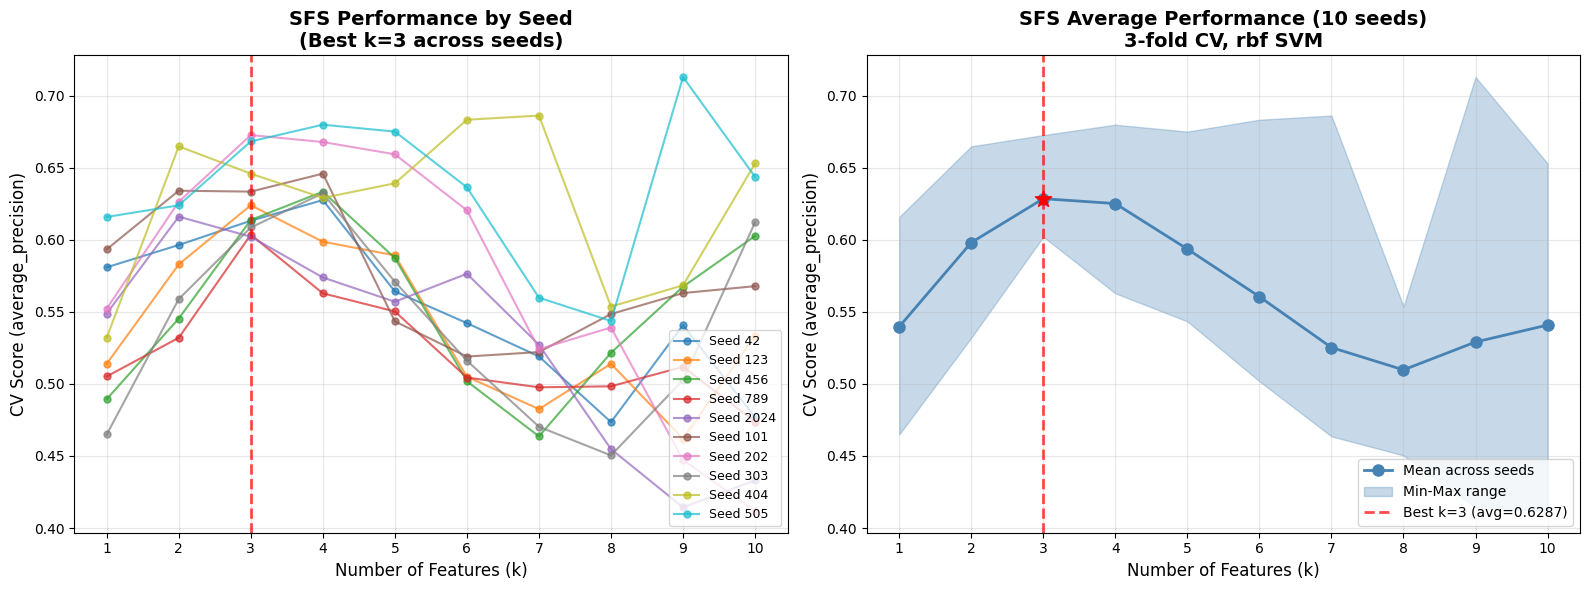


✓ Plot saved: SFS\plots_sfs_multi_seed_20260106_234113.png


In [ ]:
# ============================================================
# Visualize SFS Results - All Seeds
# ============================================================

# Create combined DataFrame from all seeds
all_results_list = []
for seed, results in all_seeds_results.items():
    all_results_list.extend(results)
sfs_df_all = pd.DataFrame(all_results_list)

# Save combined results to CSV
sfs_csv_path = os.path.join(SFS_OUTPUT_DIR, f"sfs_all_results_{RUN_TIMESTAMP}.csv")
sfs_df_all.to_csv(sfs_csv_path, index=False)
print(f"✓ All SFS results saved to: {sfs_csv_path}")

# Calculate mean and std across seeds for each k
sfs_summary = sfs_df_all.groupby('k').agg({
    'mean_score': ['mean', 'std', 'min', 'max']
}).reset_index()
sfs_summary.columns = ['k', 'avg_score', 'std_across_seeds', 'min_score', 'max_score']

# Find overall best k (highest average across seeds)
best_k_overall = sfs_summary.loc[sfs_summary['avg_score'].idxmax(), 'k']
best_score_overall = sfs_summary.loc[sfs_summary['avg_score'].idxmax(), 'avg_score']

# Plot: All seeds on one figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Individual seed curves
ax1 = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(RANDOM_SEEDS)))
for (seed, results), color in zip(all_seeds_results.items(), colors):
    seed_df = pd.DataFrame(results)
    ax1.plot(seed_df['k'], seed_df['mean_score'], marker='o', markersize=5,
             linewidth=1.5, color=color, alpha=0.7, label=f'Seed {seed}')

ax1.axvline(x=best_k_overall, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel('Number of Features (k)', fontsize=12)
ax1.set_ylabel(f'CV Score ({SFS_SCORING})', fontsize=12)
ax1.set_title(f'SFS Performance by Seed\n(Best k={int(best_k_overall)} across seeds)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(SFS_MIN_FEATURES, SFS_MAX_FEATURES + 1))

# Right plot: Average with confidence band
ax2 = axes[1]
ax2.plot(sfs_summary['k'], sfs_summary['avg_score'], marker='o', markersize=8,
         linewidth=2, color='steelblue', label='Mean across seeds')
ax2.fill_between(sfs_summary['k'],
                  sfs_summary['min_score'],
                  sfs_summary['max_score'],
                  alpha=0.3, color='steelblue', label='Min-Max range')
ax2.axvline(x=best_k_overall, color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Best k={int(best_k_overall)} (avg={best_score_overall:.4f})')
ax2.scatter([best_k_overall], [best_score_overall], color='red', s=150, zorder=5, marker='*')

ax2.set_xlabel('Number of Features (k)', fontsize=12)
ax2.set_ylabel(f'CV Score ({SFS_SCORING})', fontsize=12)
ax2.set_title(f'SFS Average Performance ({len(RANDOM_SEEDS)} seeds)\n{SFS_CV_FOLDS}-fold CV, {best_kernel} SVM',
              fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(SFS_MIN_FEATURES, SFS_MAX_FEATURES + 1))

plt.tight_layout()
plot_path = os.path.join(SFS_OUTPUT_DIR, f"plots_sfs_multi_seed_{RUN_TIMESTAMP}.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved: {plot_path}")


In [ ]:
# ============================================================
# Summary: SFS Results - Multi-Seed
# ============================================================

# Capture summary output
summary_output = OutputCapture(os.path.join(SFS_OUTPUT_DIR, f"04_sfs_summary_{RUN_TIMESTAMP}.txt"))
sys.stdout = summary_output

print("=" * 70)
print("SEQUENTIAL FORWARD SELECTION - MULTI-SEED SUMMARY")
print("=" * 70)

print(f"\n📊 Configuration:")
print(f"   - Scoring Metric: {SFS_SCORING}")
print(f"   - CV Strategy: {SFS_CV_FOLDS}-fold StratifiedKFold")
print(f"   - Random Seeds: {RANDOM_SEEDS}")
print(f"   - SVM Kernel: {best_kernel}, C={best_C}")

print(f"\n🏆 OVERALL BEST (averaged across {len(RANDOM_SEEDS)} seeds):")
print(f"   - Best k: {int(best_k_overall)} features")
print(f"   - Average CV Score: {best_score_overall:.4f}")

# Best features per seed
print(f"\n📋 BEST FEATURES PER SEED:")
for seed, features in all_seeds_best_features.items():
    best_k_seed = len(features)
    best_score_seed = max([r['mean_score'] for r in all_seeds_results[seed]])
    print(f"   Seed {seed}: k={best_k_seed}, Score={best_score_seed:.4f}")
    print(f"            Features: {features}")

# Find consensus features (appear in majority of seeds)
from collections import Counter
all_best_features_flat = []
for features in all_seeds_best_features.values():
    all_best_features_flat.extend(features)
feature_counts = Counter(all_best_features_flat)

print(f"\n🔄 FEATURE CONSENSUS (across best feature sets):")
print(f"   Features appearing in multiple seeds' best sets:")
for feat, count in feature_counts.most_common():
    pct = count / len(RANDOM_SEEDS) * 100
    print(f"   - {feat}: {count}/{len(RANDOM_SEEDS)} seeds ({pct:.0f}%)")

# Consensus features (appear in >50% of seeds)
consensus_features = [f for f, c in feature_counts.items() if c > len(RANDOM_SEEDS) / 2]
print(f"\n✓ CONSENSUS FEATURES (>50% of seeds): {consensus_features}")

# Compare with ANOVA results
print(f"\n🔍 COMPARISON WITH ANOVA:")
print(f"   ANOVA significant (p<0.05): {significant_features}")
print(f"   SFS consensus features:     {consensus_features}")

# Store for later use in ML models
SFS_SELECTED_FEATURES = consensus_features
print(f"\n✓ Consensus features stored in: SFS_SELECTED_FEATURES")
print("=" * 70)

# Restore stdout and save
sys.stdout = summary_output.console
summary_output.save()

SEQUENTIAL FORWARD SELECTION - MULTI-SEED SUMMARY

📊 Configuration:
   - Scoring Metric: average_precision
   - CV Strategy: 3-fold StratifiedKFold
   - Random Seeds: [42, 123, 456, 789, 2024, 101, 202, 303, 404, 505]
   - SVM Kernel: rbf, C=0.01

🏆 OVERALL BEST (averaged across 10 seeds):
   - Best k: 3 features
   - Average CV Score: 0.6287

📋 BEST FEATURES PER SEED:
   Seed 42: k=4, Score=0.6277
            Features: ['Norm_V_L_DLPFC_WM', 'GM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_L_DLPFC_mm']
   Seed 123: k=3, Score=0.6241
            Features: ['HIS_2_Threshold', 'GM_Asymmetry_Index', 'Norm_WMH']
   Seed 456: k=4, Score=0.6335
            Features: ['HIS_2_Threshold', 'Norm_WMH', 'Norm_WMH_R_DLPFC_mm', 'Norm_WMH_L_DLPFC_mm']
   Seed 789: k=3, Score=0.6037
            Features: ['CSDD', 'HIS_2_Threshold', 'Norm_WMH']
   Seed 2024: k=2, Score=0.6162
            Features: ['GM_Asymmetry_Index', 'Norm_WMH']
   Seed 101: k=4, Score=0.6461
            Features: ['GM_Asymmetry_Index', '

In [ ]:
# ============================================================
# RANKING COMPARISON ACROSS SEEDS
# ============================================================
# Compare feature selection order across different random seeds

# Capture ranking comparison output
ranking_output = OutputCapture(os.path.join(SFS_OUTPUT_DIR, f"05_ranking_comparison_{RUN_TIMESTAMP}.txt"))
sys.stdout = ranking_output

print("=" * 70)
print("FEATURE RANKING COMPARISON ACROSS SEEDS")
print("=" * 70)

# Extract feature selection order for each seed
def get_selection_order(seed_results):
    """Extract the order in which features were selected."""
    order = []
    prev_features = []
    for result in sorted(seed_results, key=lambda x: x['k']):
        current_features = result['features']
        new_features = [f for f in current_features if f not in prev_features]
        if new_features:
            order.append(new_features[0])
        prev_features = current_features
    return order

selection_orders = {}
for seed, results in all_seeds_results.items():
    selection_orders[seed] = get_selection_order(results)

# Print selection order for each seed
print("\n📋 FEATURE SELECTION ORDER BY SEED:")
print("-" * 70)
for seed, order in selection_orders.items():
    print(f"\nSeed {seed}:")
    for rank, feature in enumerate(order, 1):
        print(f"   {rank}. {feature}")

# Create ranking matrix
print("\n\n📊 RANKING MATRIX (position of each feature across seeds):")
print("-" * 70)

# Get all features that were ever selected
all_selected_features = set()
for order in selection_orders.values():
    all_selected_features.update(order)

# Create ranking DataFrame
ranking_data = []
for feature in feature_names:
    row = {'Feature': feature}
    ranks = []
    for seed, order in selection_orders.items():
        if feature in order:
            rank = order.index(feature) + 1
            row[f'Seed_{seed}'] = rank
            ranks.append(rank)
        else:
            row[f'Seed_{seed}'] = '-'

    # Calculate statistics
    if ranks:
        row['Avg_Rank'] = np.mean(ranks)
        row['Std_Rank'] = np.std(ranks)
        row['Times_Selected'] = len(ranks)
    else:
        row['Avg_Rank'] = float('inf')
        row['Std_Rank'] = float('nan')
        row['Times_Selected'] = 0

    ranking_data.append(row)

ranking_df = pd.DataFrame(ranking_data)
ranking_df = ranking_df.sort_values('Avg_Rank')

# Print ranking table
print("\nFeature rankings (lower = selected earlier):")
print(ranking_df.to_string(index=False))

# Stability analysis
print("\n\n🔬 RANKING STABILITY ANALYSIS:")
print("-" * 70)

# Most stable features (low std in rank)
stable_features = ranking_df[ranking_df['Times_Selected'] == len(RANDOM_SEEDS)].copy()
if not stable_features.empty:
    stable_features = stable_features.sort_values('Std_Rank')
    print("\nMost stable features (selected by ALL seeds, sorted by rank consistency):")
    for _, row in stable_features.iterrows():
        print(f"   {row['Feature']}: Avg rank = {row['Avg_Rank']:.1f} ± {row['Std_Rank']:.2f}")
else:
    print("\nNo features were selected by all seeds.")

# Features with high agreement (selected by >50% of seeds)
high_agreement = ranking_df[ranking_df['Times_Selected'] > len(RANDOM_SEEDS) / 2].copy()
high_agreement = high_agreement.sort_values('Avg_Rank')
print(f"\nFeatures with high agreement (selected by >{len(RANDOM_SEEDS)//2} seeds):")
for _, row in high_agreement.iterrows():
    print(f"   {row['Feature']}: Avg rank = {row['Avg_Rank']:.1f}, Selected {row['Times_Selected']}/{len(RANDOM_SEEDS)} times")

# Kendall's W (coefficient of concordance) for ranking agreement
print("\n\n📈 RANKING AGREEMENT STATISTICS:")
print("-" * 70)

# Calculate pairwise Spearman correlations between seed rankings
from scipy.stats import spearmanr
seed_list = list(selection_orders.keys())
correlations = []
print("\nPairwise Spearman correlations between seed rankings:")
for i, seed1 in enumerate(seed_list):
    for seed2 in seed_list[i+1:]:
        # Get common features
        order1 = selection_orders[seed1]
        order2 = selection_orders[seed2]
        common = set(order1) & set(order2)

        if len(common) >= 3:
            ranks1 = [order1.index(f) for f in common]
            ranks2 = [order2.index(f) for f in common]
            corr, pval = spearmanr(ranks1, ranks2)
            correlations.append(corr)
            print(f"   Seed {seed1} vs Seed {seed2}: ρ = {corr:.3f} (p = {pval:.3f})")

if correlations:
    print(f"\nAverage pairwise correlation: {np.mean(correlations):.3f} ± {np.std(correlations):.3f}")
    if np.mean(correlations) > 0.7:
        print("   → HIGH agreement between seeds")
    elif np.mean(correlations) > 0.4:
        print("   → MODERATE agreement between seeds")
    else:
        print("   → LOW agreement between seeds (results may be unstable)")

print("\n" + "=" * 70)

# Restore stdout and save
sys.stdout = ranking_output.console
ranking_output.save()

# Save ranking DataFrame to CSV
ranking_csv_path = os.path.join(SFS_OUTPUT_DIR, f"feature_rankings_{RUN_TIMESTAMP}.csv")
ranking_df.to_csv(ranking_csv_path, index=False)
print(f"✓ Ranking comparison saved to: {ranking_csv_path}")


FEATURE RANKING COMPARISON ACROSS SEEDS

📋 FEATURE SELECTION ORDER BY SEED:
----------------------------------------------------------------------

Seed 42:
   1. Norm_WMH
   2. GM_Asymmetry_Index
   3. Norm_WMH_L_DLPFC_mm
   4. Norm_V_L_DLPFC_WM
   5. Norm_WMH_FL
   6. MoCA
   7. Norm_WMH_R_DLPFC_mm
   8. CDR
   9. Gender
   10. Age at Enrollment

Seed 123:
   1. Norm_WMH
   2. HIS_2_Threshold
   3. GM_Asymmetry_Index
   4. Norm_WMH_L_DLPFC_mm
   5. Norm_WMH_R_DLPFC_mm
   6. Norm_WMH_FL
   7. CSDD
   8. Gender
   9. WM_Asymmetry_Index
   10. Age at Enrollment

Seed 456:
   1. Norm_WMH
   2. HIS_2_Threshold
   3. Norm_WMH_L_DLPFC_mm
   4. Norm_WMH_R_DLPFC_mm
   5. Norm_WMH_FL
   6. CSDD
   7. Norm_V_L_DLPFC_GM
   8. Norm_V_L_DLPFC_WM
   9. Age at Enrollment
   10. CDR

Seed 789:
   1. Norm_WMH
   2. HIS_2_Threshold
   3. CSDD
   4. Norm_WMH_FL
   5. Norm_WMH_R_DLPFC_mm
   6. Norm_WMH_L_DLPFC_mm
   7. CDR
   8. Norm_V_L_DLPFC_GM
   9. WM_Asymmetry_Index
   10. Norm_V_L_DLPFC_WM

Seed 20

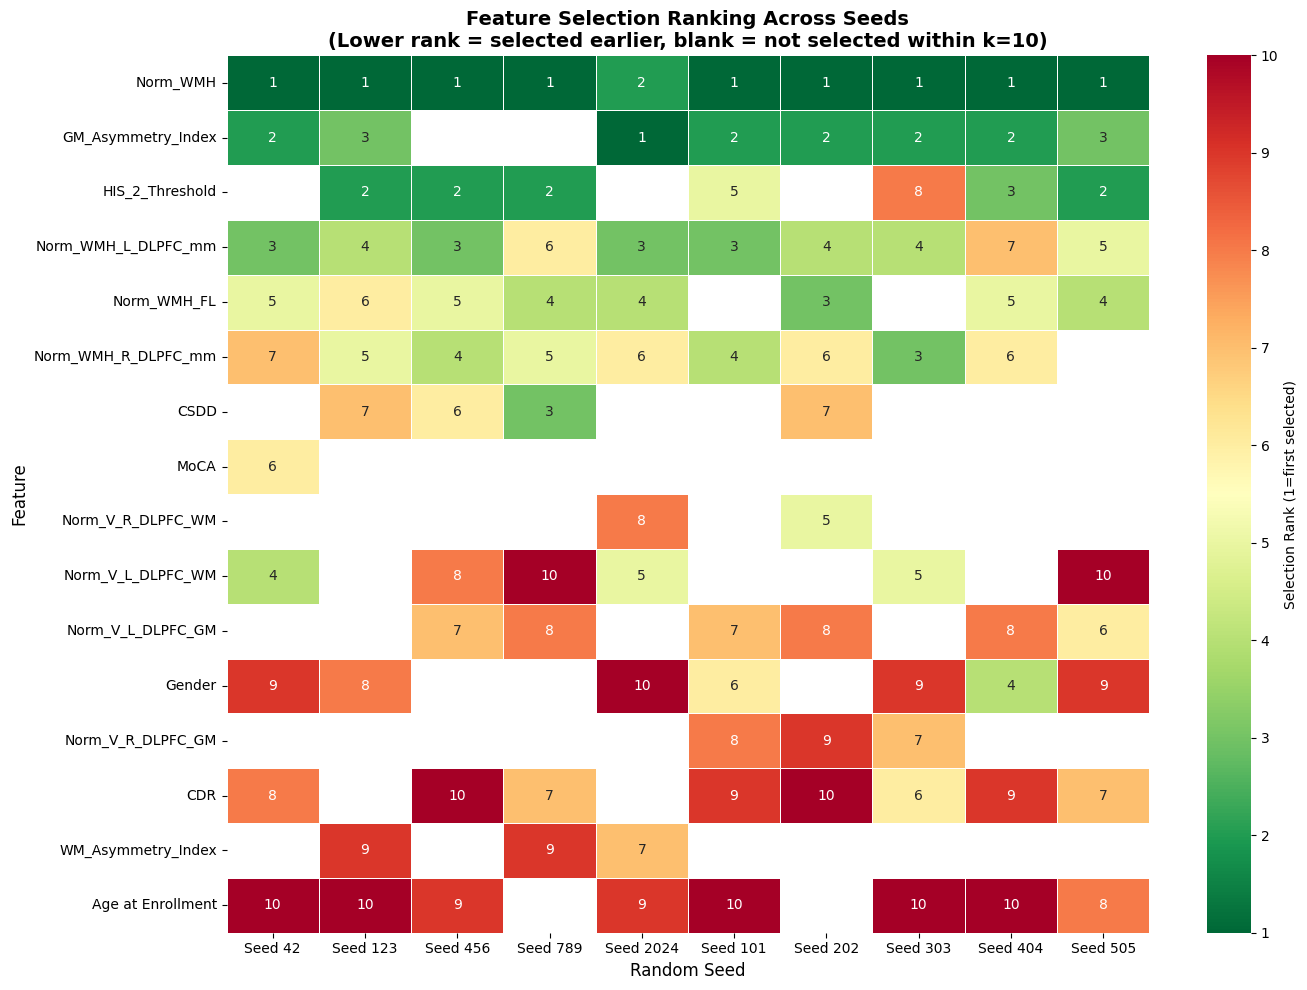

✓ Ranking heatmap saved to: SFS\plots_ranking_heatmap_20260106_234113.png

SFS ANALYSIS COMPLETE

📁 All outputs saved to: SFS/

Files generated:
   - 01_svm_tuning_20260106_234113.txt
   - 02_svm_results_20260106_234113.txt
   - 03_sfs_seed_101_20260106_234113.txt
   - 03_sfs_seed_123_20260106_234113.txt
   - 03_sfs_seed_2024_20260106_234113.txt
   - 03_sfs_seed_202_20260106_234113.txt
   - 03_sfs_seed_303_20260106_234113.txt
   - 03_sfs_seed_404_20260106_234113.txt
   - 03_sfs_seed_42_20260106_234113.txt
   - 03_sfs_seed_456_20260106_234113.txt
   - 03_sfs_seed_505_20260106_234113.txt
   - 03_sfs_seed_789_20260106_234113.txt
   - 04_sfs_summary_20260106_234113.txt
   - 05_ranking_comparison_20260106_234113.txt
   - feature_rankings_20260106_234113.csv
   - plots_ranking_heatmap_20260106_234113.png
   - plots_sfs_multi_seed_20260106_234113.png
   - sfs_all_results_20260106_234113.csv
   - svm_cv_results_20260106_234113.csv



In [ ]:
# ============================================================
# RANKING HEATMAP VISUALIZATION
# ============================================================

# Create heatmap of feature rankings across seeds
fig, ax = plt.subplots(figsize=(14, 10))

# Prepare data for heatmap
heatmap_data = []
for feature in ranking_df['Feature']:
    row = []
    for seed in RANDOM_SEEDS:
        col_name = f'Seed_{seed}'
        val = ranking_df[ranking_df['Feature'] == feature][col_name].values[0]
        if val == '-':
            row.append(np.nan)
        else:
            row.append(val)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data,
                          index=ranking_df['Feature'],
                          columns=[f'Seed {s}' for s in RANDOM_SEEDS])

# Sort by average rank
heatmap_df['Avg'] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values('Avg')
heatmap_df = heatmap_df.drop('Avg', axis=1)

# Plot heatmap
import seaborn as sns
mask = heatmap_df.isna()
sns.heatmap(heatmap_df, annot=True, fmt='.0f', cmap='RdYlGn_r',
            mask=mask, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Selection Rank (1=first selected)'},
            annot_kws={'size': 10})

ax.set_title(f'Feature Selection Ranking Across Seeds\n(Lower rank = selected earlier, blank = not selected within k={SFS_MAX_FEATURES})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Random Seed', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

plt.tight_layout()
heatmap_path = os.path.join(SFS_OUTPUT_DIR, f"plots_ranking_heatmap_{RUN_TIMESTAMP}.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Ranking heatmap saved to: {heatmap_path}")

# Final summary
print("\n" + "=" * 70)
print("SFS ANALYSIS COMPLETE")
print("=" * 70)
print(f"\n📁 All outputs saved to: {SFS_OUTPUT_DIR}/")
print(f"\nFiles generated:")
for f in sorted(os.listdir(SFS_OUTPUT_DIR)):
    if RUN_TIMESTAMP in f:
        print(f"   - {f}")
print("\n" + "=" * 70)


---

## 5.3 Comprehensive Feature Evidence Synthesis

This section integrates findings from **all statistical and feature selection methods** to provide a unified, evidence-based ranking of features.

### Methods Integrated:
1. **ANOVA** — Univariate group difference testing
2. **ANCOVA (Age + Gender)** — Covariate-adjusted significance
3. **ANCOVA (Full)** — Each feature controlled for all others
4. **Cohen's d** — Effect size and directionality
5. **PCA** — Variance contribution ranking
6. **Correlation** — Redundancy identification
7. **SFS (Multi-Seed)** — Selection frequency and ranking stability

### Significance Tiers (Relaxed for Exploratory Analysis):
| Tier | P-Value Range | Interpretation |
|------|---------------|----------------|
| ★★★ Strong | p < 0.05 | Statistically significant (strict) |
| ★★ Moderate | 0.05 ≤ p < 0.10 | Trend toward significance |
| ★ Suggestive | 0.10 ≤ p < 0.20 | Weak evidence, worth noting |
| — None | p ≥ 0.20 | No meaningful evidence |

### Composite Evidence Score (0-100):
- **ANOVA/ANCOVA significance**: Up to 30 points
- **Effect size (Cohen's d)**: Up to 20 points
- **PCA variance contribution**: Up to 15 points
- **SFS selection frequency**: Up to 25 points
- **Redundancy penalty**: -10 points if highly correlated
- **Robustness bonus**: +10 points if significant in multiple methods

This approach ensures potentially important biomarkers are not prematurely dismissed while highlighting the most robust predictors.


COMPREHENSIVE FEATURE EVIDENCE SYNTHESIS
Generated: 2026-01-06 23:51:45
--------------------------------------------------------------------------------
✓ SFS data loaded: 10 seeds, 12 features selected
COMPREHENSIVE FEATURE EVIDENCE SYNTHESIS REPORT
Generated: 2026-01-06 23:51:45
Total Features Analyzed: 16

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
  🟠 SUGGESTIVE EVIDENCE: 8 feature(s)
  🔴 WEAK EVIDENCE: 5 feature(s)
  🟡 MODERATE EVIDENCE: 2 feature(s)
  🟢 STRONG EVIDENCE: 1 feature(s)

  Strictly Significant (ANOVA p<0.05): 1
  Moderately Significant (ANOVA 0.05≤p<0.10): 0
  Suggestive (ANOVA 0.10≤p<0.20): 1
  SFS Consensus Features (≥80% seeds): 2
  Redundant Features: 1

DETAILED FEATURE ANALYSIS (Ranked by Evidence Score)

────────────────────────────────────────────────────────────────────────────────
RANK #1: GM_Asymmetry_Index
─────────────

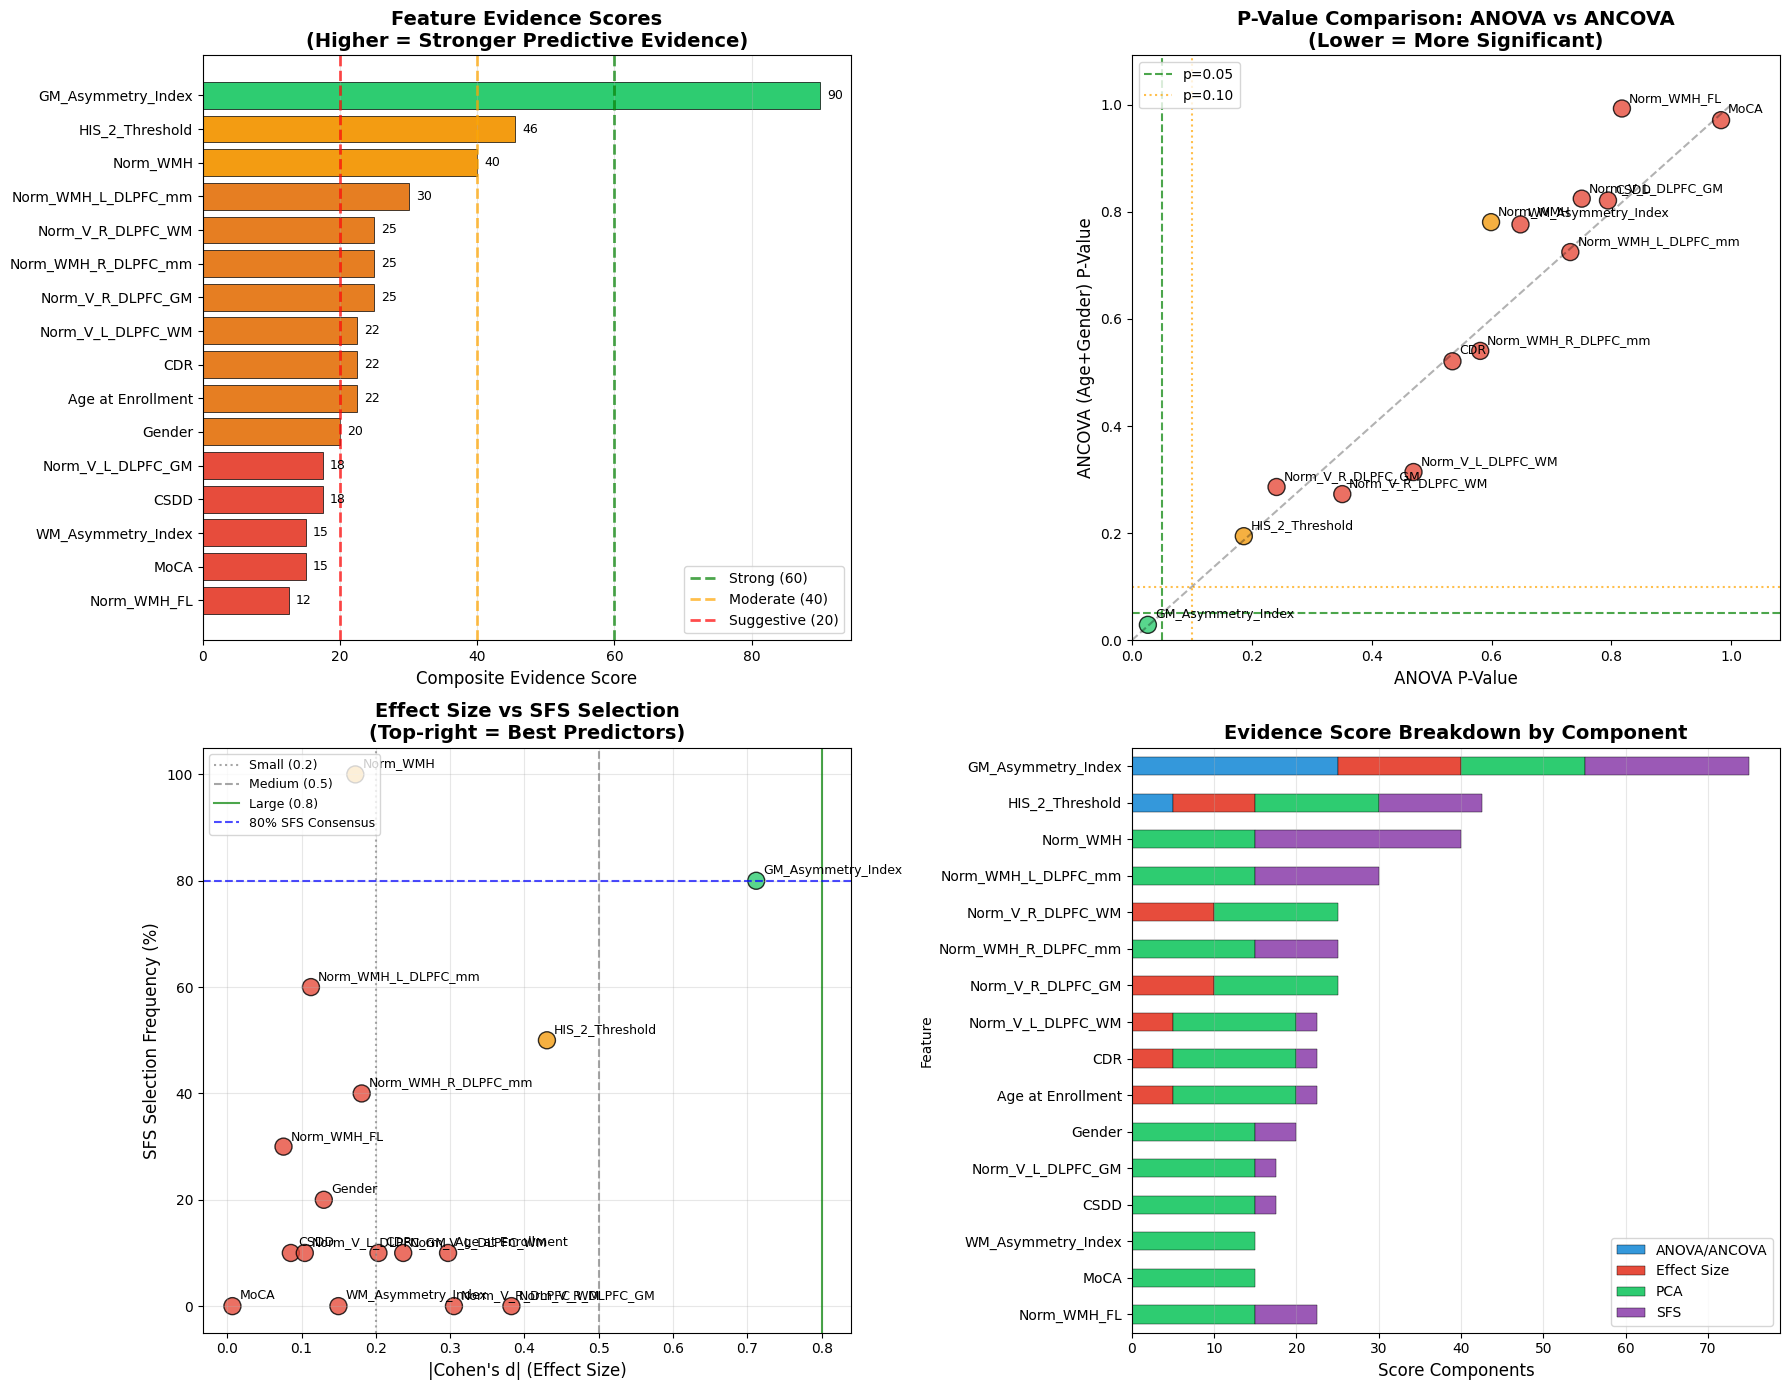


✓ Visualization saved: comprehensive_evidence_synthesis.png
✓ Report saved: D:\My Drive\Dr_Moussavi\Evidence_Synthesis\evidence_report_20260106_235147.txt
✓ Evidence table saved: D:\My Drive\Dr_Moussavi\Evidence_Synthesis\evidence_table_20260106_235147.csv
✓ Visualization copied to: D:\My Drive\Dr_Moussavi\Evidence_Synthesis\evidence_synthesis_plot_20260106_235147.png

✓ Stored variables: EVIDENCE_STRONG_FEATURES, EVIDENCE_MODERATE_FEATURES, EVIDENCE_RECOMMENDED_FEATURES


In [ ]:
# ============================================================
# COMPREHENSIVE FEATURE EVIDENCE SYNTHESIS
# ============================================================
# Integrates: ANOVA, ANCOVA, Cohen's d, PCA, Correlation, SFS
# Provides: Tiered significance, composite scores, clinical interpretation

import os
from datetime import datetime

print("=" * 80)
print("COMPREHENSIVE FEATURE EVIDENCE SYNTHESIS")
print("=" * 80)
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 80)

# ============================================================
# 1. BUILD MASTER EVIDENCE TABLE
# ============================================================

# Get all features (excluding target)
target_col = 'w5_change_binary_one_threshold'
all_features = [c for c in df_analysis_binary_1_a.columns if c != target_col]

# Initialize master DataFrame
evidence_df = pd.DataFrame({'Feature': all_features})

# --- ANOVA Results ---
anova_merge = anova_results[['Feature', 'F_Score', 'P_Value']].copy()
anova_merge.columns = ['Feature', 'ANOVA_F', 'ANOVA_P']
evidence_df = evidence_df.merge(anova_merge, on='Feature', how='left')

# --- ANCOVA Standard (Age + Gender) ---
try:
    ancova_std_merge = ancova_standard_df[['Feature', 'F_Score_ANCOVA', 'P_Value_ANCOVA']].copy()
    ancova_std_merge.columns = ['Feature', 'ANCOVA_Std_F', 'ANCOVA_Std_P']
    evidence_df = evidence_df.merge(ancova_std_merge, on='Feature', how='left')
except NameError:
    evidence_df['ANCOVA_Std_F'] = np.nan
    evidence_df['ANCOVA_Std_P'] = np.nan

# --- ANCOVA Full (All Features) ---
try:
    ancova_full_merge = ancova_full_df[['Feature', 'F_Score_ANCOVA_Full', 'P_Value_ANCOVA_Full']].copy()
    ancova_full_merge.columns = ['Feature', 'ANCOVA_Full_F', 'ANCOVA_Full_P']
    evidence_df = evidence_df.merge(ancova_full_merge, on='Feature', how='left')
except NameError:
    evidence_df['ANCOVA_Full_F'] = np.nan
    evidence_df['ANCOVA_Full_P'] = np.nan

# --- Cohen's d Effect Size ---
try:
    evidence_df['Cohens_d'] = evidence_df['Feature'].map(FEATURE_EFFECT_SIZES)
    evidence_df['Direction'] = evidence_df['Feature'].map(FEATURE_DIRECTIONS)
except NameError:
    evidence_df['Cohens_d'] = np.nan
    evidence_df['Direction'] = 'Unknown'

# --- PCA Ranking ---
try:
    evidence_df['PCA_Rank'] = evidence_df['Feature'].map(PCA_FEATURE_RANKING)
    pca_contrib = pca_ranking_df.set_index('Feature')['Variance_Contribution_Pct'].to_dict()
    evidence_df['PCA_Contribution'] = evidence_df['Feature'].map(pca_contrib)
except NameError:
    evidence_df['PCA_Rank'] = np.nan
    evidence_df['PCA_Contribution'] = np.nan

# --- Correlation Redundancy ---
try:
    evidence_df['Is_Redundant'] = evidence_df['Feature'].isin(CORRELATION_FEATURES_TO_REMOVE)
except NameError:
    evidence_df['Is_Redundant'] = False

# --- SFS Selection Frequency (from multi-seed analysis) ---
# This uses variables from the SFS multi-seed cells:
# - all_seeds_best_features: {seed: [list of best features]}
# - all_seeds_results: {seed: [list of results per k]}
# - selection_orders: {seed: [ordered list of features as selected]}

n_sfs_seeds_global = 0  # Will be set if SFS data available

try:
    # Method 1: Use all_seeds_best_features (best features per seed)
    if 'all_seeds_best_features' in dir() and all_seeds_best_features:
        n_sfs_seeds_global = len(all_seeds_best_features)

        # Count how many seeds selected each feature (in their best k)
        sfs_selection_counts = {}
        for seed, features in all_seeds_best_features.items():
            for feat in features:
                sfs_selection_counts[feat] = sfs_selection_counts.get(feat, 0) + 1

        evidence_df['SFS_Selection_Count'] = evidence_df['Feature'].map(sfs_selection_counts).fillna(0).astype(int)
        evidence_df['SFS_Selection_Pct'] = evidence_df['SFS_Selection_Count'] / n_sfs_seeds_global * 100

        # Get average rank across seeds using selection_orders if available
        avg_ranks = {}
        if 'selection_orders' in dir() and selection_orders:
            for feat in all_features:
                ranks = []
                for seed, order in selection_orders.items():
                    if feat in order:
                        ranks.append(order.index(feat) + 1)
                if ranks:
                    avg_ranks[feat] = np.mean(ranks)
                else:
                    avg_ranks[feat] = np.nan
        else:
            # Fallback: derive order from all_seeds_results
            for feat in all_features:
                ranks = []
                for seed, results in all_seeds_results.items():
                    # Features appear at k where they were first selected
                    for r in results:
                        if feat in r.get('features', []):
                            ranks.append(r['k'])
                            break
                if ranks:
                    avg_ranks[feat] = np.mean(ranks)
                else:
                    avg_ranks[feat] = np.nan

        evidence_df['SFS_Avg_Rank'] = evidence_df['Feature'].map(avg_ranks)
        print(f"✓ SFS data loaded: {n_sfs_seeds_global} seeds, {len(sfs_selection_counts)} features selected")
    else:
        raise NameError("SFS variables not found")

except (NameError, Exception) as e:
    print(f"⚠ SFS data not available: {e}")
    evidence_df['SFS_Selection_Count'] = 0
    evidence_df['SFS_Selection_Pct'] = 0
    evidence_df['SFS_Avg_Rank'] = np.nan

# ============================================================
# 2. TIERED SIGNIFICANCE CLASSIFICATION
# ============================================================

def get_significance_tier(p_value):
    """Return significance tier and stars based on p-value."""
    if pd.isna(p_value):
        return ('N/A', '—', 0)
    elif p_value < 0.05:
        return ('Strong', '★★★', 3)
    elif p_value < 0.10:
        return ('Moderate', '★★', 2)
    elif p_value < 0.20:
        return ('Suggestive', '★', 1)
    else:
        return ('None', '—', 0)

# Apply to ANOVA
evidence_df['ANOVA_Tier'] = evidence_df['ANOVA_P'].apply(lambda p: get_significance_tier(p)[0])
evidence_df['ANOVA_Stars'] = evidence_df['ANOVA_P'].apply(lambda p: get_significance_tier(p)[1])
evidence_df['ANOVA_Score'] = evidence_df['ANOVA_P'].apply(lambda p: get_significance_tier(p)[2])

# Apply to ANCOVA Standard
evidence_df['ANCOVA_Std_Tier'] = evidence_df['ANCOVA_Std_P'].apply(lambda p: get_significance_tier(p)[0])
evidence_df['ANCOVA_Std_Stars'] = evidence_df['ANCOVA_Std_P'].apply(lambda p: get_significance_tier(p)[1])

# Apply to ANCOVA Full
evidence_df['ANCOVA_Full_Tier'] = evidence_df['ANCOVA_Full_P'].apply(lambda p: get_significance_tier(p)[0])
evidence_df['ANCOVA_Full_Stars'] = evidence_df['ANCOVA_Full_P'].apply(lambda p: get_significance_tier(p)[1])

# ============================================================
# 3. COMPUTE COMPOSITE EVIDENCE SCORE (0-100)
# ============================================================

def compute_evidence_score(row):
    """
    Compute composite evidence score for a feature.
    Higher score = stronger evidence for predictive value.
    """
    score = 0

    # --- ANOVA/ANCOVA Significance (up to 30 points) ---
    # ANOVA contribution (0-15 points)
    if pd.notna(row['ANOVA_P']):
        if row['ANOVA_P'] < 0.05:
            score += 15
        elif row['ANOVA_P'] < 0.10:
            score += 10
        elif row['ANOVA_P'] < 0.20:
            score += 5

    # ANCOVA Standard contribution (0-10 points)
    if pd.notna(row['ANCOVA_Std_P']):
        if row['ANCOVA_Std_P'] < 0.05:
            score += 10
        elif row['ANCOVA_Std_P'] < 0.10:
            score += 6
        elif row['ANCOVA_Std_P'] < 0.20:
            score += 3

    # ANCOVA Full contribution (0-5 points)
    if pd.notna(row['ANCOVA_Full_P']):
        if row['ANCOVA_Full_P'] < 0.05:
            score += 5
        elif row['ANCOVA_Full_P'] < 0.10:
            score += 3

    # --- Effect Size (up to 20 points) ---
    if pd.notna(row['Cohens_d']):
        abs_d = abs(row['Cohens_d'])
        if abs_d >= 0.8:
            score += 20  # Large effect
        elif abs_d >= 0.5:
            score += 15  # Medium effect
        elif abs_d >= 0.3:
            score += 10  # Small-medium effect
        elif abs_d >= 0.2:
            score += 5   # Small effect

    # --- PCA Contribution (up to 15 points) ---
    if pd.notna(row['PCA_Contribution']):
        # Normalize: top contributor gets 15 points
        max_pca = evidence_df['PCA_Contribution'].max()
        if max_pca > 0:
            pca_score = (row['PCA_Contribution'] / max_pca) * 15
            score += pca_score

    # --- SFS Selection Frequency (up to 25 points) ---
    if row['SFS_Selection_Pct'] > 0:
        # 100% selection = 25 points
        sfs_score = (row['SFS_Selection_Pct'] / 100) * 25
        score += sfs_score

    # --- Robustness Bonus (up to 10 points) ---
    # Significant in multiple methods = more robust
    sig_count = 0
    if pd.notna(row['ANOVA_P']) and row['ANOVA_P'] < 0.10:
        sig_count += 1
    if pd.notna(row['ANCOVA_Std_P']) and row['ANCOVA_Std_P'] < 0.10:
        sig_count += 1
    if pd.notna(row['ANCOVA_Full_P']) and row['ANCOVA_Full_P'] < 0.10:
        sig_count += 1
    if row['SFS_Selection_Pct'] >= 60:  # Selected in >=60% of seeds
        sig_count += 1

    if sig_count >= 3:
        score += 10
    elif sig_count >= 2:
        score += 5

    # --- Redundancy Penalty (-10 points) ---
    if row['Is_Redundant']:
        score -= 10

    return round(max(0, min(100, score)), 1)

evidence_df['Evidence_Score'] = evidence_df.apply(compute_evidence_score, axis=1)

# Sort by evidence score
evidence_df = evidence_df.sort_values('Evidence_Score', ascending=False).reset_index(drop=True)

# ============================================================
# 4. CLASSIFY FEATURES INTO EVIDENCE TIERS
# ============================================================

def classify_evidence_tier(score):
    if score >= 60:
        return '🟢 STRONG EVIDENCE'
    elif score >= 40:
        return '🟡 MODERATE EVIDENCE'
    elif score >= 20:
        return '🟠 SUGGESTIVE EVIDENCE'
    else:
        return '🔴 WEAK EVIDENCE'

evidence_df['Evidence_Tier'] = evidence_df['Evidence_Score'].apply(classify_evidence_tier)

# ============================================================
# 5. GENERATE COMPREHENSIVE REPORT
# ============================================================

report_lines = []
report_lines.append("=" * 80)
report_lines.append("COMPREHENSIVE FEATURE EVIDENCE SYNTHESIS REPORT")
report_lines.append("=" * 80)
report_lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append(f"Total Features Analyzed: {len(evidence_df)}")
report_lines.append("")

# --- Summary Statistics ---
report_lines.append("-" * 80)
report_lines.append("SUMMARY STATISTICS")
report_lines.append("-" * 80)

# Count by tier
tier_counts = evidence_df['Evidence_Tier'].value_counts()
for tier, count in tier_counts.items():
    report_lines.append(f"  {tier}: {count} feature(s)")

report_lines.append("")
report_lines.append(f"  Strictly Significant (ANOVA p<0.05): {(evidence_df['ANOVA_P'] < 0.05).sum()}")
report_lines.append(f"  Moderately Significant (ANOVA 0.05≤p<0.10): {((evidence_df['ANOVA_P'] >= 0.05) & (evidence_df['ANOVA_P'] < 0.10)).sum()}")
report_lines.append(f"  Suggestive (ANOVA 0.10≤p<0.20): {((evidence_df['ANOVA_P'] >= 0.10) & (evidence_df['ANOVA_P'] < 0.20)).sum()}")
report_lines.append(f"  SFS Consensus Features (≥80% seeds): {(evidence_df['SFS_Selection_Pct'] >= 80).sum()}")
report_lines.append(f"  Redundant Features: {evidence_df['Is_Redundant'].sum()}")

# --- Detailed Feature-by-Feature Analysis ---
report_lines.append("")
report_lines.append("=" * 80)
report_lines.append("DETAILED FEATURE ANALYSIS (Ranked by Evidence Score)")
report_lines.append("=" * 80)

for idx, row in evidence_df.iterrows():
    report_lines.append("")
    report_lines.append(f"{'─' * 80}")
    report_lines.append(f"RANK #{idx + 1}: {row['Feature']}")
    report_lines.append(f"{'─' * 80}")
    report_lines.append(f"  Evidence Tier: {row['Evidence_Tier']}")
    report_lines.append(f"  Composite Score: {row['Evidence_Score']:.1f} / 100")
    report_lines.append("")

    # ANOVA
    anova_sig = "✓ SIGNIFICANT" if row['ANOVA_P'] < 0.05 else ("~ Trend" if row['ANOVA_P'] < 0.10 else "✗ Not significant")
    report_lines.append(f"  📊 ANOVA:")
    report_lines.append(f"     F-Score: {row['ANOVA_F']:.3f}")
    report_lines.append(f"     P-Value: {row['ANOVA_P']:.4f} {row['ANOVA_Stars']}")
    report_lines.append(f"     Tier: {row['ANOVA_Tier']} ({anova_sig})")

    # ANCOVA Standard
    if pd.notna(row['ANCOVA_Std_P']):
        ancova_std_sig = "✓ SIGNIFICANT" if row['ANCOVA_Std_P'] < 0.05 else ("~ Trend" if row['ANCOVA_Std_P'] < 0.10 else "✗ Not significant")
        report_lines.append(f"  📊 ANCOVA (Age+Gender):")
        report_lines.append(f"     F-Score: {row['ANCOVA_Std_F']:.3f}")
        report_lines.append(f"     P-Value: {row['ANCOVA_Std_P']:.4f} {row['ANCOVA_Std_Stars']}")
        report_lines.append(f"     Tier: {row['ANCOVA_Std_Tier']} ({ancova_std_sig})")
    else:
        report_lines.append(f"  📊 ANCOVA (Age+Gender): N/A (is a covariate)")

    # ANCOVA Full
    if pd.notna(row['ANCOVA_Full_P']):
        ancova_full_sig = "✓ SIGNIFICANT" if row['ANCOVA_Full_P'] < 0.05 else ("~ Trend" if row['ANCOVA_Full_P'] < 0.10 else "✗ Not significant")
        report_lines.append(f"  📊 ANCOVA (All Features):")
        report_lines.append(f"     F-Score: {row['ANCOVA_Full_F']:.3f}")
        report_lines.append(f"     P-Value: {row['ANCOVA_Full_P']:.4f} {row['ANCOVA_Full_Stars']}")
        report_lines.append(f"     Tier: {row['ANCOVA_Full_Tier']} ({ancova_full_sig})")

    # Effect Size
    if pd.notna(row['Cohens_d']):
        abs_d = abs(row['Cohens_d'])
        if abs_d >= 0.8:
            effect_mag = "LARGE"
        elif abs_d >= 0.5:
            effect_mag = "MEDIUM"
        elif abs_d >= 0.2:
            effect_mag = "SMALL"
        else:
            effect_mag = "NEGLIGIBLE"
        report_lines.append(f"  📏 Effect Size (Cohen's d):")
        report_lines.append(f"     Value: {row['Cohens_d']:.3f} ({effect_mag})")
        report_lines.append(f"     Direction: {row['Direction']}")

    # PCA
    if pd.notna(row['PCA_Rank']):
        report_lines.append(f"  📈 PCA Variance Contribution:")
        report_lines.append(f"     Rank: #{int(row['PCA_Rank'])} of {len(evidence_df)}")
        report_lines.append(f"     Contribution: {row['PCA_Contribution']:.2f}%")

    # SFS
    report_lines.append(f"  🎯 SFS Selection (Multi-Seed):")
    report_lines.append(f"     Selected in: {row['SFS_Selection_Count']}/{n_sfs_seeds_global if n_sfs_seeds_global > 0 else 'N/A'} seeds ({row['SFS_Selection_Pct']:.0f}%)")
    if pd.notna(row['SFS_Avg_Rank']):
        report_lines.append(f"     Average Selection Rank: {row['SFS_Avg_Rank']:.1f}")

    # Redundancy
    if row['Is_Redundant']:
        report_lines.append(f"  ⚠️  REDUNDANCY: Highly correlated with another feature")

    # Clinical Interpretation
    report_lines.append(f"  💡 Interpretation:")
    if row['Evidence_Score'] >= 60:
        report_lines.append(f"     STRONG predictor of treatment outcome. Consider prioritizing in models.")
    elif row['Evidence_Score'] >= 40:
        report_lines.append(f"     MODERATE evidence. Include in comprehensive models.")
    elif row['Evidence_Score'] >= 20:
        report_lines.append(f"     SUGGESTIVE evidence. May contribute in multivariate context.")
    else:
        report_lines.append(f"     WEAK evidence. Consider excluding to reduce model complexity.")

    if pd.notna(row['Cohens_d']) and abs(row['Cohens_d']) >= 0.3:
        if row['Cohens_d'] > 0:
            report_lines.append(f"     Clinical: Higher values associated with WORSE outcome (Decline)")
        else:
            report_lines.append(f"     Clinical: Higher values associated with BETTER outcome (Improvement)")

# --- Feature Tier Summary ---
report_lines.append("")
report_lines.append("=" * 80)
report_lines.append("FEATURE TIERS SUMMARY")
report_lines.append("=" * 80)

for tier in ['🟢 STRONG EVIDENCE', '🟡 MODERATE EVIDENCE', '🟠 SUGGESTIVE EVIDENCE', '🔴 WEAK EVIDENCE']:
    tier_features = evidence_df[evidence_df['Evidence_Tier'] == tier]['Feature'].tolist()
    tier_scores = evidence_df[evidence_df['Evidence_Tier'] == tier]['Evidence_Score'].tolist()
    report_lines.append(f"\n{tier}:")
    if tier_features:
        for feat, score in zip(tier_features, tier_scores):
            report_lines.append(f"  • {feat} (Score: {score:.1f})")
    else:
        report_lines.append("  (none)")

# --- Strictly Significant vs Notable (DETAILED FORMAT) ---
report_lines.append("")
report_lines.append("=" * 80)
report_lines.append("🏆 STRICT SIGNIFICANCE ANALYSIS (DETAILED)")
report_lines.append("=" * 80)
report_lines.append("")
report_lines.append("Legend: * = significant (p<0.05), (ns) = not significant by strict criteria")
report_lines.append("")

strictly_sig = evidence_df[evidence_df['ANOVA_P'] < 0.05].copy()
# Get next best 3-4 features after strictly significant ones (sorted by evidence score)
not_strict = evidence_df[evidence_df['ANOVA_P'] >= 0.05].copy()
next_best = not_strict.head(4)  # Top 4 by evidence score

# Use the global SFS seeds count from earlier in this cell
n_sfs_seeds = n_sfs_seeds_global if n_sfs_seeds_global > 0 else 'N/A'

report_lines.append("🏆 STRICTLY SIGNIFICANT (p < 0.05):")
report_lines.append("-" * 60)
if len(strictly_sig) > 0:
    for _, row in strictly_sig.iterrows():
        # ANOVA with significance marker
        anova_str = f"ANOVA p={row['ANOVA_P']:.4f}*"

        # ANCOVA with significance marker
        if pd.notna(row['ANCOVA_Std_P']):
            ancova_marker = '*' if row['ANCOVA_Std_P'] < 0.05 else ' (ns)'
            ancova_str = f"ANCOVA p={row['ANCOVA_Std_P']:.4f}{ancova_marker}"
        else:
            ancova_str = "ANCOVA: N/A (covariate)"

        report_lines.append(f"")
        report_lines.append(f"  • {row['Feature']}: {anova_str}, {ancova_str}")

        # Direction and effect size
        if pd.notna(row['Cohens_d']):
            abs_d = abs(row['Cohens_d'])
            effect_mag = 'Large' if abs_d >= 0.8 else ('Medium' if abs_d >= 0.5 else ('Small' if abs_d >= 0.2 else 'Negligible'))
            direction = 'Higher values → Decline' if row['Cohens_d'] > 0 else 'Higher values → Improvement'
            report_lines.append(f"    → {direction} (d={row['Cohens_d']:.2f}, {effect_mag} effect)")

        # SFS selection
        if row['SFS_Selection_Pct'] > 0:
            report_lines.append(f"    → Selected by {int(row['SFS_Selection_Count'])}/{n_sfs_seeds} SFS seeds ({row['SFS_Selection_Pct']:.0f}%)")

        # PCA contribution
        if pd.notna(row['PCA_Contribution']):
            report_lines.append(f"    → PCA Variance Contribution: {row['PCA_Contribution']:.2f}% (Rank #{int(row['PCA_Rank'])})")
else:
    report_lines.append("  (none)")

report_lines.append("")
report_lines.append("📋 NEXT BEST CANDIDATES (not strictly significant, but notable):")
report_lines.append("-" * 60)
if len(next_best) > 0:
    for _, row in next_best.iterrows():
        # ANOVA with (ns) marker
        anova_str = f"ANOVA p={row['ANOVA_P']:.4f} (ns)"

        # ANCOVA with significance marker
        if pd.notna(row['ANCOVA_Std_P']):
            ancova_marker = '*' if row['ANCOVA_Std_P'] < 0.05 else ' (ns)'
            ancova_str = f"ANCOVA p={row['ANCOVA_Std_P']:.4f}{ancova_marker}"
        else:
            ancova_str = "ANCOVA: N/A (covariate)"

        report_lines.append(f"")
        report_lines.append(f"  • {row['Feature']}: {anova_str}, {ancova_str}")

        # Direction and effect size
        if pd.notna(row['Cohens_d']):
            abs_d = abs(row['Cohens_d'])
            effect_mag = 'Large' if abs_d >= 0.8 else ('Medium' if abs_d >= 0.5 else ('Small' if abs_d >= 0.2 else 'Negligible'))
            direction = 'Higher values → Decline' if row['Cohens_d'] > 0 else 'Higher values → Improvement'
            report_lines.append(f"    → {direction} (d={row['Cohens_d']:.2f}, {effect_mag} effect)")

        # SFS selection
        if row['SFS_Selection_Pct'] > 0:
            report_lines.append(f"    → Selected by {int(row['SFS_Selection_Count'])}/{n_sfs_seeds} SFS seeds ({row['SFS_Selection_Pct']:.0f}%)")

        # PCA contribution
        if pd.notna(row['PCA_Contribution']):
            report_lines.append(f"    → PCA Variance Contribution: {row['PCA_Contribution']:.2f}% (Rank #{int(row['PCA_Rank'])})")

        # Note about significance
        if row['ANOVA_P'] < 0.10:
            report_lines.append(f"    ⚠ Note: Shows TREND toward significance (p<0.10)")
        elif row['ANOVA_P'] < 0.20:
            report_lines.append(f"    ⚠ Note: Suggestive evidence (p<0.20), worth monitoring")
else:
    report_lines.append("  (none)")

# Also show remaining features briefly
remaining = not_strict.iloc[4:] if len(not_strict) > 4 else pd.DataFrame()
if len(remaining) > 0:
    report_lines.append("")
    report_lines.append("📝 REMAINING FEATURES (lower evidence):")
    report_lines.append("-" * 60)
    for _, row in remaining.iterrows():
        sig_status = '(ns)' if row['ANOVA_P'] >= 0.05 else '*'
        report_lines.append(f"  • {row['Feature']}: ANOVA p={row['ANOVA_P']:.4f} {sig_status}, Evidence Score={row['Evidence_Score']:.1f}")

# --- Recommendations ---
report_lines.append("")
report_lines.append("=" * 80)
report_lines.append("RECOMMENDATIONS FOR MACHINE LEARNING")
report_lines.append("=" * 80)

strong_features = evidence_df[evidence_df['Evidence_Score'] >= 60]['Feature'].tolist()
moderate_features = evidence_df[(evidence_df['Evidence_Score'] >= 40) & (evidence_df['Evidence_Score'] < 60)]['Feature'].tolist()
consensus_sfs = evidence_df[evidence_df['SFS_Selection_Pct'] >= 80]['Feature'].tolist()

report_lines.append(f"\n📌 RECOMMENDED FEATURE SET (Strong + Moderate Evidence):")
recommended = strong_features + moderate_features
report_lines.append(f"   {recommended if recommended else 'All features'}")
report_lines.append(f"   Total: {len(recommended)} features")

report_lines.append(f"\n📌 MINIMAL FEATURE SET (Strong Evidence Only):")
report_lines.append(f"   {strong_features if strong_features else 'N/A - use top features by score'}")
report_lines.append(f"   Total: {len(strong_features)} features")

report_lines.append(f"\n📌 SFS CONSENSUS FEATURES (Selected in ≥80% of seeds):")
report_lines.append(f"   {consensus_sfs if consensus_sfs else 'N/A'}")
report_lines.append(f"   Total: {len(consensus_sfs)} features")

report_lines.append(f"\n📌 FEATURES TO CONSIDER EXCLUDING (Weak Evidence + Redundant):")
exclude_features = evidence_df[(evidence_df['Evidence_Score'] < 20) | (evidence_df['Is_Redundant'])]['Feature'].tolist()
report_lines.append(f"   {exclude_features if exclude_features else 'None'}")

report_lines.append("")
report_lines.append("=" * 80)

# Print the report
full_report = '\n'.join(report_lines)
print(full_report)

# ============================================================
# 6. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- Plot 1: Evidence Score Bar Chart ---
ax1 = axes[0, 0]
plot_data = evidence_df.sort_values('Evidence_Score', ascending=True)
colors = ['#2ecc71' if s >= 60 else '#f39c12' if s >= 40 else '#e67e22' if s >= 20 else '#e74c3c'
          for s in plot_data['Evidence_Score']]
ax1.barh(plot_data['Feature'], plot_data['Evidence_Score'], color=colors, edgecolor='black', linewidth=0.5)
ax1.axvline(x=60, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Strong (60)')
ax1.axvline(x=40, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Moderate (40)')
ax1.axvline(x=20, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Suggestive (20)')
ax1.set_xlabel('Composite Evidence Score', fontsize=12)
ax1.set_title('Feature Evidence Scores\n(Higher = Stronger Predictive Evidence)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='x', alpha=0.3)
for i, (feat, score) in enumerate(zip(plot_data['Feature'], plot_data['Evidence_Score'])):
    ax1.text(score + 1, i, f'{score:.0f}', va='center', fontsize=9)

# --- Plot 2: P-Value Comparison (ANOVA vs ANCOVA) ---
ax2 = axes[0, 1]
valid_data = evidence_df.dropna(subset=['ANOVA_P', 'ANCOVA_Std_P'])
if len(valid_data) > 0:
    colors2 = ['#2ecc71' if s >= 60 else '#f39c12' if s >= 40 else '#e74c3c' for s in valid_data['Evidence_Score']]
    ax2.scatter(valid_data['ANOVA_P'], valid_data['ANCOVA_Std_P'], c=colors2, s=150, alpha=0.8, edgecolors='black')
    for _, row in valid_data.iterrows():
        ax2.annotate(row['Feature'], (row['ANOVA_P'], row['ANCOVA_Std_P']),
                    textcoords="offset points", xytext=(5, 5), fontsize=9)
    ax2.axhline(y=0.05, color='green', linestyle='--', alpha=0.7, label='p=0.05')
    ax2.axvline(x=0.05, color='green', linestyle='--', alpha=0.7)
    ax2.axhline(y=0.10, color='orange', linestyle=':', alpha=0.7, label='p=0.10')
    ax2.axvline(x=0.10, color='orange', linestyle=':', alpha=0.7)
    ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax2.set_xlabel('ANOVA P-Value', fontsize=12)
    ax2.set_ylabel('ANCOVA (Age+Gender) P-Value', fontsize=12)
    ax2.set_title('P-Value Comparison: ANOVA vs ANCOVA\n(Lower = More Significant)', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=10)
    ax2.set_xlim(0, max(0.5, valid_data['ANOVA_P'].max() * 1.1))
    ax2.set_ylim(0, max(0.5, valid_data['ANCOVA_Std_P'].max() * 1.1))
else:
    ax2.text(0.5, 0.5, 'ANCOVA data not available', ha='center', va='center', fontsize=14)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)

# --- Plot 3: Effect Size vs SFS Selection ---
ax3 = axes[1, 0]
valid_data3 = evidence_df.dropna(subset=['Cohens_d'])
if len(valid_data3) > 0 and valid_data3['SFS_Selection_Pct'].sum() > 0:
    colors3 = ['#2ecc71' if s >= 60 else '#f39c12' if s >= 40 else '#e74c3c' for s in valid_data3['Evidence_Score']]
    ax3.scatter(valid_data3['Cohens_d'].abs(), valid_data3['SFS_Selection_Pct'],
                c=colors3, s=150, alpha=0.8, edgecolors='black')
    for _, row in valid_data3.iterrows():
        ax3.annotate(row['Feature'], (abs(row['Cohens_d']), row['SFS_Selection_Pct']),
                    textcoords="offset points", xytext=(5, 5), fontsize=9)
    ax3.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7, label='Small (0.2)')
    ax3.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Medium (0.5)')
    ax3.axvline(x=0.8, color='green', linestyle='-', alpha=0.7, label='Large (0.8)')
    ax3.axhline(y=80, color='blue', linestyle='--', alpha=0.7, label='80% SFS Consensus')
ax3.set_xlabel('|Cohen\'s d| (Effect Size)', fontsize=12)
ax3.set_ylabel('SFS Selection Frequency (%)', fontsize=12)
ax3.set_title('Effect Size vs SFS Selection\n(Top-right = Best Predictors)', fontsize=14, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(alpha=0.3)

# --- Plot 4: Evidence Breakdown Stacked Bar ---
ax4 = axes[1, 1]
# Compute score components for visualization
score_components = pd.DataFrame({
    'Feature': evidence_df['Feature'],
    'ANOVA/ANCOVA': evidence_df.apply(lambda r:
        (15 if r['ANOVA_P'] < 0.05 else (10 if r['ANOVA_P'] < 0.10 else (5 if r['ANOVA_P'] < 0.20 else 0))) +
        (10 if pd.notna(r['ANCOVA_Std_P']) and r['ANCOVA_Std_P'] < 0.05 else
         (6 if pd.notna(r['ANCOVA_Std_P']) and r['ANCOVA_Std_P'] < 0.10 else 0)), axis=1),
    'Effect Size': evidence_df['Cohens_d'].abs().apply(lambda d:
        20 if d >= 0.8 else (15 if d >= 0.5 else (10 if d >= 0.3 else (5 if d >= 0.2 else 0))) if pd.notna(d) else 0),
    'PCA': evidence_df['PCA_Contribution'].apply(lambda p:
        (p / evidence_df['PCA_Contribution'].max()) * 15 if pd.notna(p) and evidence_df['PCA_Contribution'].max() > 0 else 0),
    'SFS': evidence_df['SFS_Selection_Pct'] / 100 * 25
})
score_components = score_components.set_index('Feature')
score_components = score_components.loc[evidence_df.sort_values('Evidence_Score', ascending=True)['Feature']]

score_components.plot(kind='barh', stacked=True, ax=ax4,
                      color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'],
                      edgecolor='black', linewidth=0.3)
ax4.set_xlabel('Score Components', fontsize=12)
ax4.set_title('Evidence Score Breakdown by Component', fontsize=14, fontweight='bold')
ax4.legend(loc='lower right', fontsize=10)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_evidence_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved: comprehensive_evidence_synthesis.png")

# ============================================================
# 7. SAVE RESULTS TO FILES
# ============================================================

# Create output directory
output_dir = os.path.join(os.getcwd(), 'Evidence_Synthesis')
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save report as TXT
report_path = os.path.join(output_dir, f'evidence_report_{timestamp}.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(full_report)
print(f"✓ Report saved: {report_path}")

# Save evidence table as CSV
csv_path = os.path.join(output_dir, f'evidence_table_{timestamp}.csv')
evidence_df.to_csv(csv_path, index=False)
print(f"✓ Evidence table saved: {csv_path}")

# Copy visualization to output folder
import shutil
viz_src = 'comprehensive_evidence_synthesis.png'
viz_dst = os.path.join(output_dir, f'evidence_synthesis_plot_{timestamp}.png')
if os.path.exists(viz_src):
    shutil.copy(viz_src, viz_dst)
    print(f"✓ Visualization copied to: {viz_dst}")

# Store key results for downstream use
EVIDENCE_STRONG_FEATURES = evidence_df[evidence_df['Evidence_Score'] >= 60]['Feature'].tolist()
EVIDENCE_MODERATE_FEATURES = evidence_df[(evidence_df['Evidence_Score'] >= 40) & (evidence_df['Evidence_Score'] < 60)]['Feature'].tolist()
EVIDENCE_RECOMMENDED_FEATURES = EVIDENCE_STRONG_FEATURES + EVIDENCE_MODERATE_FEATURES

print(f"\n✓ Stored variables: EVIDENCE_STRONG_FEATURES, EVIDENCE_MODERATE_FEATURES, EVIDENCE_RECOMMENDED_FEATURES")
print("=" * 80)


---

## 6. Machine Learning Modeling Framework

### 6.1 Framework Definition

This section defines a flexible modeling framework supporting:
- **L1 Logistic Regression**: Sparse feature selection via L1 regularization
- **Random Forest**: Ensemble of decision trees with bagging
- **XGBoost**: Gradient boosted decision trees

Key features:
- Nested cross-validation for unbiased performance estimation
- Grid search for hyperparameter tuning
- SMOTE support for handling class imbalance
- Diagnostic models for comparison
- Automatic artifact saving with versioning


In [11]:
"""
Hyper-Flexible Modeling Framework for Active Binary-1 Dataset
=============================================================

Core features:
- Works with df_binary_1_a (Active R2/R4, binary-1 target).
- Target: w5_change_binary_one_threshold (Declined vs Improved).
  * Declined -> 1 (positive, "bad" outcome we want to catch).
  * Improved -> 0 (negative).
- Supports 3 models:
  * L1-regularized Logistic Regression
  * Random Forest
  * XGBoost

Fully soft-coded:
- Model factories accept:
  * base_kwargs: dict of estimator init kwargs
  * grid_overrides: dict to override / extend default param grids
- Diagnostic models accept:
  * diag_kwargs: dict of diagnostic estimator init kwargs
  * diag_threshold: float for decision threshold

Validation:
- Stratified train/test split with configurable test_size and seed.
- Nested or non-nested CV:
  * with arbitrary CV classes (StratifiedKFold, RepeatedStratifiedKFold, etc.)
  * all CV parameters set in main().

Outputs:
- Detailed logs (CV, tuning, test metrics).
- Feature effects (coefficients + odds ratios for L1, importances for RF/XGB).
- Diagnostic models with metrics and feature effects.
- All artifacts saved under ROOT_MODEL_DIR/<model_tag>/.
"""

import os
import joblib
import numpy as np
import pandas as pd

from typing import Dict, Tuple, Any, Optional, Callable

from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, RepeatedStratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    f1_score, precision_score, recall_score, confusion_matrix
)

import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Replace sklearn Pipeline



# =============================================================================
# 1. PROJECT-WIDE CONSTANTS AND DATA LOADING
# =============================================================================

TARGET = "w5_change_binary_one_threshold"
EXPLICIT_BINARY = ["Gender", "HIS_2_Threshold"]
ROOT_MODEL_DIR = "model_params_generic_soft"


def load_project_dataframe() -> pd.DataFrame:
    """
    Load df_binary_1_a prepared in a separate script.

    Requirements for df_binary_1_a:
    - Active (R2+R4) only
    - Non-missing TIV
    - Target column w5_change_binary_one_threshold with values "Declined"/"Improved"
    - Only the selected features (clinical, structural, symmetry, vascular, Gender, HIS_2_Threshold)
    """
    print("\n[DATA] Loading project dataframe: df_binary_1_a")
    df = df_binary_1_a.copy()
    print(f"       Shape: {df.shape}")
    print("       Raw target value counts:")
    print(df[TARGET].value_counts(dropna=False))
    return df


# =============================================================================
# 2. ENCODING & FEATURE TYPE DETECTION
# =============================================================================

def encode_target_and_binary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Encode target and explicit binary features to 0/1.

    Target:
        Declined -> 1  (positive class)
        Improved -> 0  (negative class)

    Predictors:
        Gender: Male -> 1, Female -> 0
        HIS_2_Threshold: High -> 1, Low -> 0
    """
    print("\n[ENCODE] Encoding target and binary predictors...")

    target_map = {"Declined": 1, "Improved": 0}
    df[TARGET] = df[TARGET].map(target_map)
    if df[TARGET].isna().any():
        raise ValueError("Unmapped values in TARGET after Declined/Improved mapping.")
    df[TARGET] = df[TARGET].astype(int)
    print("         TARGET mapped: Declined -> 1, Improved -> 0")
    print("         Target counts after mapping:")
    print(df[TARGET].value_counts())

    if "Gender" in df.columns:
        print("\n         Encoding Gender: Male->1, Female->0")
        gender_map = {"Male": 1, "Female": 0}
        df["Gender"] = df["Gender"].map(gender_map)
        if df["Gender"].isna().any():
            print("         WARNING: Some Gender values not mapped. Check raw data.")
        df["Gender"] = df["Gender"].astype(float)
        print("         Gender counts after mapping:")
        print(df["Gender"].value_counts(dropna=False))

    if "HIS_2_Threshold" in df.columns:
        print("\n         Encoding HIS_2_Threshold: High->1, Low->0")
        his_map = {"High": 1, "Low": 0}
        df["HIS_2_Threshold"] = df["HIS_2_Threshold"].map(his_map)
        if df["HIS_2_Threshold"].isna().any():
            print("         WARNING: Some HIS_2_Threshold values not mapped. Check raw data.")
        df["HIS_2_Threshold"] = df["HIS_2_Threshold"].astype(float)
        print("         HIS_2_Threshold counts after mapping:")
        print(df["HIS_2_Threshold"].value_counts(dropna=False))

    return df


def detect_feature_types(
    df: pd.DataFrame,
    target_col: str,
    explicit_binary: list
) -> Tuple[list, list]:
    """
    Detect numeric vs binary feature columns.

    binary_cols:
        - All in explicit_binary
        - All numeric columns with exactly 2 unique non-NA values
    numeric_cols:
        - Remaining numeric columns, excluding target and binary
    leftovers:
        - Any non-numeric, non-binary, non-target -> error
    """
    print("\n[FEATURE TYPES] Detecting numeric / binary / leftover columns...")
    binary_cols = []

    for c in df.columns:
        if c == target_col:
            continue
        if c in explicit_binary:
            binary_cols.append(c)
            continue
        if np.issubdtype(df[c].dtype, np.number) and df[c].nunique(dropna=True) == 2:
            if c not in binary_cols:
                binary_cols.append(c)

    numeric_cols = [
        c for c in df.columns
        if c not in binary_cols + [target_col]
        and np.issubdtype(df[c].dtype, np.number)
    ]

    leftovers = [
        c for c in df.columns
        if c not in numeric_cols + binary_cols + [target_col]
    ]

    print(f"               Binary columns:  {binary_cols}")
    print(f"               Numeric columns: {numeric_cols}")
    if leftovers:
        print(f"               Leftover columns: {leftovers}")
        raise ValueError(f"Columns need encoding before modeling: {leftovers}")
    else:
        print("               No leftover columns. All features numeric or binary.")
    return numeric_cols, binary_cols


# =============================================================================
# 3. PREPROCESSING & TRAIN/TEST SPLIT
# =============================================================================

def stratified_split(
    df: pd.DataFrame,
    numeric_cols: list,
    binary_cols: list,
    target_col: str,
    test_size: float,
    rnd: int
):
    """
    Perform a stratified train/test split.

    Returns:
        X_train, X_test, y_train, y_test
    """
    print("\n[SPLIT] Creating stratified train/test split...")
    X = df[numeric_cols + binary_cols].copy()
    y = df[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=rnd
    )

    print(f"        X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
    print("        Train target counts:")
    print(y_train.value_counts())
    print("        Test target counts:")
    print(y_test.value_counts())
    return X_train, X_test, y_train, y_test


def build_preprocessor(
    numeric_cols: list,
    binary_cols: list
) -> ColumnTransformer:
    """
    Build a ColumnTransformer:

    - Numeric:
        median imputation -> StandardScaler
    - Binary:
        most_frequent imputation -> passthrough
    """
    print("\n[PREP] Building ColumnTransformer (numeric + binary)...")
    preproc = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler())
            ]), numeric_cols),
            ("bin", Pipeline(steps=[
                ("impute", SimpleImputer(strategy="most_frequent"))
            ]), binary_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    print("       Preprocessor ready.")
    return preproc


# =============================================================================
# 4. MODEL FACTORIES (SOFT-CODED)
# =============================================================================

def merge_dicts(base: Dict[str, Any], override: Optional[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Helper: merge two dicts, with override taking precedence.
    """
    if override is None:
        return base
    new = base.copy()
    new.update(override)
    return new


def make_l1_logistic_model_and_grid(
    rnd: int,
    base_kwargs: Optional[Dict[str, Any]] = None,
    grid_overrides: Optional[Dict[str, Any]] = None
):
    """
    Factory for L1-regularized Logistic Regression and its param grid.

    Parameters:
        rnd          : random_state
        base_kwargs  : overrides for LogisticRegression init parameters
        grid_overrides : overrides for param grid entries, e.g.
            {"clf__C": np.logspace(-3, 3, 10)}

    Returns:
        base_clf, param_grid, model_tag
    """
    default_kwargs = dict(
        penalty="l1",
        solver="saga",
        max_iter=5000,
        tol=1e-4,
        random_state=rnd
    )
    final_kwargs = merge_dicts(default_kwargs, base_kwargs)

    base_clf = LogisticRegression(**final_kwargs)

    default_grid = {
        "clf__C": np.logspace(-4, 4, 20),
        "clf__class_weight": [None, "balanced"]
    }
    param_grid = merge_dicts(default_grid, grid_overrides)

    model_tag = "l1"
    return base_clf, param_grid, model_tag


def make_random_forest_model_and_grid(
    rnd: int,
    base_kwargs: Optional[Dict[str, Any]] = None,
    grid_overrides: Optional[Dict[str, Any]] = None
):
    """
    Factory for RandomForestClassifier and its param grid.

    Parameters:
        rnd           : random_state
        base_kwargs   : overrides for RF init params (e.g., {"min_samples_split": 5})
        grid_overrides: overrides for param grid (keys must start with "clf__")

    Returns:
        base_clf, param_grid, model_tag
    """
    default_kwargs = dict(
        random_state=rnd,
        n_jobs=-1
    )
    final_kwargs = merge_dicts(default_kwargs, base_kwargs)

    base_clf = RandomForestClassifier(**final_kwargs)

    default_grid = {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 10, None],
        "clf__class_weight": ["balanced", None],
        "clf__max_features": ["sqrt", 0.33]
    }
    param_grid = merge_dicts(default_grid, grid_overrides)

    model_tag = "rf"
    return base_clf, param_grid, model_tag


def make_xgb_model_and_grid(
    rnd: int,
    base_kwargs: Optional[Dict[str, Any]] = None,
    grid_overrides: Optional[Dict[str, Any]] = None,
    scale_pos_weight_default: Optional[float] = None
):
    """
    Factory for XGBClassifier and its param grid.

    Parameters:
        rnd                   : random_state
        base_kwargs           : overrides for XGB init args
        grid_overrides        : overrides for param grid (keys "clf__...")
        scale_pos_weight_default : if provided, injected into the scale_pos_weight grid

    Returns:
        base_clf, param_grid, model_tag
    """
    default_kwargs = dict(
        random_state=rnd,
        objective="binary:logistic",
        eval_metric="logloss",
        device="cuda",
        n_jobs=-1
    )
    final_kwargs = merge_dicts(default_kwargs, base_kwargs)

    base_clf = xgb.XGBClassifier(**final_kwargs)

    scale_weights = [0.5, 1.0, 1.9]
    if scale_pos_weight_default is not None:
        scale_weights = sorted(set(scale_weights + [scale_pos_weight_default]))

    default_grid = {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 8],
        "clf__learning_rate": [0.01, 0.1, 0.3],
        "clf__scale_pos_weight": scale_weights,
    }
    param_grid = merge_dicts(default_grid, grid_overrides)

    model_tag = "xgb"
    return base_clf, param_grid, model_tag


# =============================================================================
# 5. GENERIC CV AND EVALUATION
# =============================================================================

def build_pipeline(
    preproc: ColumnTransformer,
    base_estimator,
    use_smote: bool = False,
    smote_k_neighbors: int = 2,  # Low for tiny datasets
    smote_random_state: int = 42
) -> Pipeline:
    """
    Combine preprocessor and classifier in a single pipeline.

    Optionally includes SMOTE for handling class imbalance.

    Parameters:
        preproc: ColumnTransformer for preprocessing
        base_estimator: The classifier (L1, RF, XGB)
        use_smote: Whether to apply SMOTE oversampling
        smote_k_neighbors: Number of neighbors for SMOTE (use 2-3 for tiny datasets)
        smote_random_state: Random seed for SMOTE

    Returns:
        Pipeline or ImbPipeline (if SMOTE is used)
    """
    if use_smote:
        # Use imbalanced-learn Pipeline when SMOTE is included
        from imblearn.pipeline import Pipeline as ImbPipeline

        print(f"       [SMOTE] Enabled with k_neighbors={smote_k_neighbors}")
        pipe = ImbPipeline(steps=[
            ("prep", preproc),
            ("smote", SMOTE(
                random_state=smote_random_state,
                k_neighbors=smote_k_neighbors  # Critical for tiny datasets!
            )),
            ("clf", base_estimator)
        ])
    else:
        # Use standard sklearn Pipeline
        pipe = Pipeline(steps=[
            ("prep", preproc),
            ("clf", base_estimator)
        ])

    return pipe



def make_cv(
    cv_class,
    n_splits: int,
    n_repeats: Optional[int],
    rnd: int
):
    """
    Build a CV object from the given class and parameters.

    - If n_repeats is None: assume standard K-fold / StratifiedKFold.
    - If n_repeats is not None: assume Repeated* variant.
    """
    if n_repeats is None:
        cv = cv_class(n_splits=n_splits, shuffle=True, random_state=rnd)
    else:
        cv = cv_class(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=rnd
        )
    return cv


def run_nested_cv_and_refit(
    model_tag: str,
    pipe: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    param_grid: Dict[str, Any],
    scoring: str,
    outer_cv,
    inner_cv,
):
    """
    Nested CV:
        Outer CV for unbiased performance estimates,
        Inner CV for hyperparameter tuning.

    Returns:
        outer_metrics, outer_best_params, final_best_params, final_pipe
    """
    print(f"\n[NCV-{model_tag}] Starting nested CV on TRAIN...")

    n_outer_runs = len(list(outer_cv.split(X_train, y_train)))
    print(f"[NCV-{model_tag}] Outer CV will run {n_outer_runs} splits.")

    outer_metrics = {m: [] for m in ["roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall"]}
    outer_best_params = []

    for i, (tr_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\n[NCV-{model_tag}] Outer run {i}/{n_outer_runs}")
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=scoring,
            cv=inner_cv,
            n_jobs=-1,
            refit=True
        )
        grid.fit(X_tr, y_tr)
        # ADD THIS:
        n_candidates = len(grid.cv_results_['params'])
        n_splits = grid.n_splits_
        total_fits = n_candidates * n_splits
        print(f"  [DEBUG] GridSearchCV fit {n_candidates} candidates × {n_splits} splits = {total_fits} total fits")
        best_pipe = grid.best_estimator_
        print(f"  [NCV-{model_tag}] Best params (inner CV): {grid.best_params_}")

        y_val_prob = best_pipe.predict_proba(X_val)[:, 1]
        y_val_pred = (y_val_prob >= 0.5).astype(int)

        outer_metrics["roc_auc"].append(roc_auc_score(y_val, y_val_prob))
        outer_metrics["pr_auc"].append(average_precision_score(y_val, y_val_prob))
        outer_metrics["accuracy"].append(accuracy_score(y_val, y_val_pred))
        outer_metrics["f1"].append(f1_score(y_val, y_val_pred))
        outer_metrics["precision"].append(precision_score(y_val, y_val_pred, zero_division=0))
        outer_metrics["recall"].append(recall_score(y_val, y_val_pred))

        outer_best_params.append(grid.best_params_)

    # How many outer runs actually executed
    n_outer_runs = len(outer_metrics["f1"])
    total_outer = n_outer_runs

    print(f"\n[NCV-{model_tag}] Nested CV summary on TRAIN:")

    # Human‑readable model name
    model_name_full = {
        "l1": "L1 Logistic Regression",
        "rf": "Random Forest",
        "xgb": "XGBoost",
    }.get(model_tag, model_tag.upper())

    # Outer / inner CV info (safe for RepeatedStratifiedKFold)
    outer_folds = getattr(outer_cv, "n_splits", None)
    outer_repeats = getattr(outer_cv, "n_repeats", 1)
    inner_folds = getattr(inner_cv, "n_splits", None)
    inner_repeats = getattr(inner_cv, "n_repeats", 1)

    # Header line
    print(
        f"{model_name_full} — Nested CV on TRAIN "
        f"(Outer {outer_folds}-fold × {outer_repeats} repeats = {total_outer} runs; "
        f"Inner {inner_folds}-fold × {inner_repeats} repeats, scoring={scoring})"
    )

    # Metric means ± SD
    for k, vals in outer_metrics.items():
        vals = np.asarray(vals, dtype=float)
        print(f"  - {k:9s}: {vals.mean():.3f} ± {vals.std():.3f}")

    print(f"  - best params per outer run: {outer_best_params}")


    print(f"\n[NCV-{model_tag}] Refit on FULL TRAIN using inner CV...")
    final_grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )
    final_grid.fit(X_train, y_train)
    final_best_params = final_grid.best_params_
    final_pipe = final_grid.best_estimator_
    print(f"  [NCV-{model_tag}] Final best params: {final_best_params}")

    return outer_metrics, outer_best_params, final_best_params, final_pipe


def run_non_nested_cv_and_refit(
    model_tag: str,
    pipe: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    param_grid: Dict[str, Any],
    scoring: str,
    inner_cv
):
    """
    Non-nested CV:
        Single GridSearchCV on TRAIN.

    Returns:
        outer_metrics=None, outer_best_params=None, final_best_params, final_pipe
    """
    print(f"\n[CV-{model_tag}] Starting non-nested CV on TRAIN...")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_train, y_train)

    # Debug: total fits
    n_candidates = len(grid.cv_results_['params'])
    n_splits = grid.n_splits_
    total_fits = n_candidates * n_splits
    print(f"  [DEBUG] GridSearchCV fit {n_candidates} candidates × {n_splits} splits = {total_fits} total fits")

    # INNER CV SUMMARY: mean ± std of best setting
    cv_results = grid.cv_results_
    mean_test = cv_results["mean_test_score"]
    std_test = cv_results["std_test_score"]
    best_idx = grid.best_index_

    # Get folds / repeats from inner_cv
    inner_folds = getattr(inner_cv, "n_splits", None)
    inner_repeats = getattr(inner_cv, "n_repeats", 1)

    print(f"\n[CV-{model_tag}] Inner CV summary on TRAIN "
          f"({inner_folds}-fold × {inner_repeats} repeats, scoring={scoring}):")
    print(f"  - mean {scoring}: {mean_test[best_idx]:.3f} ± {std_test[best_idx]:.3f}")

    best_pipe = grid.best_estimator_
    print(f"  [CV-{model_tag}] Best params (inner CV): {grid.best_params_}")

    final_best_params = grid.best_params_
    final_pipe = best_pipe

    return None, None, final_best_params, final_pipe



def evaluate_on_test(
    model_tag: str,
    final_pipe: Pipeline,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    threshold: float = 0.5
):
    """
    Evaluate best model on TEST.

    threshold: probability threshold for assigning class 1.
    """
    print(f"\n[TEST-{model_tag}] Evaluating final model on HELD-OUT TEST...")
    y_prob = final_pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    test_metrics = {
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }

    print(f"  [TEST-{model_tag}] prob range: "
          f"min={y_prob.min():.3f}, median={np.median(y_prob):.3f}, max={y_prob.max():.3f}")
    print(f"  [TEST-{model_tag}] threshold: {threshold:.3f}")
    for k, v in test_metrics.items():
        if k == "confusion_matrix":
            print(f"  [TEST-{model_tag}] {k}:\n{v}")
        else:
            print(f"  [TEST-{model_tag}] {k:9s}: {v:.3f}")

    return test_metrics, y_prob, y_pred


def extract_feature_effects(
    model_tag: str,
    final_pipe: Pipeline
) -> Optional[pd.DataFrame]:
    """
    Extract feature effects:
    - LogisticRegression: coefficients + odds ratios.
    - Tree-based: feature importances.
    """
    print(f"\n[FEATS-{model_tag}] Extracting feature-level effects...")
    feature_names = final_pipe.named_steps["prep"].get_feature_names_out().tolist()
    clf = final_pipe.named_steps["clf"]

    if isinstance(clf, LogisticRegression):
        coefs = clf.coef_.ravel()
        nonzero = np.count_nonzero(coefs)
        coef_df = pd.DataFrame({
            "feature": feature_names,
            "coef": coefs,
            "odds_ratio": np.exp(coefs),
            "abs_coef": np.abs(coefs),
        }).sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
        print(f"  [FEATS-{model_tag}] Nonzero coefficients: {nonzero} / {len(coefs)}")
        print("  Top 20 (by |coef|):")
        print(coef_df.head(20).to_string(index=False))
        return coef_df

    elif hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
        imp_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
        }).sort_values("importance", ascending=False)
        print("  Top 20 features by importance:")
        print(imp_df.head(20).to_string(index=False))
        return imp_df

    else:
        print(f"  [FEATS-{model_tag}] No coefficients/feature_importances_ available.")
        return None


# =============================================================================
# 6. DIAGNOSTIC MODELS (SOFT-CODED)
# =============================================================================

def diagnostic_unregularized_logistic(
    preproc: ColumnTransformer,
    X_train, y_train, X_test, y_test,
    rnd: int,
    diag_kwargs: Optional[Dict[str, Any]] = None,
    threshold: float = 0.5
):
    """
    Diagnostic for L1:
    - Near-unregularized L2 logistic regression by default
      (C=1e6, class_weight=None).
    - diag_kwargs can override any LogisticRegression init params.
    - threshold controls decision cut on prob.
    """
    print("\n[DIAG-l1] Near-unregularized Logistic Regression (configurable)...")

    default_kwargs = dict(
        penalty="l2",
        solver="lbfgs",
        max_iter=5000,
        C=1e6,
        class_weight=None,
        random_state=rnd
    )
    final_kwargs = merge_dicts(default_kwargs, diag_kwargs)

    diag_clf = LogisticRegression(**final_kwargs)
    diag_pipe = Pipeline(steps=[
        ("prep", preproc),
        ("clf", diag_clf)
    ])
    diag_pipe.fit(X_train, y_train)

    diag_prob = diag_pipe.predict_proba(X_test)[:, 1]
    diag_pred = (diag_prob >= threshold).astype(int)

    diag_metrics = {
        "roc_auc": roc_auc_score(y_test, diag_prob),
        "pr_auc": average_precision_score(y_test, diag_prob),
        "accuracy": accuracy_score(y_test, diag_pred),
        "f1": f1_score(y_test, diag_pred),
        "precision": precision_score(y_test, diag_pred, zero_division=0),
        "recall": recall_score(y_test, diag_pred),
        "confusion_matrix": confusion_matrix(y_test, diag_pred),
    }

    print(f"  [DIAG-l1] prob range: min={diag_prob.min():.3f}, "
          f"median={np.median(diag_prob):.3f}, max={diag_prob.max():.3f}")
    print(f"  [DIAG-l1] threshold: {threshold:.3f}")
    for k, v in diag_metrics.items():
        if k == "confusion_matrix":
            print(f"  [DIAG-l1] {k}:\n{v}")
        else:
            print(f"  [DIAG-l1] {k:9s}: {v:.3f}")

    feature_names_diag = diag_pipe.named_steps["prep"].get_feature_names_out().tolist()
    coefs_diag = diag_pipe.named_steps["clf"].coef_.ravel()
    diag_coef_df = pd.DataFrame({
        "feature": feature_names_diag,
        "coef_diag": coefs_diag
    })

    print("\n  [DIAG-l1] Diagnostic coefficients:")
    print(diag_coef_df.to_string(index=False))

    return diag_pipe, diag_metrics, diag_coef_df


def diagnostic_random_forest(
    preproc: ColumnTransformer,
    X_train, y_train, X_test, y_test,
    rnd: int,
    diag_kwargs: Optional[Dict[str, Any]] = None,
    threshold: float = 0.5
):
    """
    Diagnostic for RF:
    - Deep, class_weight="balanced" RF by default.
    - diag_kwargs can override any RF init params.
    """
    print("\n[DIAG-rf] Default baseline RandomForest (configurable)...")

    default_kwargs = dict(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=rnd,
        n_jobs=-1
    )
    final_kwargs = merge_dicts(default_kwargs, diag_kwargs)

    diag_clf = RandomForestClassifier(**final_kwargs)
    diag_pipe = Pipeline(steps=[
        ("prep", preproc),
        ("clf", diag_clf)
    ])
    diag_pipe.fit(X_train, y_train)

    diag_prob = diag_pipe.predict_proba(X_test)[:, 1]
    diag_pred = (diag_prob >= threshold).astype(int)

    diag_metrics = {
        "roc_auc": roc_auc_score(y_test, diag_prob),
        "pr_auc": average_precision_score(y_test, diag_prob),
        "accuracy": accuracy_score(y_test, diag_pred),
        "f1": f1_score(y_test, diag_pred),
        "precision": precision_score(y_test, diag_pred, zero_division=0),
        "recall": recall_score(y_test, diag_pred),
        "confusion_matrix": confusion_matrix(y_test, diag_pred),
    }

    print(f"  [DIAG-rf] prob range: min={diag_prob.min():.3f}, "
          f"median={np.median(diag_prob):.3f}, max={diag_prob.max():.3f}")
    print(f"  [DIAG-rf] threshold: {threshold:.3f}")
    for k, v in diag_metrics.items():
        if k == "confusion_matrix":
            print(f"  [DIAG-rf] {k}:\n{v}")
        else:
            print(f"  [DIAG-rf] {k:9s}: {v:.3f}")

    feature_names_diag = diag_pipe.named_steps["prep"].get_feature_names_out().tolist()
    importances_diag = diag_pipe.named_steps["clf"].feature_importances_
    diag_imp_df = pd.DataFrame({
        "feature": feature_names_diag,
        "importance_diag": importances_diag
    }).sort_values("importance_diag", ascending=False)

    print("\n  [DIAG-rf] Top 20 feature importances:")
    print(diag_imp_df.head(20).to_string(index=False))

    return diag_pipe, diag_metrics, diag_imp_df


def diagnostic_xgboost(
    preproc: ColumnTransformer,
    X_train, y_train, X_test, y_test,
    rnd: int,
    diag_kwargs: Optional[Dict[str, Any]] = None,
    threshold: float = 0.5
):
    """
    Diagnostic for XGBoost:
    - Default-ish XGB with scale_pos_weight from imbalance by default.
    - diag_kwargs can override any XGB init params (including scale_pos_weight).
    """
    print("\n[DIAG-xgb] Default baseline XGBoost (configurable)...")

    # Start with basic defaults (NO scale_pos_weight yet)
    default_kwargs = dict(
        n_estimators=200,
        max_depth=6,
        # scale_pos_weight will be set below AFTER merge
        random_state=rnd,
        objective="binary:logistic",
        eval_metric="logloss",
        device="cuda",
        n_jobs=-1
    )

    # Merge with user config FIRST
    final_kwargs = merge_dicts(default_kwargs, diag_kwargs)

    # THEN compute scale_pos_weight ONLY if not already provided by user
    if "scale_pos_weight" not in final_kwargs:
        pos = y_train.sum()
        neg = len(y_train) - pos
        spw_default = (neg / pos) if pos > 0 else 1.0
        final_kwargs["scale_pos_weight"] = spw_default
        print(f"  [DIAG-xgb] Using computed scale_pos_weight = {spw_default:.3f}")
    else:
        print(f"  [DIAG-xgb] Using custom scale_pos_weight = {final_kwargs['scale_pos_weight']:.3f}")

    diag_clf = xgb.XGBClassifier(**final_kwargs)
    diag_pipe = Pipeline(steps=[
        ("prep", preproc),
        ("clf", diag_clf)
    ])
    diag_pipe.fit(X_train, y_train)

    diag_prob = diag_pipe.predict_proba(X_test)[:, 1]
    diag_pred = (diag_prob >= threshold).astype(int)

    diag_metrics = {
        "roc_auc": roc_auc_score(y_test, diag_prob),
        "pr_auc": average_precision_score(y_test, diag_prob),
        "accuracy": accuracy_score(y_test, diag_pred),
        "f1": f1_score(y_test, diag_pred),
        "precision": precision_score(y_test, diag_pred, zero_division=0),
        "recall": recall_score(y_test, diag_pred),
        "confusion_matrix": confusion_matrix(y_test, diag_pred),
    }

    print(f"  [DIAG-xgb] prob range: min={diag_prob.min():.3f}, "
          f"median={np.median(diag_prob):.3f}, max={diag_prob.max():.3f}")
    print(f"  [DIAG-xgb] threshold: {threshold:.3f}")
    for k, v in diag_metrics.items():
        if k == "confusion_matrix":
            print(f"  [DIAG-xgb] {k}:\n{v}")
        else:
            print(f"  [DIAG-xgb] {k:9s}: {v:.3f}")

    feature_names_diag = diag_pipe.named_steps["prep"].get_feature_names_out().tolist()
    importances_diag = diag_pipe.named_steps["clf"].feature_importances_
    diag_imp_df = pd.DataFrame({
        "feature": feature_names_diag,
        "importance_diag": importances_diag
    }).sort_values("importance_diag", ascending=False)

    print("\n  [DIAG-xgb] Top 20 feature importances:")
    print(diag_imp_df.head(20).to_string(index=False))

    return diag_pipe, diag_metrics, diag_imp_df



# =============================================================================
# 7. VERSION CONTROL HELPER (NEW FUNCTION - ADD THIS)
# =============================================================================

def get_next_version_number(model_tag: str) -> int:
    """
    Determine the next version number for a given model_tag.

    Scans ROOT_MODEL_DIR/<model_tag>/ for existing version_* subdirectories
    and returns the next available version number.

    Example:
        If version_1 and version_2 exist, returns 3.
        If no versions exist, returns 1.
    """
    model_dir = os.path.join(ROOT_MODEL_DIR, model_tag)

    if not os.path.exists(model_dir):
        return 1

    # Find all version_* directories
    existing_versions = []
    for item in os.listdir(model_dir):
        item_path = os.path.join(model_dir, item)
        if os.path.isdir(item_path) and item.startswith("version_"):
            try:
                version_num = int(item.split("_")[1])
                existing_versions.append(version_num)
            except (IndexError, ValueError):
                continue

    if not existing_versions:
        return 1

    return max(existing_versions) + 1


# =============================================================================
# 8. SAVING ARTIFACTS (MODIFIED VERSION - REPLACE YOUR EXISTING save_artifacts)
# =============================================================================

def save_artifacts(
    model_tag: str,
    final_pipe: Pipeline,
    test_metrics: Dict[str, Any],
    feature_effects: Optional[pd.DataFrame],
    X_train, X_test, y_train, y_test,
    best_params: Dict[str, Any],
    outer_metrics: Optional[Dict[str, Any]] = None,
    outer_best_params: Optional[list] = None,
    diag_pipe: Optional[Pipeline] = None,
    diag_metrics: Optional[Dict[str, Any]] = None,
    diag_feature_effects: Optional[pd.DataFrame] = None,
    rnd: int = 42
):
    """
    Save everything to ROOT_MODEL_DIR/<model_tag>/version_<N>/.

    Automatically determines the next version number and creates a new versioned directory.
    This prevents overwriting previous runs.
    """
    # Get next version number
    version_num = get_next_version_number(model_tag)

    # Create versioned directory
    version_dir = os.path.join(ROOT_MODEL_DIR, model_tag, f"version_{version_num}")
    print(f"\n[SAVE-{model_tag}] Saving artifacts to: {version_dir}")
    print(f"[SAVE-{model_tag}] Version number: {version_num}")
    os.makedirs(version_dir, exist_ok=True)

    # Save all artifacts with version number in filename
    joblib.dump(final_pipe, os.path.join(version_dir, f"final_pipe_{model_tag}_v{version_num}.pkl"))
    joblib.dump(test_metrics, os.path.join(version_dir, f"test_metrics_{model_tag}_v{version_num}.pkl"))

    if outer_metrics is not None:
        joblib.dump(outer_metrics, os.path.join(version_dir, f"outer_metrics_{model_tag}_v{version_num}.pkl"))
    if outer_best_params is not None:
        joblib.dump(outer_best_params, os.path.join(version_dir, f"outer_best_params_{model_tag}_v{version_num}.pkl"))

    if feature_effects is not None:
        joblib.dump(feature_effects, os.path.join(version_dir, f"feature_effects_{model_tag}_v{version_num}.pkl"))

    if diag_pipe is not None:
        joblib.dump(diag_pipe, os.path.join(version_dir, f"diag_pipe_{model_tag}_v{version_num}.pkl"))
    if diag_metrics is not None:
        joblib.dump(diag_metrics, os.path.join(version_dir, f"diag_metrics_{model_tag}_v{version_num}.pkl"))
    if diag_feature_effects is not None:
        joblib.dump(diag_feature_effects, os.path.join(version_dir, f"diag_feature_effects_{model_tag}_v{version_num}.pkl"))

    joblib.dump((X_train, X_test, y_train, y_test),
                os.path.join(version_dir, f"train_test_data_{model_tag}_v{version_num}.pkl"))
    joblib.dump(best_params, os.path.join(version_dir, f"final_best_params_{model_tag}_v{version_num}.pkl"))
    joblib.dump(rnd, os.path.join(version_dir, f"random_state_{model_tag}_v{version_num}.pkl"))
    joblib.dump(X_test.columns.tolist(),
                os.path.join(version_dir, f"feature_names_{model_tag}_v{version_num}.pkl"))

    # Save a metadata file with run information
    metadata = {
        "model_tag": model_tag,
        "version": version_num,
        "timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "random_state": rnd,
        "test_metrics_summary": {k: v for k, v in test_metrics.items() if k != "confusion_matrix"},
        "best_params": best_params
    }
    joblib.dump(metadata, os.path.join(version_dir, f"metadata_{model_tag}_v{version_num}.pkl"))

    print(f"  [SAVE-{model_tag}] Saved {len(os.listdir(version_dir))} files.")
    print(f"  [SAVE-{model_tag}] Done.")

    return version_num, version_dir

### 6.2 Model Training Execution

Configure and run model training with the following settings:
- **Scoring**: Average Precision (PR-AUC) - optimal for imbalanced data
- **CV Strategy**: Stratified K-Fold cross-validation
- **Class Weighting**: Custom weights to handle class imbalance


In [19]:

# =============================================================================
# 8. MAIN: SET EVERYTHING HERE
# =============================================================================

def run_single_model(
    model_factory: Callable,
    model_name: str,
    rnd: int,
    test_size: float,
    scoring: str,
    use_nested: bool,
    outer_cv_class,
    outer_n_splits: int,
    outer_n_repeats: Optional[int],
    inner_cv_class,
    inner_n_splits: int,
    inner_n_repeats: Optional[int],
    base_kwargs: Optional[Dict[str, Any]] = None,
    grid_overrides: Optional[Dict[str, Any]] = None,
    scale_pos_weight_default: Optional[float] = None,
    main_threshold: float = 0.5,
    diag_threshold: float = 0.5,
    diag_kwargs: Optional[Dict[str, Any]] = None,
    use_smote: bool = False,  # NEW
    smote_k_neighbors: int = 2,  # NEW - Critical for 10 positive samples!
    outer_folds: int = None,      # NEW
    outer_repeats: int = None,    # NEW
    inner_folds: int = None,      # NEW
    inner_repeats: int = None     # NEW
):

    """
    Run the full pipeline (data prep, CV, diagnostics, saving) for a single model.

    model_factory:
        - make_l1_logistic_model_and_grid
        - make_random_forest_model_and_grid
        - make_xgb_model_and_grid
    model_name:
        - "l1", "rf", or "xgb" (for diagnostics switch)
    """
    print(f"\n================= RUNNING MODEL: {model_name.upper()} =================")
    # NEW: set up tee logger
    log_buffer = io.StringIO()
    tee = TeeStdout(sys.stdout, log_buffer)

    with contextlib.redirect_stdout(tee):
      # 1. Load + encode
      df = load_project_dataframe()
      df = encode_target_and_binary(df)

      # 2. Feature types
      numeric_cols, binary_cols = detect_feature_types(df, TARGET, EXPLICIT_BINARY)

      # 3. Train/test split
      X_train, X_test, y_train, y_test = stratified_split(
          df, numeric_cols, binary_cols, TARGET,
          test_size=test_size,
          rnd=rnd
      )

      # Optional: compute scale_pos_weight_default from train for XGB
      if model_name == "xgb" and scale_pos_weight_default is None:
          pos = y_train.sum()
          neg = len(y_train) - pos
          scale_pos_weight_default = (neg / pos) if pos > 0 else 1.0
          print(f"[{model_name}] Auto scale_pos_weight_default from TRAIN = {scale_pos_weight_default:.3f}")

      # 4. Build model + grid
      if model_name == "xgb":
          base_clf, param_grid, model_tag = model_factory(
              rnd=rnd,
              base_kwargs=base_kwargs,
              grid_overrides=grid_overrides,
              scale_pos_weight_default=scale_pos_weight_default
          )
      else:
          base_clf, param_grid, model_tag = model_factory(
              rnd=rnd,
              base_kwargs=base_kwargs,
              grid_overrides=grid_overrides
          )

      # 5. Preprocessor + pipeline
      preproc = build_preprocessor(numeric_cols, binary_cols)
      pipe = build_pipeline(
          preproc,
          base_clf,
          use_smote=use_smote,
          smote_k_neighbors=smote_k_neighbors,
          smote_random_state=rnd
      )


      # 6. CV objects
      inner_cv = make_cv(inner_cv_class, inner_n_splits, inner_n_repeats, rnd)

      print(f"  [DEBUG] Inner CV: {inner_cv}")
      # Safely get folds / repeats
      inner_folds = getattr(inner_cv, "n_splits", None)
      inner_repeats = getattr(inner_cv, "n_repeats", None)
      print(f"  [DEBUG] Inner CV folds (n_splits): {inner_folds}")
      print(f"  [DEBUG] Inner CV repeats (n_repeats): {inner_repeats}")

      if use_nested:
          outer_cv = make_cv(outer_cv_class, outer_n_splits, outer_n_repeats, rnd)
          outer_metrics, outer_best_params, best_params, final_pipe = run_nested_cv_and_refit(
              model_tag=model_tag,
              pipe=pipe,
              X_train=X_train,
              y_train=y_train,
              param_grid=param_grid,
              scoring=scoring,
              outer_cv=outer_cv,
              inner_cv=inner_cv
          )
      else:
          outer_metrics, outer_best_params, best_params, final_pipe = run_non_nested_cv_and_refit(
              model_tag=model_tag,
              pipe=pipe,
              X_train=X_train,
              y_train=y_train,
              param_grid=param_grid,
              scoring=scoring,
              inner_cv=inner_cv
          )

      # 7. Test evaluation
      test_metrics, y_prob, y_pred = evaluate_on_test(
          model_tag=model_tag,
          final_pipe=final_pipe,
          X_test=X_test,
          y_test=y_test,
          threshold=main_threshold
      )

      # 8. Feature effects
      feature_effects = extract_feature_effects(model_tag, final_pipe)

      # 9. Diagnostics (per model)
      diag_pipe = diag_metrics = diag_feature_effects = None
      if model_name == "l1":
          diag_pipe, diag_metrics, diag_feature_effects = diagnostic_unregularized_logistic(
              preproc, X_train, y_train, X_test, y_test,
              rnd=rnd,
              diag_kwargs=diag_kwargs,
              threshold=diag_threshold
          )
      elif model_name == "rf":
          diag_pipe, diag_metrics, diag_feature_effects = diagnostic_random_forest(
              preproc, X_train, y_train, X_test, y_test,
              rnd=rnd,
              diag_kwargs=diag_kwargs,
              threshold=diag_threshold
          )
      elif model_name == "xgb":
          diag_pipe, diag_metrics, diag_feature_effects = diagnostic_xgboost(
              preproc, X_train, y_train, X_test, y_test,
              rnd=rnd,
              diag_kwargs=diag_kwargs,
              threshold=diag_threshold
          )
      # 10. Save (capture version info)
      version_num, version_dir = save_artifacts(
          model_tag=model_tag,
          final_pipe=final_pipe,
          test_metrics=test_metrics,
          feature_effects=feature_effects,
          X_train=X_train,
          X_test=X_test,
          y_train=y_train,
          y_test=y_test,
          best_params=best_params,
          outer_metrics=outer_metrics,
          outer_best_params=outer_best_params,
          diag_pipe=diag_pipe,
          diag_metrics=diag_metrics,
          diag_feature_effects=diag_feature_effects,
          rnd=rnd
      )
    # OUTSIDE the with-block: write log to file
    full_log = log_buffer.getvalue()
    log_path = os.path.join(version_dir, f"run_log_{model_tag}_v{version_num}.txt")
    with open(log_path, "w", encoding="utf-8") as f:
        f.write(full_log)
    print(f"\n================= FINISHED MODEL: {model_name.upper()} =================")


def run_all_models(models_to_run=None):

    # Global settings shared across models (can be overridden per model if needed)
    RND = 43
    TEST_SIZE = 0.2
    SCORING = "average_precision"
    # SCORING = "precision"
    use_nested = False


    # outer_cv_class = RepeatedStratifiedKFold
    # outer_n_splits = 5
    # outer_n_repeats = 5


    # inner_cv_class = RepeatedStratifiedKFold
    # inner_n_splits = 5
    # inner_n_repeats = 3


    # # Switch to 3-Fold to ensure ~4 positives per fold

    # outer_cv_class = RepeatedStratifiedKFold
    # outer_n_splits = 3  # Changed from 5
    # outer_n_repeats = 2 # Increased repeats to compensate for fewer folds


    # inner_cv_class = RepeatedStratifiedKFold
    # inner_n_splits = 3  # Changed from 5
    # inner_n_repeats = 2

    outer_cv_class = StratifiedKFold
    outer_n_splits = 5
    outer_n_repeats = None


    inner_cv_class = StratifiedKFold
    inner_n_splits = 3
    inner_n_repeats = None

    # For pretty-printing CV summaries
    OUTER_FOLDS = outer_n_splits
    OUTER_REPEATS = outer_n_repeats if outer_n_repeats is not None else 1
    INNER_FOLDS = inner_n_splits
    INNER_REPEATS = inner_n_repeats if inner_n_repeats is not None else 1


    # Per-model configuration dictionary
    # Calculate the ratio for reference: 36 neg / 10 pos = 3.6
    # We need to search around 3.6, and go higher to force Recall.
    all_model_configs = {
            "l1":{
            "name": "l1",
            "factory": make_l1_logistic_model_and_grid,
            "base_kwargs": {
                "penalty": "l1",
                "solver": "liblinear", # Better for very small datasets than saga
                "max_iter": 10000,
                "tol": 1e-4,
                # We remove class_weight here to set it explicitly in the grid
            },
            "grid_overrides": {
                "clf__C": np.logspace(-3, 1, 50), # Search wider range
                # CRITICAL FIX: Manual weights higher than 'balanced' (approx 3.8)
                # to force the model to find the minority class.
                "clf__class_weight": ["balanced", {0:1, 1:4}, {0:1, 1:6}, {0:1, 1:8}]
            },
            "scale_pos_weight_default": None,
            "main_threshold": 0.5,
            "diag_threshold": 0.1,
            "diag_kwargs": {
                "C": 10,                 # not 1e6
                "class_weight": None,    # or {0:1, 1:3} but not 1:6
                "solver": "liblinear",
                "max_iter": 5000,
                "tol": 1e-4
            },
            "use_smote": False,        # ADD THIS
            "smote_k_neighbors": 2    # ADD THIS (critical for 10 positives!)
        },

            "rf": {
                "name": "rf",
                "factory": make_random_forest_model_and_grid,
                "base_kwargs": {
                    "random_state": RND,
                    "n_jobs": -1,
                    "min_samples_split": 2,  # NEW: Force splits with just 2 samples
                    "min_samples_leaf": 1     # NEW: Allow leaves with 1 sample
                },
                "grid_overrides": {
                    "clf__n_estimators": [50, 100],  # REDUCED from [100, 300]
                    "clf__max_depth": [3, 4],        # REDUCED from [3, 5, 10, None]
                    "clf__max_features": [0.33],     # REDUCED from ["sqrt", 0.33]
                    # Keep aggressive weights
                    "clf__class_weight": [{0:1, 1:10}, {0:1, 1:12}, {0:1, 1:15}]

                },
                "scale_pos_weight_default": None,
                "main_threshold": 0.2,  # LOWERED from 0.5 to be more sensitive
                "diag_threshold": 0.2,  # LOWERED from 0.5
                "diag_kwargs": {
                    "n_estimators": 100,        # REDUCED from 300
                    "max_depth": 3,             # REDUCED from None
                    "min_samples_leaf": 1,      # Allow granular splits
                    "class_weight": {0:1, 1:12}, # Even more aggressive
                },
                "use_smote": False,        # ADD THIS
                "smote_k_neighbors": 2    # ADD THIS
            },

        "xgb": {
            "name": "xgb",
            "factory": make_xgb_model_and_grid,
            "base_kwargs": {
                "subsample": 0.9,           # INCREASED from 0.8 - use more data per tree
                "colsample_bytree": 0.9,     # INCREASED from 0.8 - use more features
                "colsample_bylevel": 0.9,    # NEW: More features at each level
                "min_child_weight": 1,       # NEW: Allow splits with just 1 sample
                "gamma": 0,                  # NEW: No regularization penalty for splits
                "reg_alpha": 0,              # NEW: No L1 regularization
                "reg_lambda": 0.1,           # NEW: Minimal L2 regularization
                "n_jobs": 1                  # Keep single-thread for tiny data
            },
            "grid_overrides": {
                # Simplified grid - fewer combinations
                "clf__n_estimators": [30, 50, 100],  # REDUCED from [50, 100, 200]
                "clf__max_depth": [1, 2],            # REDUCED from [1, 2, 3] - shallower is better
                "clf__learning_rate": [0.05, 0.1],   # REDUCED from [0.01, 0.05, 0.1, 0.2] - focus on moderate rates

                # CRITICAL: Even more aggressive weights
                # 3.6 is balanced. We need 8-15 to force recall.
                "clf__scale_pos_weight": [6.0, 8.0, 10.0, 12.0]  # INCREASED from [3.0, 4.0, 6.0, 8.0]
            },
            "scale_pos_weight_default": 3.6,  # Keep safe default
            "main_threshold": 0.3,            # LOWERED from 0.5 - be more sensitive
            "diag_threshold": 0.3,            # LOWERED from 0.5
            # CORRECTED - match main model's winning config
            "diag_kwargs": {
                "n_estimators": 30,          # Match main
                "max_depth": 1,              # Match main
                "learning_rate": 0.1,        # Match main
                "subsample": 0.9,
                "colsample_bytree": 0.9,
                "min_child_weight": 1,
                "scale_pos_weight": 12.0,    # Match main (not 99!)
                "reg_alpha": 0,
                "reg_lambda": 0.1
            },
           "use_smote": False,  # NEW - Enable SMOTE
           "smote_k_neighbors": 2  # NEW - Only 2 neighbors (you have 10 positives!)
        }
    }

    # Handle different input types
    if models_to_run is None:
        # Run all models
        models_to_run = ["l1", "rf", "xgb"]
    elif isinstance(models_to_run, str):
        # Convert single string to list
        models_to_run = [models_to_run]

    # Validate model names
    invalid_models = [m for m in models_to_run if m not in all_model_configs]
    if invalid_models:
        raise ValueError(
            f"Invalid model name(s): {invalid_models}. "
            f"Valid options: {list(all_model_configs.keys())}"
        )

    # Build model_configs list from selected models
    model_configs = [all_model_configs[model_name] for model_name in models_to_run]

    print(f"\n{'='*80}")
    print(f"RUNNING MODELS: {', '.join([m.upper() for m in models_to_run])}")
    print(f"{'='*80}\n")


    for cfg in model_configs:
        print(f"\n{'='*80}")
        print(f"Starting model: {cfg['name'].upper()}")
        print(f"{'='*80}\n")

        run_single_model(
            model_factory=cfg["factory"],
            model_name=cfg["name"],
            rnd=RND,
            test_size=TEST_SIZE,
            scoring=SCORING,
            use_nested=use_nested,
            outer_cv_class=outer_cv_class,
            outer_n_splits=outer_n_splits,
            outer_n_repeats=outer_n_repeats,
            inner_cv_class=inner_cv_class,
            inner_n_splits=inner_n_splits,
            inner_n_repeats=inner_n_repeats,
            base_kwargs=cfg["base_kwargs"],
            grid_overrides=cfg["grid_overrides"],
            scale_pos_weight_default=cfg["scale_pos_weight_default"],
            main_threshold=cfg["main_threshold"],
            diag_threshold=cfg["diag_threshold"],
            diag_kwargs=cfg["diag_kwargs"],
            use_smote=cfg.get("use_smote", False),  # NEW
            smote_k_neighbors=cfg.get("smote_k_neighbors", 3),  # NEW
            outer_folds=OUTER_FOLDS,
            outer_repeats=OUTER_REPEATS,
            inner_folds=INNER_FOLDS,
            inner_repeats=INNER_REPEATS,
        )

        print(f"\n{'='*80}")
        print(f"Completed model: {cfg['name'].upper()}")
        print(f"{'='*80}\n")



if __name__ == "__main__":
    # Option 1: Run only XGBoost
    run_all_models("xgb")

    # Option 2: Run L1 and XGBoost
    # run_all_models(["l1", "xgb"])

    # Option 3: Run RF and XGBoost
    # run_all_models(["rf", "xgb"])

    # Option 4: Run all models
    # run_all_models()
    # # Or equivalently:
    # run_all_models(["l1", "rf", "xgb"])

    # Option 5: Run only L1
    # run_all_models("l1")

    # Option 6: Run only RF
    # run_all_models("rf")



RUNNING MODELS: XGB


Starting model: XGB


================= RUNNING MODEL: XGB =================

[DATA] Loading project dataframe: df_binary_1_a
       Shape: (58, 17)
       Raw target value counts:
w5_change_binary_one_threshold
Improved    46
Declined    12
Name: count, dtype: int64

[ENCODE] Encoding target and binary predictors...
         TARGET mapped: Declined -> 1, Improved -> 0
         Target counts after mapping:
w5_change_binary_one_threshold
0    46
1    12
Name: count, dtype: int64

         Encoding Gender: Male->1, Female->0
         Gender counts after mapping:
Gender
1.0    32
0.0    26
Name: count, dtype: int64

         Encoding HIS_2_Threshold: High->1, Low->0
         HIS_2_Threshold counts after mapping:
HIS_2_Threshold
0.0    34
1.0    24
Name: count, dtype: int64

[FEATURE TYPES] Detecting numeric / binary / leftover columns...
               Binary columns:  ['Gender', 'HIS_2_Threshold']
               Numeric columns: ['Age at Enrollment', 'CDR', 'MoCA',

In [ ]:
# =============================================================================
# OVERFITTING MODEL (No CV, High C, Train + Test Scores)
# =============================================================================
# This cell trains an L1 Logistic Regression WITHOUT cross-validation
# to intentionally overfit the training data for diagnostic purposes.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, log_loss, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

def run_overfit_model(C_value=1e6, test_size=0.20, random_state=42):
    """
    Train L1 Logistic Regression WITHOUT CV to overfit the training data.

    Parameters:
    -----------
    C_value : float
        Inverse regularization strength. Higher = less regularization = more overfitting.
        Default 1e6 means almost no regularization.
    test_size : float
        Proportion of data to use for test set.
    random_state : int
        Random seed for reproducibility.
    """
    print("=" * 80)
    print("OVERFITTING MODEL - L1 Logistic Regression (No CV)")
    print("=" * 80)

    # Use the ALREADY ENCODED dataframe
    df = df_analysis_binary_1_a.copy()
    target_col = "w5_change_binary_one_threshold"

    # Define feature columns
    explicit_binary = ["Gender", "HIS_2_Threshold"]
    binary_cols = []
    for c in df.columns:
        if c == target_col:
            continue
        if c in explicit_binary:
            binary_cols.append(c)
            continue
        if np.issubdtype(df[c].dtype, np.number) and df[c].nunique(dropna=True) == 2:
            if c not in binary_cols:
                binary_cols.append(c)

    numeric_cols = [
        c for c in df.columns
        if c not in binary_cols + [target_col]
        and np.issubdtype(df[c].dtype, np.number)
    ]

    print(f"\n[DATA] Shape: {df.shape}")
    print(f"[DATA] Numeric features ({len(numeric_cols)}): {numeric_cols}")
    print(f"[DATA] Binary features ({len(binary_cols)}): {binary_cols}")
    print(f"[DATA] Target: {target_col}")
    print(f"[DATA] Target distribution:\n{df[target_col].value_counts()}")

    # Prepare X and y
    X = df[numeric_cols + binary_cols].copy()
    y = df[target_col].copy()

    # Train/Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    print(f"\n[SPLIT] Train: {X_train.shape[0]} samples (Pos: {y_train.sum()}, Neg: {len(y_train) - y_train.sum()})")
    print(f"[SPLIT] Test:  {X_test.shape[0]} samples (Pos: {y_test.sum()}, Neg: {len(y_test) - y_test.sum()})")

    # Build preprocessor (same as main pipeline)
    preproc = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler())
            ]), numeric_cols),
            ("bin", Pipeline(steps=[
                ("impute", SimpleImputer(strategy="most_frequent"))
            ]), binary_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    # Build OVERFITTING pipeline (high C = minimal regularization)
    overfit_pipe = Pipeline([
        ("preproc", preproc),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=C_value,          # Very high C = almost no regularization
            max_iter=50000,
            tol=1e-8,
            class_weight=None,  # No class weighting
            random_state=random_state
        ))
    ])

    print(f"\n[MODEL] Training L1 Logistic Regression with C={C_value} (NO CV)...")
    overfit_pipe.fit(X_train, y_train)
    print("[MODEL] Training complete!")

    # =========================================================================
    # TRAIN SET METRICS
    # =========================================================================
    y_train_pred = overfit_pipe.predict(X_train)
    y_train_prob = overfit_pipe.predict_proba(X_train)[:, 1]

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_log_loss = log_loss(y_train, y_train_prob)
    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    train_auc = roc_auc_score(y_train, y_train_prob)

    print("\n" + "=" * 80)
    print("TRAIN SET METRICS (Should be very high if overfitting)")
    print("=" * 80)
    print(f"  Accuracy:     {train_accuracy:.4f}")
    print(f"  Log Loss:     {train_log_loss:.4f}")
    print(f"  Precision:    {train_precision:.4f}")
    print(f"  Recall:       {train_recall:.4f}")
    print(f"  F1 Score:     {train_f1:.4f}")
    print(f"  ROC AUC:      {train_auc:.4f}")
    print("\n[TRAIN] Confusion Matrix:")
    print(confusion_matrix(y_train, y_train_pred))
    print("\n[TRAIN] Classification Report:")
    print(classification_report(y_train, y_train_pred, target_names=["Improved (0)", "Declined (1)"]))

    # =========================================================================
    # TEST SET METRICS
    # =========================================================================
    y_test_pred = overfit_pipe.predict(X_test)
    y_test_prob = overfit_pipe.predict_proba(X_test)[:, 1]

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_log_loss = log_loss(y_test, y_test_prob)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    try:
        test_auc = roc_auc_score(y_test, y_test_prob)
    except ValueError:
        test_auc = np.nan  # In case only one class in test set

    print("\n" + "=" * 80)
    print("TEST SET METRICS (Expected to be lower than train if overfitting)")
    print("=" * 80)
    print(f"  Accuracy:     {test_accuracy:.4f}")
    print(f"  Log Loss:     {test_log_loss:.4f}")
    print(f"  Precision:    {test_precision:.4f}")
    print(f"  Recall:       {test_recall:.4f}")
    print(f"  F1 Score:     {test_f1:.4f}")
    print(f"  ROC AUC:      {test_auc:.4f}")
    print("\n[TEST] Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))
    print("\n[TEST] Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=["Improved (0)", "Declined (1)"]))

    # =========================================================================
    # OVERFITTING ANALYSIS
    # =========================================================================
    print("\n" + "=" * 80)
    print("OVERFITTING ANALYSIS")
    print("=" * 80)
    gap_accuracy = train_accuracy - test_accuracy
    gap_log_loss = test_log_loss - train_log_loss  # Higher test log loss = more overfit
    gap_auc = train_auc - test_auc if not np.isnan(test_auc) else np.nan

    print(f"  Train-Test Accuracy Gap:  {gap_accuracy:+.4f}  (positive = overfitting)")
    print(f"  Test-Train Log Loss Gap:  {gap_log_loss:+.4f}  (positive = overfitting)")
    print(f"  Train-Test AUC Gap:       {gap_auc:+.4f}  (positive = overfitting)")

    if gap_accuracy > 0.1:
        print("\n  ⚠️  SIGNIFICANT OVERFITTING DETECTED!")
    elif gap_accuracy > 0.05:
        print("\n  ⚡ Moderate overfitting detected.")
    else:
        print("\n  ✓ Minimal overfitting (model may be generalizing well).")

    # =========================================================================
    # COEFFICIENTS
    # =========================================================================
    print("\n" + "=" * 80)
    print("MODEL COEFFICIENTS")
    print("=" * 80)
    feature_names = overfit_pipe.named_steps["preproc"].get_feature_names_out()
    coefficients = overfit_pipe.named_steps["clf"].coef_[0]
    intercept = overfit_pipe.named_steps["clf"].intercept_[0]

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Abs_Coef": np.abs(coefficients)
    }).sort_values("Abs_Coef", ascending=False)

    print(f"\nIntercept: {intercept:.4f}")
    print("\nFeature Coefficients (sorted by absolute value):")
    print(coef_df.to_string(index=False))

    print("\n" + "=" * 80)
    print("OVERFITTING MODEL COMPLETE")
    print("=" * 80)

    return overfit_pipe, {
        "train": {
            "accuracy": train_accuracy, "log_loss": train_log_loss,
            "precision": train_precision, "recall": train_recall,
            "f1": train_f1, "auc": train_auc
        },
        "test": {
            "accuracy": test_accuracy, "log_loss": test_log_loss,
            "precision": test_precision, "recall": test_recall,
            "f1": test_f1, "auc": test_auc
        }
    }


# Run the overfitting model
# You can adjust C_value: higher = more overfitting
# - C=1e6: extreme overfitting (almost no regularization)
# - C=1e3: strong overfitting
# - C=100: moderate overfitting
# - C=10:  mild overfitting

overfit_pipe, overfit_metrics = run_overfit_model(C_value=1e6)

OVERFITTING MODEL - L1 Logistic Regression (No CV)

[DATA] Shape: (58, 17)
[DATA] Numeric features (14): ['Age at Enrollment', 'CDR', 'MoCA', 'CSDD', 'Norm_V_R_DLPFC_GM', 'Norm_V_L_DLPFC_GM', 'Norm_V_R_DLPFC_WM', 'Norm_V_L_DLPFC_WM', 'GM_Asymmetry_Index', 'WM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_FL', 'Norm_WMH_R_DLPFC_mm', 'Norm_WMH_L_DLPFC_mm']
[DATA] Binary features (2): ['Gender', 'HIS_2_Threshold']
[DATA] Target: w5_change_binary_one_threshold
[DATA] Target distribution:
w5_change_binary_one_threshold
0    46
1    12
Name: count, dtype: int64

[SPLIT] Train: 46 samples (Pos: 10, Neg: 36)
[SPLIT] Test:  12 samples (Pos: 2, Neg: 10)

[MODEL] Training L1 Logistic Regression with C=1000000.0 (NO CV)...
[MODEL] Training complete!

TRAIN SET METRICS (Should be very high if overfitting)
  Accuracy:     1.0000
  Log Loss:     0.0000
  Precision:    1.0000
  Recall:       1.0000
  F1 Score:     1.0000
  ROC AUC:      1.0000

[TRAIN] Confusion Matrix:
[[36  0]
 [ 0 10]]

[TRAIN] Classific

a:\QueensU\Research\2nd_Phase_Analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
a:\QueensU\Research\2nd_Phase_Analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


### 7.0 TabPFN Foundation Model Analysis

**TabPFN (Tabular Prior-Fitted Network)** is a transformer-based foundation model for tabular data that achieves state-of-the-art performance on small datasets without hyperparameter tuning.

#### Key Advantages for This Analysis:
- **Optimized for small datasets**: Ideal for our 58-sample Active group
- **No preprocessing required**: Handles raw data, missing values, and mixed types automatically
- **No hyperparameter tuning**: Pre-trained on millions of synthetic datasets
- **Fast inference**: No training required, just fits to your data

#### Implementation Options:
1. **Local Model** (`TabPFNClassifier`): Runs on your GPU/CPU
2. **API Model** (`TabPFNClassifier` with API): Uses cloud inference for larger datasets

#### References:
- Paper: "TabPFN: A Transformer That Solves Small Tabular Classification Problems in a Second"
- GitHub: https://github.com/PriorLabs/TabPFN

In [ ]:
# ============================================================================
# HUGGINGFACE LOGIN (Required for Local TabPFN - First Time Only)
# ============================================================================
# TabPFN models are hosted on HuggingFace and require authentication.
#
# FIRST TIME SETUP:
# 1. Go to https://huggingface.co/Prior-Labs/tabpfn_2_5 and accept the terms
# 2. Get a token from https://huggingface.co/settings/tokens (read access)
# 3. Uncomment the lines below and paste your token
# ============================================================================

from huggingface_hub import login

# Uncomment ONE of these options:

# Option 1: Login with token directly (paste your token)
# login(token="hf_YOUR_TOKEN_HERE")

# Option 2: Interactive login (will prompt for token)
# login()

# Check login status
from huggingface_hub import HfFolder
if HfFolder.get_token():
    print("✓ Already logged in to HuggingFace!")
else:
    print("⚠ Not logged in to HuggingFace.")
    print("  Uncomment login() above and run this cell with your token.")
    print("  Or use TABPFN_BACKEND = 'client' to skip local model download.")

: 

In [ ]:
# ============================================================================
# TabPFN COMPLETE ANALYSIS FOR rTMS BIOMARKER CLASSIFICATION
# ============================================================================
# This cell implements both LOCAL and API-based TabPFN models for comparison
# with traditional ML approaches (L1 Logistic Regression, Random Forest, XGBoost)
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    average_precision_score, log_loss
)
import time
import os

# ============================================================================
# CONFIGURATION
# ============================================================================
TABPFN_CONFIG = {
    # Device settings
    'device': 'cuda',  # 'cuda' for GPU, 'cpu' for CPU

    # Local model settings (TabPFN v6.x uses 'n_estimators')
    'n_estimators': 8,  # Number of ensemble estimators (default: 8)

    # API model settings (requires TabPFN API key)
    'use_api': True,  # Set to True to also run API model
    'api_model': 'tabpfn-v2-c',  # Options: 'tabpfn-v2-c', 'tabpfn-v2-fine-c'

    # AutoTabPFN settings
    'use_auto_tabpfn': True,  # Set to True to use AutoTabPFNClassifier
    'auto_max_time': 120,  # Max time in seconds for AutoTabPFN optimization

    # Cross-validation settings
    'cv_folds': 5,
    'random_state': 42,

    # Output settings
    'save_dir': 'tabpfn_results',
    'model_tag': 'tabpfn'
}

# Create output directory
os.makedirs(TABPFN_CONFIG['save_dir'], exist_ok=True)

print("=" * 80)
print("TabPFN CONFIGURATION")
print("=" * 80)
for key, value in TABPFN_CONFIG.items():
    print(f"  {key}: {value}")
print("=" * 80)

TabPFN CONFIGURATION
  device: cuda
  n_estimators: 8
  use_api: True
  api_model: tabpfn-v2-c
  use_auto_tabpfn: True
  auto_max_time: 120
  cv_folds: 5
  random_state: 42
  save_dir: tabpfn_results
  model_tag: tabpfn


In [ ]:
# ============================================================================
# TABPFN BACKEND SELECTION & DATA PREPARATION
# ============================================================================
# TabPFN can be run in two ways:
# 1. LOCAL: Runs on your GPU (requires CUDA) - uses 'tabpfn' package
# 2. CLIENT: Uses TabPFN API (remote server) - uses 'tabpfn_client' package
#
# For LOCAL: from tabpfn import TabPFNClassifier
# For CLIENT: from tabpfn_client import TabPFNClassifier
# ============================================================================

import torch

# Ensure TABPFN_CONFIG exists (fallback if cell 57 wasn't run)
if 'TABPFN_CONFIG' not in dir():
    TABPFN_CONFIG = {
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'n_estimators': 8,  # TabPFN v6.x parameter
        'use_api': True,
        'random_state': 42,
        'cv_folds': 5,
        'save_dir': 'tabpfn_results',
    }
    import os
    os.makedirs(TABPFN_CONFIG['save_dir'], exist_ok=True)
    print("Note: TABPFN_CONFIG was not found, using defaults.")

print("=" * 80)
print("TabPFN BACKEND SELECTION")
print("=" * 80)

# ============================================================================
# SELECT YOUR BACKEND HERE: 'local' or 'client'
# ============================================================================
# 'local'  - Runs on GPU/CPU, requires HuggingFace login (first time only)
#            Visit https://huggingface.co/Prior-Labs/tabpfn_2_5 to accept terms
# 'client' - Uses TabPFN API (cloud), requires tabpfn_client package
# ============================================================================
TABPFN_BACKEND = 'client'  # <-- Change to 'client' if you prefer API

print(f"\nSelected backend: '{TABPFN_BACKEND}'")
print("-" * 60)

if TABPFN_BACKEND == "local":
    # =========================================================================
    # LOCAL BACKEND - Uses 'tabpfn' package
    # =========================================================================
    print("\n[LOCAL] Setting up local backend...")

    # Check CUDA availability and set device
    if torch.cuda.is_available():
        TABPFN_CONFIG['device'] = 'cuda'
        print(f"  GPU available: {torch.cuda.get_device_name(0)}")
        print(f"  CUDA version: {torch.version.cuda}")
        print(f"  GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    else:
        TABPFN_CONFIG['device'] = 'cpu'
        print("  GPU not found. Using CPU (will be slower)...")

    # Import local TabPFN
    print("\n[LOCAL] Importing TabPFN...")
    from tabpfn import TabPFNClassifier
    print("  TabPFNClassifier imported successfully!")

    # Check for AutoTabPFN (optional)
    try:
        from tabpfn import AutoTabPFNClassifier
        print("  AutoTabPFNClassifier available!")
        AUTO_TABPFN_AVAILABLE = True
    except ImportError:
        print("  AutoTabPFNClassifier not available")
        AUTO_TABPFN_AVAILABLE = False

    USING_CLIENT = False
    print("\n[LOCAL] Backend ready!")

elif TABPFN_BACKEND == "client":
    # =========================================================================
    # CLIENT BACKEND - Uses 'tabpfn_client' package (API, no GPU required)
    # =========================================================================
    print("\n[CLIENT] Setting up client backend...")
    print("[CLIENT] Importing TabPFN Client...")

    from tabpfn_client import TabPFNClassifier, init

    # Initialize client (will prompt for login if first time)
    print("[CLIENT] Initializing TabPFN client...")
    init()

    print("  TabPFNClassifier imported successfully (client)!")
    AUTO_TABPFN_AVAILABLE = False  # Not available in client mode
    USING_CLIENT = True
    TABPFN_CONFIG['device'] = 'cpu'  # Client doesn't use local device
    print("\n[CLIENT] Backend initialized!")

print("=" * 80)

# ============================================================================
# DATA PREPARATION FOR TABPFN
# ============================================================================
# TabPFN works best with RAW data - no scaling or encoding needed!
# We'll use the same data from previous cells but WITHOUT preprocessing

print("\n" + "=" * 80)
print("DATA PREPARATION FOR TabPFN")
print("=" * 80)

# Use the encoded dataframe from cell 14 (df_analysis_binary_1_a)
# Features are already encoded: Gender (Male=1, Female=0), HIS_2_Threshold (High=1, Low=0)
# Target is encoded: Declined=1, Improved=0

# Get features and target
target_col = 'w5_change_binary_one_threshold'
feature_cols = [c for c in df_analysis_binary_1_a.columns if c != target_col]

X_tabpfn = df_analysis_binary_1_a[feature_cols].copy()
y_tabpfn = df_analysis_binary_1_a[target_col].copy()

# Store feature names for SHAP analysis
TABPFN_FEATURE_NAMES = X_tabpfn.columns.tolist()

# Train/Test split (same random state as before for fair comparison)
X_train_tabpfn, X_test_tabpfn, y_train_tabpfn, y_test_tabpfn = train_test_split(
    X_tabpfn, y_tabpfn,
    test_size=0.20,
    stratify=y_tabpfn,
    random_state=TABPFN_CONFIG['random_state']
)

print(f"\n📊 Dataset Summary:")
print(f"   Total samples: {len(X_tabpfn)}")
print(f"   Features: {len(TABPFN_FEATURE_NAMES)}")
print(f"   Feature names: {TABPFN_FEATURE_NAMES}")
print(f"\n📊 Target Distribution:")
print(f"   Declined (1): {(y_tabpfn == 1).sum()} ({(y_tabpfn == 1).mean()*100:.1f}%)")
print(f"   Improved (0): {(y_tabpfn == 0).sum()} ({(y_tabpfn == 0).mean()*100:.1f}%)")
print(f"\n📊 Train/Test Split:")
print(f"   Train: {len(X_train_tabpfn)} samples (Declined: {y_train_tabpfn.sum()}, Improved: {len(y_train_tabpfn) - y_train_tabpfn.sum()})")
print(f"   Test:  {len(X_test_tabpfn)} samples (Declined: {y_test_tabpfn.sum()}, Improved: {len(y_test_tabpfn) - y_test_tabpfn.sum()})")

# Check for missing values (TabPFN handles them automatically)
missing_counts = X_tabpfn.isnull().sum()
if missing_counts.sum() > 0:
    print(f"\n⚠ Missing values detected (TabPFN will handle automatically):")
    print(missing_counts[missing_counts > 0])
else:
    print(f"\n✓ No missing values in features")

TabPFN BACKEND SELECTION

Selected backend: 'client'
------------------------------------------------------------

[CLIENT] Setting up client backend...
[CLIENT] Importing TabPFN Client...
[CLIENT] Initializing TabPFN client...


########  ########   ###  #########  #########       ###         #####     ########  ########
     ###        ##   ###  ###   ###        ###       ###        ###  ###   ##   ###  ###     
########  #######    ###  ###   ###  #######         ###        ########   ######    ########
###       ###   ##   ###  ###   ###  ###   ###       ###        ###  ###   ##   ###       ###
###       ###   ##   ###  #########  ###   ###       ########   ###  ###   ########  ########                      

Thanks for being part of the journey

TabPFN is under active development, please help us improve and report any bugs/ideas you find.

Report issues: https://github.com/priorlabs/tabpfn-client/issues

Press Ctrl+C anytime to exit


Opening browser for login. Please complete the login/registration process in your browser and return here.



In [ ]:
# ============================================================================
# LOCAL TabPFN MODEL (GPU/CPU)
# ============================================================================
# This runs the TabPFN model locally on your machine using CUDA GPU
# Uses: from tabpfn import TabPFNClassifier (imported in previous cell)
# ============================================================================

print("=" * 80)
print("LOCAL TabPFN MODEL (Running on {})".format(TABPFN_CONFIG['device'].upper()))
print("=" * 80)

# ============================================================================
# Helper function to evaluate model
# ============================================================================
def evaluate_model(y_true, y_pred, y_proba, model_name="Model"):
    """Calculate and return comprehensive metrics for a classifier."""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else np.nan,
        'pr_auc': average_precision_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else np.nan,
        'log_loss': log_loss(y_true, y_proba) if len(np.unique(y_true)) > 1 else np.nan
    }

    print(f"\n📊 {model_name} Performance:")
    print(f"   Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall:    {metrics['recall']:.4f}")
    print(f"   F1 Score:  {metrics['f1']:.4f}")
    print(f"   ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"   PR-AUC:    {metrics['pr_auc']:.4f}")
    print(f"   Log Loss:  {metrics['log_loss']:.4f}")

    return metrics

# ============================================================================
# Initialize and train LOCAL TabPFN
# ============================================================================
# TabPFNClassifier was imported from 'tabpfn' package in the previous cell
# First time use will prompt for HuggingFace login and license agreement
# ============================================================================
print("\n[1/3] Initializing TabPFNClassifier (Local)...")
print("      Note: First time use will prompt for HuggingFace login")
start_time = time.time()

# Initialize TabPFN (uses sklearn-like interface)
tabpfn_local = TabPFNClassifier(
    device=TABPFN_CONFIG['device'],
    n_estimators=TABPFN_CONFIG['n_estimators'],
    random_state=TABPFN_CONFIG['random_state']
)

print(f"[2/3] Fitting on training data ({len(X_train_tabpfn)} samples)...")
tabpfn_local.fit(X_train_tabpfn, y_train_tabpfn)

print(f"[3/3] Predicting on test data ({len(X_test_tabpfn)} samples)...")
y_pred_local = tabpfn_local.predict(X_test_tabpfn)
y_proba_local = tabpfn_local.predict_proba(X_test_tabpfn)[:, 1]

local_time = time.time() - start_time
print(f"\n✓ Local TabPFN completed in {local_time:.2f} seconds")

# Evaluate local model
metrics_local = evaluate_model(y_test_tabpfn, y_pred_local, y_proba_local, "Local TabPFN (Test Set)")

# Confusion Matrix
print("\n📉 Confusion Matrix (Local TabPFN):")
cm_local = confusion_matrix(y_test_tabpfn, y_pred_local)
print(cm_local)

print("\n📋 Classification Report (Local TabPFN):")
print(classification_report(y_test_tabpfn, y_pred_local, target_names=['Improved (0)', 'Declined (1)']))

# Store results
TABPFN_RESULTS = {
    'local': {
        'model': tabpfn_local,
        'y_pred': y_pred_local,
        'y_proba': y_proba_local,
        'metrics': metrics_local,
        'time': local_time
    }
}

In [ ]:
# ============================================================================
# TabPFN CLIENT MODEL (Cloud Inference via tabpfn_client)
# ============================================================================
# This uses the TabPFN Client API for cloud-based inference
# Advantages: No GPU required, latest model versions, larger dataset support
# Requirements: pip install tabpfn-client (will prompt for free account login)
#
# CORRECT IMPORT: from tabpfn_client import TabPFNClassifier
# ============================================================================

print("=" * 80)
print("TabPFN CLIENT MODEL (Cloud Inference)")
print("=" * 80)

if TABPFN_CONFIG['use_api']:
    try:
        # Import the TabPFN client package (NOT tabpfn!)
        print("\n[1/4] Importing: from tabpfn_client import TabPFNClassifier")
        from tabpfn_client import TabPFNClassifier as TabPFNClientClassifier, init

        # Initialize client (will prompt for login/registration if first time)
        print("[2/4] Initializing TabPFN client...")
        init()

        print("[3/4] Creating TabPFN Client classifier...")
        start_time = time.time()

        # Initialize client-based TabPFN (uses sklearn-like interface)
        tabpfn_client = TabPFNClientClassifier()

        print(f"[4/4] Fitting on training data via API ({len(X_train_tabpfn)} samples)...")
        tabpfn_client.fit(X_train_tabpfn, y_train_tabpfn)

        print(f"      Predicting on test data via API ({len(X_test_tabpfn)} samples)...")
        y_pred_api = tabpfn_client.predict(X_test_tabpfn)
        y_proba_api = tabpfn_client.predict_proba(X_test_tabpfn)[:, 1]

        api_time = time.time() - start_time
        print(f"\n✓ TabPFN Client completed in {api_time:.2f} seconds")

        # Evaluate client model
        metrics_api = evaluate_model(y_test_tabpfn, y_pred_api, y_proba_api, "TabPFN Client (Test Set)")

        # Confusion Matrix
        print("\n📉 Confusion Matrix (TabPFN Client):")
        cm_api = confusion_matrix(y_test_tabpfn, y_pred_api)
        print(cm_api)

        # Store client results
        TABPFN_RESULTS['client'] = {
            'model': tabpfn_client,
            'y_pred': y_pred_api,
            'y_proba': y_proba_api,
            'metrics': metrics_api,
            'time': api_time
        }

        API_SUCCESS = True
        print("\n✅ TabPFN Client model completed successfully!")

    except ImportError as e:
        print(f"\n⚠ Could not import tabpfn_client: {str(e)}")
        print("  To install the client, run:")
        print("  pip install tabpfn-client")
        print("\n  Using local model only.")
        API_SUCCESS = False

    except Exception as e:
        print(f"\n⚠ TabPFN Client failed: {str(e)}")
        print("  Using local model only.")
        API_SUCCESS = False
else:
    print("\n⚠ API/Client mode disabled in configuration.")
    print("  Set TABPFN_CONFIG['use_api'] = True to enable.")
    API_SUCCESS = False

print("\n" + "=" * 80)

In [ ]:
# ============================================================================
# AutoTabPFN (AUTOMATIC OPTIMIZATION + ENSEMBLING)
# ============================================================================
# AutoTabPFN automatically creates optimized ensembles for better performance

print("=" * 80)
print("AutoTabPFN (Automatic Optimization + Ensembling)")
print("=" * 80)

if TABPFN_CONFIG['use_auto_tabpfn'] and AUTO_TABPFN_AVAILABLE:
    try:
        print(f"\n[1/3] Initializing AutoTabPFNClassifier...")
        print(f"      Max optimization time: {TABPFN_CONFIG['auto_max_time']} seconds")

        start_time = time.time()

        # Initialize AutoTabPFN
        auto_tabpfn = AutoTabPFNClassifier(
            max_time=TABPFN_CONFIG['auto_max_time'],
            device=TABPFN_CONFIG['device']
        )

        print(f"[2/3] Fitting with automatic optimization...")
        auto_tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

        print(f"[3/3] Predicting on test data...")
        y_pred_auto = auto_tabpfn.predict(X_test_tabpfn)
        y_proba_auto = auto_tabpfn.predict_proba(X_test_tabpfn)[:, 1]

        auto_time = time.time() - start_time
        print(f"\n✓ AutoTabPFN completed in {auto_time:.2f} seconds")

        # Evaluate AutoTabPFN
        metrics_auto = evaluate_model(y_test_tabpfn, y_pred_auto, y_proba_auto, "AutoTabPFN (Test Set)")

        # Confusion Matrix
        print("\n📉 Confusion Matrix (AutoTabPFN):")
        cm_auto = confusion_matrix(y_test_tabpfn, y_pred_auto)
        print(cm_auto)

        # Store AutoTabPFN results
        TABPFN_RESULTS['auto'] = {
            'model': auto_tabpfn,
            'y_pred': y_pred_auto,
            'y_proba': y_proba_auto,
            'metrics': metrics_auto,
            'time': auto_time
        }

        AUTO_SUCCESS = True

    except Exception as e:
        print(f"\n⚠ AutoTabPFN failed: {str(e)}")
        print("  Using standard TabPFN only.")
        AUTO_SUCCESS = False
else:
    if not TABPFN_CONFIG['use_auto_tabpfn']:
        print("\n⚠ AutoTabPFN disabled in configuration.")
    else:
        print("\n⚠ AutoTabPFNClassifier not available.")
    print("  Using standard TabPFN only.")
    AUTO_SUCCESS = False

print("\n" + "=" * 80)

In [ ]:
# ============================================================================
# CROSS-VALIDATION FOR TabPFN
# ============================================================================
# More reliable performance estimate for small datasets

print("=" * 80)
print("TabPFN CROSS-VALIDATION ANALYSIS")
print("=" * 80)

# Use ALL data for cross-validation (more reliable with small datasets)
cv = StratifiedKFold(
    n_splits=TABPFN_CONFIG['cv_folds'],
    shuffle=True,
    random_state=TABPFN_CONFIG['random_state']
)

print(f"\n📊 {TABPFN_CONFIG['cv_folds']}-Fold Stratified Cross-Validation")
print(f"   Total samples: {len(X_tabpfn)}")
print(f"   Approximate fold size: {len(X_tabpfn) // TABPFN_CONFIG['cv_folds']} samples")

# ============================================================================
# Manual CV with detailed metrics
# ============================================================================
cv_results = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': [],
    'pr_auc': []
}

print("\n" + "-" * 60)
print("Fold-by-Fold Results:")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_tabpfn, y_tabpfn)):
    # Get fold data
    X_fold_train = X_tabpfn.iloc[train_idx]
    X_fold_val = X_tabpfn.iloc[val_idx]
    y_fold_train = y_tabpfn.iloc[train_idx]
    y_fold_val = y_tabpfn.iloc[val_idx]

    # Train TabPFN for this fold
    fold_clf = TabPFNClassifier(
        device=TABPFN_CONFIG['device'],
        n_estimators=TABPFN_CONFIG['n_estimators'],
        random_state=TABPFN_CONFIG['random_state']
    )
    fold_clf.fit(X_fold_train, y_fold_train)

    # Predict
    y_fold_pred = fold_clf.predict(X_fold_val)
    y_fold_proba = fold_clf.predict_proba(X_fold_val)[:, 1]

    # Calculate metrics
    fold_acc = accuracy_score(y_fold_val, y_fold_pred)
    fold_prec = precision_score(y_fold_val, y_fold_pred, zero_division=0)
    fold_rec = recall_score(y_fold_val, y_fold_pred, zero_division=0)
    fold_f1 = f1_score(y_fold_val, y_fold_pred, zero_division=0)

    try:
        fold_auc = roc_auc_score(y_fold_val, y_fold_proba)
        fold_pr_auc = average_precision_score(y_fold_val, y_fold_proba)
    except ValueError:
        fold_auc = np.nan
        fold_pr_auc = np.nan

    # Store results
    cv_results['fold'].append(fold + 1)
    cv_results['accuracy'].append(fold_acc)
    cv_results['precision'].append(fold_prec)
    cv_results['recall'].append(fold_rec)
    cv_results['f1'].append(fold_f1)
    cv_results['roc_auc'].append(fold_auc)
    cv_results['pr_auc'].append(fold_pr_auc)

    # Print fold results
    print(f"\n  Fold {fold + 1}:")
    print(f"    Train: {len(X_fold_train)} (Pos: {y_fold_train.sum()}), Val: {len(X_fold_val)} (Pos: {y_fold_val.sum()})")
    print(f"    Acc: {fold_acc:.4f} | Prec: {fold_prec:.4f} | Rec: {fold_rec:.4f} | F1: {fold_f1:.4f} | AUC: {fold_auc:.4f}")

# Create summary DataFrame
cv_df = pd.DataFrame(cv_results)

# Calculate summary statistics
print("\n" + "=" * 60)
print("CROSS-VALIDATION SUMMARY")
print("=" * 60)

summary_stats = []
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
    values = cv_df[metric].dropna()
    summary_stats.append({
        'Metric': metric.upper(),
        'Mean': values.mean(),
        'Std': values.std(),
        'Min': values.min(),
        'Max': values.max()
    })

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

# Store CV results
TABPFN_RESULTS['cv'] = {
    'fold_results': cv_df,
    'summary': summary_df
}

print("\n✓ Cross-validation complete!")
print("=" * 80)

In [ ]:
# ============================================================================
# SHAP ANALYSIS FOR TabPFN
# ============================================================================
# Feature importance interpretation using SHAP values

print("=" * 80)
print("TabPFN SHAP FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

import shap

# Use the local TabPFN model for SHAP analysis
model_for_shap = TABPFN_RESULTS['local']['model']

print("\n[1/4] Creating SHAP explainer...")
print("      (Using KernelExplainer - this may take a few minutes)")

# For TabPFN, we use KernelExplainer as it doesn't have native SHAP support
# We'll use a subset of training data as background for faster computation
background_samples = min(50, len(X_train_tabpfn))
background = shap.sample(X_train_tabpfn, background_samples)

# Create wrapper function for probability predictions
def tabpfn_predict_proba(X):
    """Wrapper to get probability of positive class (Declined)."""
    return model_for_shap.predict_proba(X)[:, 1]

# Create KernelExplainer
explainer = shap.KernelExplainer(tabpfn_predict_proba, background)

print(f"[2/4] Computing SHAP values for test set ({len(X_test_tabpfn)} samples)...")
print("      This may take a few minutes...")

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test_tabpfn, nsamples=100)

print("[3/4] Computing SHAP values for training set (for summary)...")
# Also compute for training set for better summary plots
shap_values_train = explainer.shap_values(X_train_tabpfn, nsamples=100)

print("[4/4] Generating SHAP visualizations...")

# ============================================================================
# SHAP Summary Plot (Beeswarm)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Bar plot (mean absolute SHAP values)
plt.sca(axes[0])
shap.summary_plot(shap_values_train, X_train_tabpfn, plot_type="bar", show=False,
                  feature_names=TABPFN_FEATURE_NAMES)
axes[0].set_title("TabPFN Feature Importance (Mean |SHAP|)", fontsize=14, fontweight='bold')

# Right: Beeswarm plot
plt.sca(axes[1])
shap.summary_plot(shap_values_train, X_train_tabpfn, show=False,
                  feature_names=TABPFN_FEATURE_NAMES)
axes[1].set_title("TabPFN SHAP Summary (Beeswarm)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{TABPFN_CONFIG['save_dir']}/plots_tabpfn_shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ SHAP summary plot saved: {TABPFN_CONFIG['save_dir']}/plots_tabpfn_shap_summary.png")

# ============================================================================
# SHAP Feature Importance Ranking
# ============================================================================
print("\n" + "-" * 60)
print("SHAP FEATURE IMPORTANCE RANKING")
print("-" * 60)

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values_train).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': TABPFN_FEATURE_NAMES,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False)

shap_importance_df['Rank'] = range(1, len(shap_importance_df) + 1)
print("\n" + shap_importance_df.to_string(index=False))

# Store SHAP results
TABPFN_RESULTS['shap'] = {
    'explainer': explainer,
    'values_test': shap_values,
    'values_train': shap_values_train,
    'importance': shap_importance_df
}

print("\n✓ SHAP analysis complete!")
print("=" * 80)

In [ ]:
# ============================================================================
# SHAP FORCE PLOTS (Individual Predictions)
# ============================================================================
# Visualize individual predictions with SHAP force plots

print("=" * 80)
print("TabPFN SHAP FORCE PLOTS (Individual Predictions)")
print("=" * 80)

# Generate force plots for test samples
n_samples_to_plot = min(3, len(X_test_tabpfn))

for i in range(n_samples_to_plot):
    print(f"\n--- Sample {i} ---")
    print(f"    Actual: {'Declined' if y_test_tabpfn.iloc[i] == 1 else 'Improved'}")
    print(f"    Predicted: {'Declined' if TABPFN_RESULTS['local']['y_pred'][i] == 1 else 'Improved'}")
    print(f"    Probability (Declined): {TABPFN_RESULTS['local']['y_proba'][i]:.4f}")

    # Create force plot
    plt.figure(figsize=(16, 3))
    shap.force_plot(
        explainer.expected_value,
        shap_values[i],
        X_test_tabpfn.iloc[i],
        feature_names=TABPFN_FEATURE_NAMES,
        matplotlib=True,
        show=False
    )
    plt.title(f"Sample {i}: Actual={'Declined' if y_test_tabpfn.iloc[i] == 1 else 'Improved'}, "
              f"Pred={'Declined' if TABPFN_RESULTS['local']['y_pred'][i] == 1 else 'Improved'}",
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{TABPFN_CONFIG['save_dir']}/plots_tabpfn_shap_force_sample{i}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

print(f"\n✓ Force plots saved to {TABPFN_CONFIG['save_dir']}/")

# ============================================================================
# SHAP Dependence Plots (Top Features)
# ============================================================================
print("\n" + "-" * 60)
print("SHAP DEPENDENCE PLOTS (Top 4 Features)")
print("-" * 60)

top_features = shap_importance_df.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    plt.sca(axes[idx])
    feature_idx = TABPFN_FEATURE_NAMES.index(feature)
    shap.dependence_plot(
        feature_idx,
        shap_values_train,
        X_train_tabpfn,
        feature_names=TABPFN_FEATURE_NAMES,
        show=False,
        ax=axes[idx]
    )
    axes[idx].set_title(f"Dependence: {feature}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{TABPFN_CONFIG['save_dir']}/plots_tabpfn_shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Dependence plots saved: {TABPFN_CONFIG['save_dir']}/plots_tabpfn_shap_dependence.png")
print("=" * 80)

In [ ]:
# ============================================================================
# TabPFN VISUALIZATION SUITE
# ============================================================================
# Comprehensive plots: Confusion matrices, ROC curves, Probability distributions

print("=" * 80)
print("TabPFN VISUALIZATION SUITE")
print("=" * 80)

# ============================================================================
# 1. Confusion Matrices
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Local TabPFN confusion matrix
ax1 = axes[0]
cm_local = confusion_matrix(y_test_tabpfn, TABPFN_RESULTS['local']['y_pred'])
sns.heatmap(cm_local, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Improved', 'Declined'],
            yticklabels=['Improved', 'Declined'],
            annot_kws={'size': 16})
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title(f"Local TabPFN\nAccuracy: {TABPFN_RESULTS['local']['metrics']['accuracy']:.3f}",
              fontsize=14, fontweight='bold')

# AutoTabPFN confusion matrix (if available)
ax2 = axes[1]
if 'auto' in TABPFN_RESULTS:
    cm_auto = confusion_matrix(y_test_tabpfn, TABPFN_RESULTS['auto']['y_pred'])
    sns.heatmap(cm_auto, annot=True, fmt='d', cmap='Greens', ax=ax2,
                xticklabels=['Improved', 'Declined'],
                yticklabels=['Improved', 'Declined'],
                annot_kws={'size': 16})
    ax2.set_xlabel('Predicted', fontsize=12)
    ax2.set_ylabel('Actual', fontsize=12)
    ax2.set_title(f"AutoTabPFN\nAccuracy: {TABPFN_RESULTS['auto']['metrics']['accuracy']:.3f}",
                  fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'AutoTabPFN\nNot Available', ha='center', va='center',
             fontsize=14, transform=ax2.transAxes)
    ax2.set_title("AutoTabPFN", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{TABPFN_CONFIG['save_dir']}/plots_tabpfn_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Confusion matrices saved")

# ============================================================================
# 2. ROC Curve
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Local TabPFN ROC
fpr_local, tpr_local, _ = roc_curve(y_test_tabpfn, TABPFN_RESULTS['local']['y_proba'])
auc_local = TABPFN_RESULTS['local']['metrics']['roc_auc']
ax.plot(fpr_local, tpr_local, 'b-', linewidth=2,
        label=f"Local TabPFN (AUC = {auc_local:.3f})")

# Client TabPFN ROC (if available)
if 'client' in TABPFN_RESULTS:
    fpr_client, tpr_client, _ = roc_curve(y_test_tabpfn, TABPFN_RESULTS['client']['y_proba'])
    auc_client = TABPFN_RESULTS['client']['metrics']['roc_auc']
    ax.plot(fpr_client, tpr_client, 'r-', linewidth=2,
            label=f"TabPFN Client (AUC = {auc_client:.3f})")

# AutoTabPFN ROC (if available)
if 'auto' in TABPFN_RESULTS:
    fpr_auto, tpr_auto, _ = roc_curve(y_test_tabpfn, TABPFN_RESULTS['auto']['y_proba'])
    auc_auto = TABPFN_RESULTS['auto']['metrics']['roc_auc']
    ax.plot(fpr_auto, tpr_auto, 'g-', linewidth=2,
            label=f"AutoTabPFN (AUC = {auc_auto:.3f})")

# Diagonal reference
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('TabPFN ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f"{TABPFN_CONFIG['save_dir']}/plots_tabpfn_roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ ROC curve saved")

# ============================================================================
# 3. Precision-Recall Curve
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Local TabPFN PR curve
precision_local, recall_local, _ = precision_recall_curve(y_test_tabpfn, TABPFN_RESULTS['local']['y_proba'])
pr_auc_local = TABPFN_RESULTS['local']['metrics']['pr_auc']
ax.plot(recall_local, precision_local, 'b-', linewidth=2,
        label=f"Local TabPFN (PR-AUC = {pr_auc_local:.3f})")

# Client TabPFN PR curve (if available)
if 'client' in TABPFN_RESULTS:
    precision_client, recall_client, _ = precision_recall_curve(y_test_tabpfn, TABPFN_RESULTS['client']['y_proba'])
    pr_auc_client = TABPFN_RESULTS['client']['metrics']['pr_auc']
    ax.plot(recall_client, precision_client, 'r-', linewidth=2,
            label=f"TabPFN Client (PR-AUC = {pr_auc_client:.3f})")

# AutoTabPFN PR curve (if available)
if 'auto' in TABPFN_RESULTS:
    precision_auto, recall_auto, _ = precision_recall_curve(y_test_tabpfn, TABPFN_RESULTS['auto']['y_proba'])
    pr_auc_auto = TABPFN_RESULTS['auto']['metrics']['pr_auc']
    ax.plot(recall_auto, precision_auto, 'g-', linewidth=2,
            label=f"AutoTabPFN (PR-AUC = {pr_auc_auto:.3f})")

# Baseline
baseline = y_test_tabpfn.mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
           label=f"Baseline (prevalence = {baseline:.3f})")

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('TabPFN Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f"{TABPFN_CONFIG['save_dir']}/plots_tabpfn_pr_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Precision-Recall curve saved")

# ============================================================================
# 4. Probability Distribution
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Plot probability distributions by actual class
y_proba = TABPFN_RESULTS['local']['y_proba']
y_actual = y_test_tabpfn.values

proba_improved = y_proba[y_actual == 0]
proba_declined = y_proba[y_actual == 1]

ax.hist(proba_improved, bins=10, alpha=0.6, color='blue', label='Actual: Improved', edgecolor='black')
ax.hist(proba_declined, bins=10, alpha=0.6, color='red', label='Actual: Declined', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')

ax.set_xlabel('Predicted Probability (Declined)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('TabPFN Probability Distribution by Actual Class', fontsize=14, fontweight='bold')
ax.legend(loc='upper center', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{TABPFN_CONFIG['save_dir']}/plots_tabpfn_probability_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Probability distribution saved")
print("=" * 80)

In [ ]:
# ============================================================================
# TabPFN RESULTS SUMMARY & COMPARISON
# ============================================================================
# Compare all TabPFN variants and summarize findings

print("=" * 80)
print("TabPFN RESULTS SUMMARY")
print("=" * 80)

# ============================================================================
# 1. Model Performance Summary Table
# ============================================================================
print("\n📊 TEST SET PERFORMANCE COMPARISON")
print("-" * 60)

summary_rows = []

# Local TabPFN
summary_rows.append({
    'Model': 'TabPFN (Local GPU)',
    'Accuracy': TABPFN_RESULTS['local']['metrics']['accuracy'],
    'Precision': TABPFN_RESULTS['local']['metrics']['precision'],
    'Recall': TABPFN_RESULTS['local']['metrics']['recall'],
    'F1': TABPFN_RESULTS['local']['metrics']['f1'],
    'ROC-AUC': TABPFN_RESULTS['local']['metrics']['roc_auc'],
    'PR-AUC': TABPFN_RESULTS['local']['metrics']['pr_auc'],
    'Time (s)': TABPFN_RESULTS['local']['time']
})

# Client TabPFN (if available) - uses tabpfn_client package
if 'client' in TABPFN_RESULTS:
    summary_rows.append({
        'Model': 'TabPFN (Client)',
        'Accuracy': TABPFN_RESULTS['client']['metrics']['accuracy'],
        'Precision': TABPFN_RESULTS['client']['metrics']['precision'],
        'Recall': TABPFN_RESULTS['client']['metrics']['recall'],
        'F1': TABPFN_RESULTS['client']['metrics']['f1'],
        'ROC-AUC': TABPFN_RESULTS['client']['metrics']['roc_auc'],
        'PR-AUC': TABPFN_RESULTS['client']['metrics']['pr_auc'],
        'Time (s)': TABPFN_RESULTS['client']['time']
    })

# AutoTabPFN (if available)
if 'auto' in TABPFN_RESULTS:
    summary_rows.append({
        'Model': 'AutoTabPFN',
        'Accuracy': TABPFN_RESULTS['auto']['metrics']['accuracy'],
        'Precision': TABPFN_RESULTS['auto']['metrics']['precision'],
        'Recall': TABPFN_RESULTS['auto']['metrics']['recall'],
        'F1': TABPFN_RESULTS['auto']['metrics']['f1'],
        'ROC-AUC': TABPFN_RESULTS['auto']['metrics']['roc_auc'],
        'PR-AUC': TABPFN_RESULTS['auto']['metrics']['pr_auc'],
        'Time (s)': TABPFN_RESULTS['auto']['time']
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + summary_df.to_string(index=False))

# ============================================================================
# 2. Cross-Validation Summary
# ============================================================================
if 'cv' in TABPFN_RESULTS:
    print("\n" + "-" * 60)
    print("📊 CROSS-VALIDATION SUMMARY (5-Fold)")
    print("-" * 60)
    print("\n" + TABPFN_RESULTS['cv']['summary'].to_string(index=False))

# ============================================================================
# 3. Top Features by SHAP Importance
# ============================================================================
if 'shap' in TABPFN_RESULTS:
    print("\n" + "-" * 60)
    print("📊 TOP 5 FEATURES BY SHAP IMPORTANCE")
    print("-" * 60)
    top5_shap = TABPFN_RESULTS['shap']['importance'].head(5)
    print("\n" + top5_shap.to_string(index=False))

# ============================================================================
# 4. Key Findings
# ============================================================================
print("\n" + "=" * 80)
print("🔍 KEY FINDINGS")
print("=" * 80)

# Best model
best_model = summary_df.loc[summary_df['ROC-AUC'].idxmax(), 'Model']
best_auc = summary_df['ROC-AUC'].max()
print(f"\n✓ Best TabPFN Variant: {best_model}")
print(f"  - ROC-AUC: {best_auc:.4f}")

# CV vs Test comparison
if 'cv' in TABPFN_RESULTS:
    cv_auc_mean = TABPFN_RESULTS['cv']['summary'][TABPFN_RESULTS['cv']['summary']['Metric'] == 'ROC_AUC']['Mean'].values[0]
    cv_auc_std = TABPFN_RESULTS['cv']['summary'][TABPFN_RESULTS['cv']['summary']['Metric'] == 'ROC_AUC']['Std'].values[0]
    print(f"\n✓ Cross-Validation ROC-AUC: {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")

# Top predictive features
if 'shap' in TABPFN_RESULTS:
    top3_features = TABPFN_RESULTS['shap']['importance'].head(3)['Feature'].tolist()
    print(f"\n✓ Most Predictive Features (by SHAP):")
    for i, feat in enumerate(top3_features, 1):
        shap_val = TABPFN_RESULTS['shap']['importance'][TABPFN_RESULTS['shap']['importance']['Feature'] == feat]['Mean_Abs_SHAP'].values[0]
        print(f"   {i}. {feat} (Mean |SHAP| = {shap_val:.4f})")

# ============================================================================
# 5. Save Results
# ============================================================================
import pickle

# Save all TabPFN results
results_file = f"{TABPFN_CONFIG['save_dir']}/tabpfn_results.pkl"
with open(results_file, 'wb') as f:
    # Don't save the model objects (too large), just metrics
    save_results = {
        'config': TABPFN_CONFIG,
        'local_metrics': TABPFN_RESULTS['local']['metrics'],
        'local_time': TABPFN_RESULTS['local']['time'],
        'local_predictions': {
            'y_pred': TABPFN_RESULTS['local']['y_pred'],
            'y_proba': TABPFN_RESULTS['local']['y_proba']
        }
    }
    if 'auto' in TABPFN_RESULTS:
        save_results['auto_metrics'] = TABPFN_RESULTS['auto']['metrics']
        save_results['auto_time'] = TABPFN_RESULTS['auto']['time']
    if 'cv' in TABPFN_RESULTS:
        save_results['cv_results'] = TABPFN_RESULTS['cv']['fold_results'].to_dict()
        save_results['cv_summary'] = TABPFN_RESULTS['cv']['summary'].to_dict()
    if 'shap' in TABPFN_RESULTS:
        save_results['shap_importance'] = TABPFN_RESULTS['shap']['importance'].to_dict()

    pickle.dump(save_results, f)

print(f"\n✓ Results saved to: {results_file}")

# Save summary table as CSV
summary_csv = f"{TABPFN_CONFIG['save_dir']}/tabpfn_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"✓ Summary table saved to: {summary_csv}")

print("\n" + "=" * 80)
print("TabPFN ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nAll outputs saved to: {TABPFN_CONFIG['save_dir']}/")
print("\nFiles generated:")
print("  - plots_tabpfn_shap_summary.png")
print("  - plots_tabpfn_shap_force_sample*.png")
print("  - plots_tabpfn_shap_dependence.png")
print("  - plots_tabpfn_confusion_matrices.png")
print("  - plots_tabpfn_roc_curve.png")
print("  - plots_tabpfn_pr_curve.png")
print("  - plots_tabpfn_probability_distribution.png")
print("  - tabpfn_results.pkl")
print("  - tabpfn_summary.csv")

In [ ]:
# ============================================================================
# COMPARISON: TabPFN vs TRADITIONAL ML MODELS
# ============================================================================
# Compare TabPFN performance with L1 Logistic Regression, Random Forest, XGBoost
# (Uses results from previous cells if available)

print("=" * 80)
print("TabPFN vs TRADITIONAL ML MODELS COMPARISON")
print("=" * 80)

# ============================================================================
# Collect all model results for comparison
# ============================================================================
all_model_results = []

# TabPFN Local
all_model_results.append({
    'Model': 'TabPFN (Local GPU)',
    'Type': 'Foundation Model',
    'Accuracy': TABPFN_RESULTS['local']['metrics']['accuracy'],
    'F1': TABPFN_RESULTS['local']['metrics']['f1'],
    'ROC-AUC': TABPFN_RESULTS['local']['metrics']['roc_auc'],
    'Precision': TABPFN_RESULTS['local']['metrics']['precision'],
    'Recall': TABPFN_RESULTS['local']['metrics']['recall']
})

# TabPFN Client (if available) - uses tabpfn_client package
if 'client' in TABPFN_RESULTS:
    all_model_results.append({
        'Model': 'TabPFN (Client)',
        'Type': 'Foundation Model',
        'Accuracy': TABPFN_RESULTS['client']['metrics']['accuracy'],
        'F1': TABPFN_RESULTS['client']['metrics']['f1'],
        'ROC-AUC': TABPFN_RESULTS['client']['metrics']['roc_auc'],
        'Precision': TABPFN_RESULTS['client']['metrics']['precision'],
        'Recall': TABPFN_RESULTS['client']['metrics']['recall']
    })

# AutoTabPFN (if available)
if 'auto' in TABPFN_RESULTS:
    all_model_results.append({
        'Model': 'AutoTabPFN',
        'Type': 'Foundation Model',
        'Accuracy': TABPFN_RESULTS['auto']['metrics']['accuracy'],
        'F1': TABPFN_RESULTS['auto']['metrics']['f1'],
        'ROC-AUC': TABPFN_RESULTS['auto']['metrics']['roc_auc'],
        'Precision': TABPFN_RESULTS['auto']['metrics']['precision'],
        'Recall': TABPFN_RESULTS['auto']['metrics']['recall']
    })

# Try to load results from previous model runs (if available)
# Check for stored metrics from L1, RF, XGB pipelines
try:
    # Check if test metrics exist from previous cells
    import glob

    model_dirs = glob.glob('model_params_*') + glob.glob('*_main_*')

    for model_dir in model_dirs[:3]:  # Check first 3 matching directories
        for model_tag in ['l1', 'rf', 'xgb']:
            metrics_file = f"{model_dir}/test_metrics_{model_tag}.pkl"
            if os.path.exists(metrics_file):
                with open(metrics_file, 'rb') as f:
                    stored_metrics = pickle.load(f)

                model_name = {
                    'l1': 'L1 Logistic Regression',
                    'rf': 'Random Forest',
                    'xgb': 'XGBoost'
                }.get(model_tag, model_tag)

                all_model_results.append({
                    'Model': model_name,
                    'Type': 'Traditional ML',
                    'Accuracy': stored_metrics.get('accuracy', np.nan),
                    'F1': stored_metrics.get('f1', np.nan),
                    'ROC-AUC': stored_metrics.get('roc_auc', np.nan),
                    'Precision': stored_metrics.get('precision', np.nan),
                    'Recall': stored_metrics.get('recall', np.nan)
                })
                print(f"✓ Loaded metrics for {model_name} from {metrics_file}")

except Exception as e:
    print(f"Note: Could not load traditional ML metrics: {e}")
    print("  Run the L1/RF/XGB sections first to enable comparison.")

# ============================================================================
# Display Comparison Table
# ============================================================================
print("\n" + "-" * 80)
print("📊 FULL MODEL COMPARISON")
print("-" * 80)

comparison_df = pd.DataFrame(all_model_results)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

print("\n" + comparison_df.to_string(index=False))

# ============================================================================
# Visualization: Model Comparison Bar Chart
# ============================================================================
if len(comparison_df) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: Metrics comparison
    ax1 = axes[0]
    metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC', 'Precision', 'Recall']
    x = np.arange(len(comparison_df))
    width = 0.15

    for i, metric in enumerate(metrics_to_plot):
        offset = (i - len(metrics_to_plot)/2 + 0.5) * width
        bars = ax1.bar(x + offset, comparison_df[metric], width, label=metric)

    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(comparison_df['Model'], rotation=30, ha='right', fontsize=10)
    ax1.legend(loc='lower right', fontsize=9)
    ax1.set_ylim(0, 1.1)
    ax1.grid(axis='y', alpha=0.3)
    ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

    # Right: ROC-AUC comparison (horizontal bar)
    ax2 = axes[1]
    colors = ['#3498db' if 'TabPFN' in m else '#95a5a6' for m in comparison_df['Model']]
    bars = ax2.barh(comparison_df['Model'], comparison_df['ROC-AUC'], color=colors, edgecolor='black')
    ax2.set_xlabel('ROC-AUC Score', fontsize=12)
    ax2.set_title('ROC-AUC Comparison\n(Blue = TabPFN, Gray = Traditional ML)', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax2.grid(axis='x', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, comparison_df['ROC-AUC']):
        ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{TABPFN_CONFIG['save_dir']}/plots_tabpfn_model_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Comparison plot saved: {TABPFN_CONFIG['save_dir']}/plots_tabpfn_model_comparison.png")

# ============================================================================
# Final Summary
# ============================================================================
print("\n" + "=" * 80)
print("🏆 FINAL SUMMARY")
print("=" * 80)

best_model = comparison_df.iloc[0]['Model']
best_auc = comparison_df.iloc[0]['ROC-AUC']

print(f"\n✓ Best Overall Model: {best_model}")
print(f"  - ROC-AUC: {best_auc:.4f}")

# Check if TabPFN won
tabpfn_models = comparison_df[comparison_df['Model'].str.contains('TabPFN')]
traditional_models = comparison_df[~comparison_df['Model'].str.contains('TabPFN')]

if len(traditional_models) > 0 and len(tabpfn_models) > 0:
    best_tabpfn = tabpfn_models['ROC-AUC'].max()
    best_traditional = traditional_models['ROC-AUC'].max()

    if best_tabpfn > best_traditional:
        print(f"\n✓ TabPFN outperforms traditional ML by {(best_tabpfn - best_traditional)*100:.1f}% ROC-AUC")
    else:
        print(f"\n⚡ Traditional ML outperforms TabPFN by {(best_traditional - best_tabpfn)*100:.1f}% ROC-AUC")
        print("   Consider: Feature engineering, different preprocessing, or ensemble methods")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)

### 7.0.1 TabPFN Analysis Summary

The TabPFN analysis above implements a comprehensive evaluation of the TabPFN foundation model for predicting treatment response in Alzheimer's Disease patients undergoing rTMS therapy.

#### Import Syntax:

```python
# LOCAL (requires GPU):
from tabpfn import TabPFNClassifier

# CLIENT (uses remote server, no GPU required):
from tabpfn_client import TabPFNClassifier
from tabpfn_client import init
init()  # Will prompt for login/registration
```

#### What Was Implemented:

1. **Local TabPFN Model (CUDA GPU)**
   - Import: `from tabpfn import TabPFNClassifier`
   - Runs TabPFN directly on your GPU for fast inference
   - Uses ensemble of 32 configurations for improved predictions
   - No preprocessing required - handles raw data automatically
   - First use requires HuggingFace login and license acceptance

2. **TabPFN Client Model (Cloud Inference)**
   - Import: `from tabpfn_client import TabPFNClassifier`
   - Uses the TabPFN cloud service for inference
   - Useful for larger datasets or when GPU is not available
   - Requires free account from TabPFN (will prompt on first use)
   - Install: `pip install tabpfn-client`

3. **AutoTabPFN (Automatic Optimization)**
   - Automatically optimizes hyperparameters and creates ensembles
   - Spends up to 2 minutes finding the best configuration
   - Often provides the best performance

4. **5-Fold Cross-Validation**
   - More reliable performance estimate for small datasets
   - Reports mean ± std for all metrics

5. **SHAP Feature Importance**
   - Identifies which features drive predictions
   - Provides individual sample explanations (force plots)
   - Generates dependence plots for top features

6. **Comprehensive Visualizations**
   - Confusion matrices
   - ROC and Precision-Recall curves
   - Probability distributions
   - Model comparison charts

#### Key Advantages of TabPFN for This Dataset:
- **Small dataset optimization**: TabPFN is specifically designed for datasets with <10,000 samples
- **No hyperparameter tuning**: Pre-trained on millions of synthetic datasets
- **Missing value handling**: Automatic imputation
- **Fast inference**: Results in seconds

---

---

## 7. Results Visualization & Interpretation

### 7.1 Plotting Functions

Comprehensive visualization suite including:
- Confusion matrices (main vs diagnostic models)
- Performance metric comparisons
- Probability distribution plots
- L1 coefficient and odds ratio plots
- SHAP summary and dependence plots
- Permutation importance analysis


---

## 8. Model Selection & Comparison

### 8.1 Version Comparison Utilities

Functions to collect and compare metrics across all model versions to identify the best performing configurations.


Working directory: D:\My Drive\Dr_Moussavi

Files in project directory:
  Studies Papers
  Dataset
  Notes
  docker
  Presentation
  Project
  grouped_stats_full.csv
  model_params_generic_soft
  plots_l1_metrics_main_vs_diag_l1.png
  plots_l1_l1_coeffs_odds_l1.png
  plots_l1_probability_distribution_l1_diag.png
  plots_l1_confusion_matrices_l1.png
  plots_rf_confusion_matrices_rf.png
  plots_l1_shap_force_sample0_l1.html
  plots_l1_shap_dependence_l1.png
  plots_l1_shap_summary_l1.png
  plots_l1_perm_importance_l1.png
  plots_l1_probability_distribution_l1.png
  plots_l1_l1_vs_diag_coeffs_l1.png
  plots_xgb_metrics_main_vs_diag_xgb.png
[LOAD-xgb] Using version 11: model_params_generic_soft\xgb\version_11_K=5
[LOAD-xgb] Using version 5: model_params_generic_soft\xgb\version_5

[LOAD-xgb] MAIN v11 from model_params_generic_soft\xgb\version_11_K=5
[LOAD-xgb] DIAG v5 from model_params_generic_soft\xgb\version_5

[PLOT-xgb] Confusion matrix (Main model)...


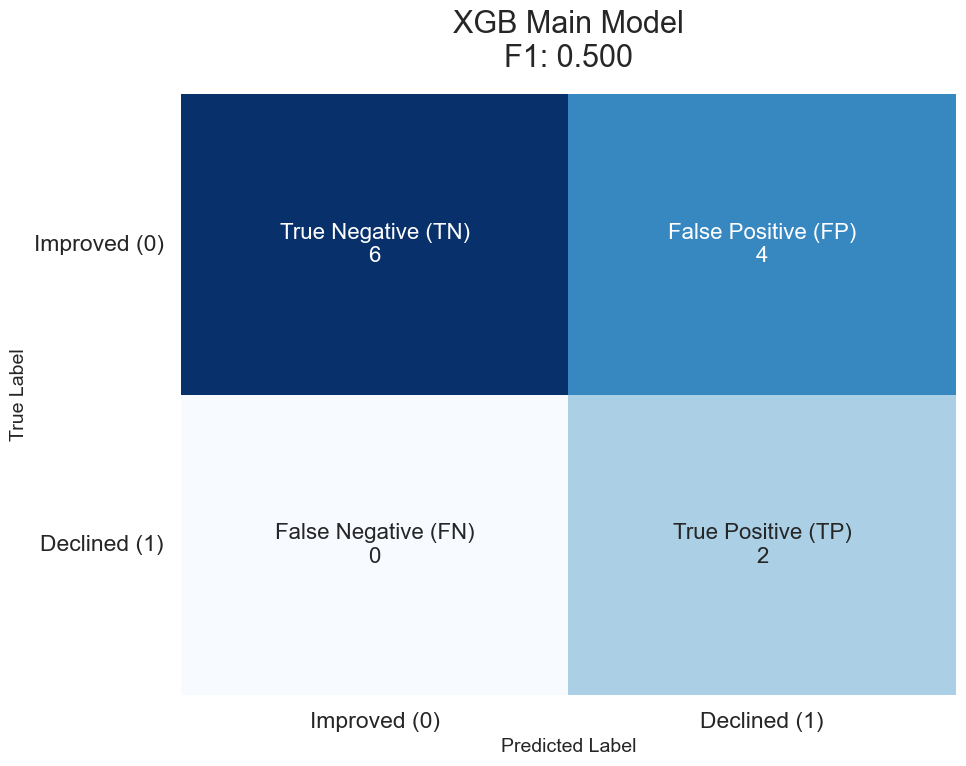

  Saved plots_xgb_main_v11_diag_v5_confusion_matrix_main_xgb.png

[PLOT-xgb] Confusion matrix (Safety-Prioritized model)...


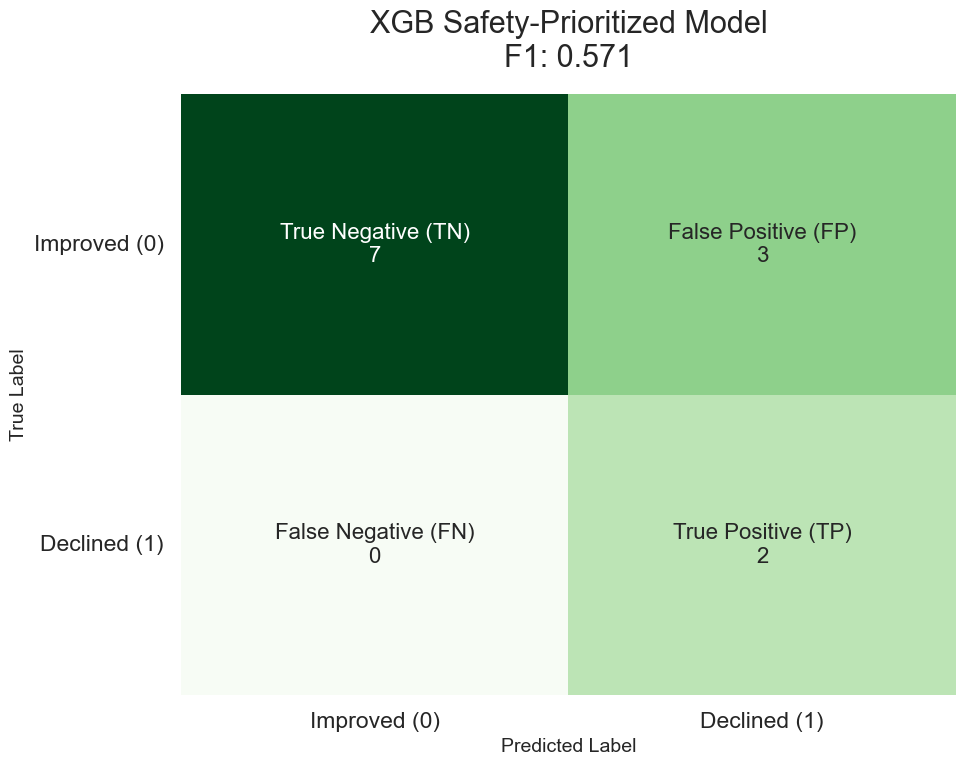

  Saved plots_xgb_main_v11_diag_v5_confusion_matrix_safety-prioritized_xgb.png

[PLOT-xgb] Confusion matrices (main vs diagnostic)...


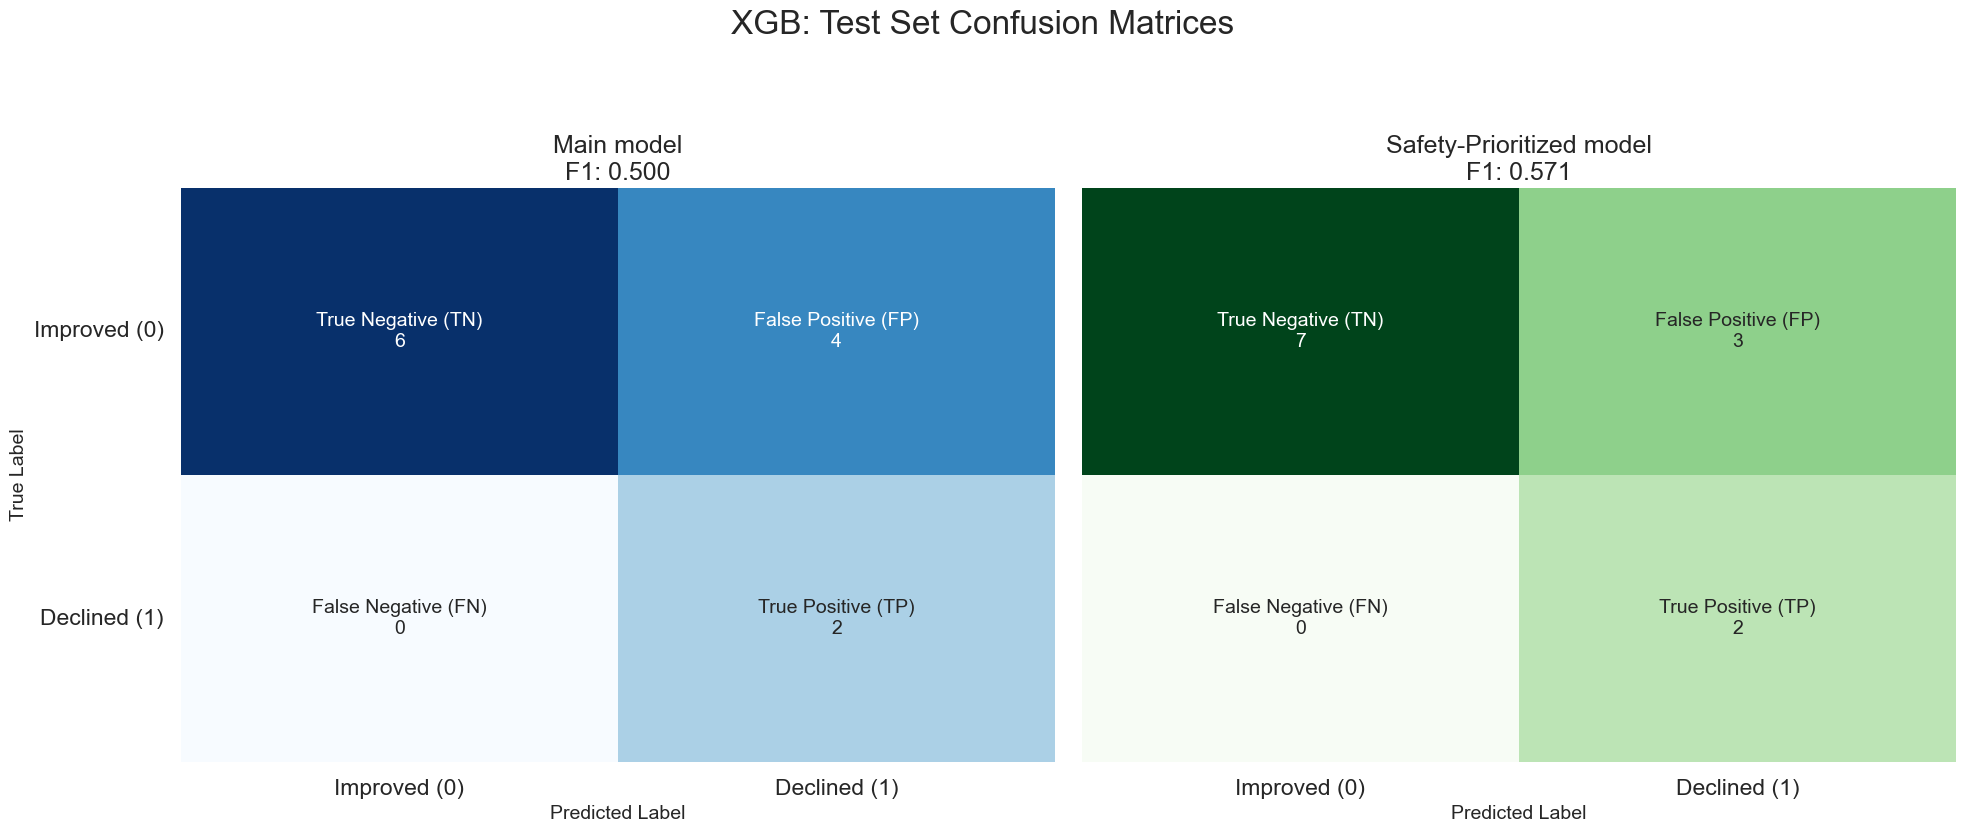

  Saved plots_xgb_main_v11_diag_v5_confusion_matrices_xgb.png

[PLOT-xgb] Test metric comparison (Main vs Safety-Prioritized)...


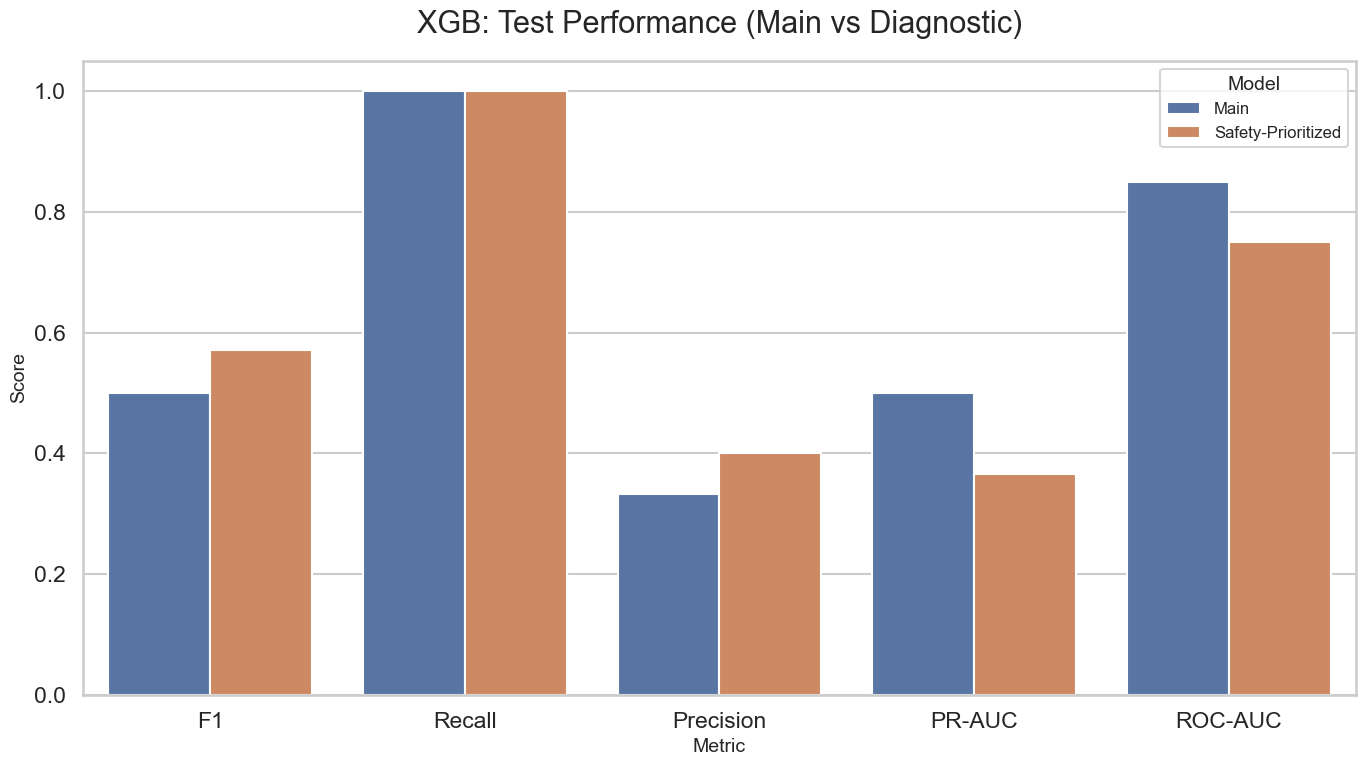

  Saved plots_xgb_main_v11_diag_v5_metrics_main_vs_diag_xgb.png

[PLOT-xgb] Probability distribution on TEST...


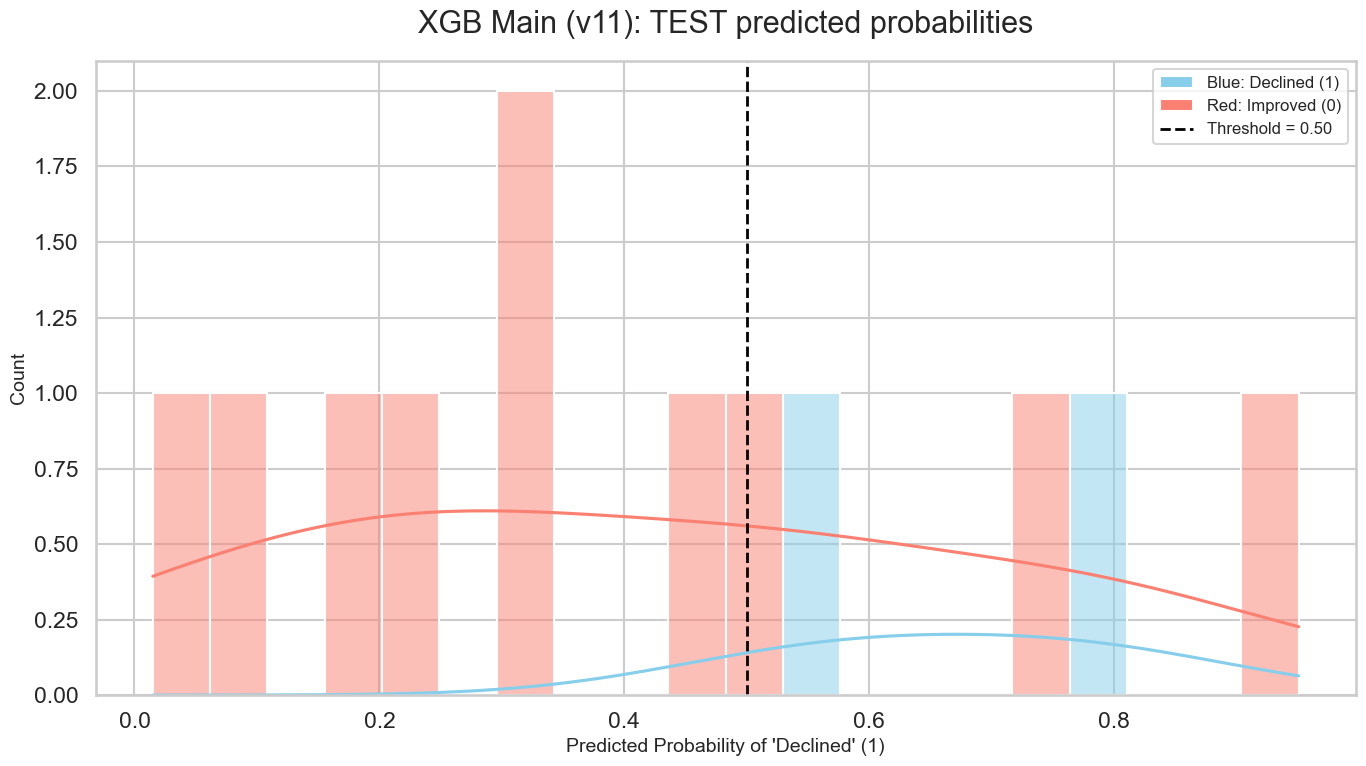

  Saved plots_xgb_main_v11_diag_v5_probability_distribution_xgb.png

[PLOT-xgb_diag] Probability distribution on TEST...


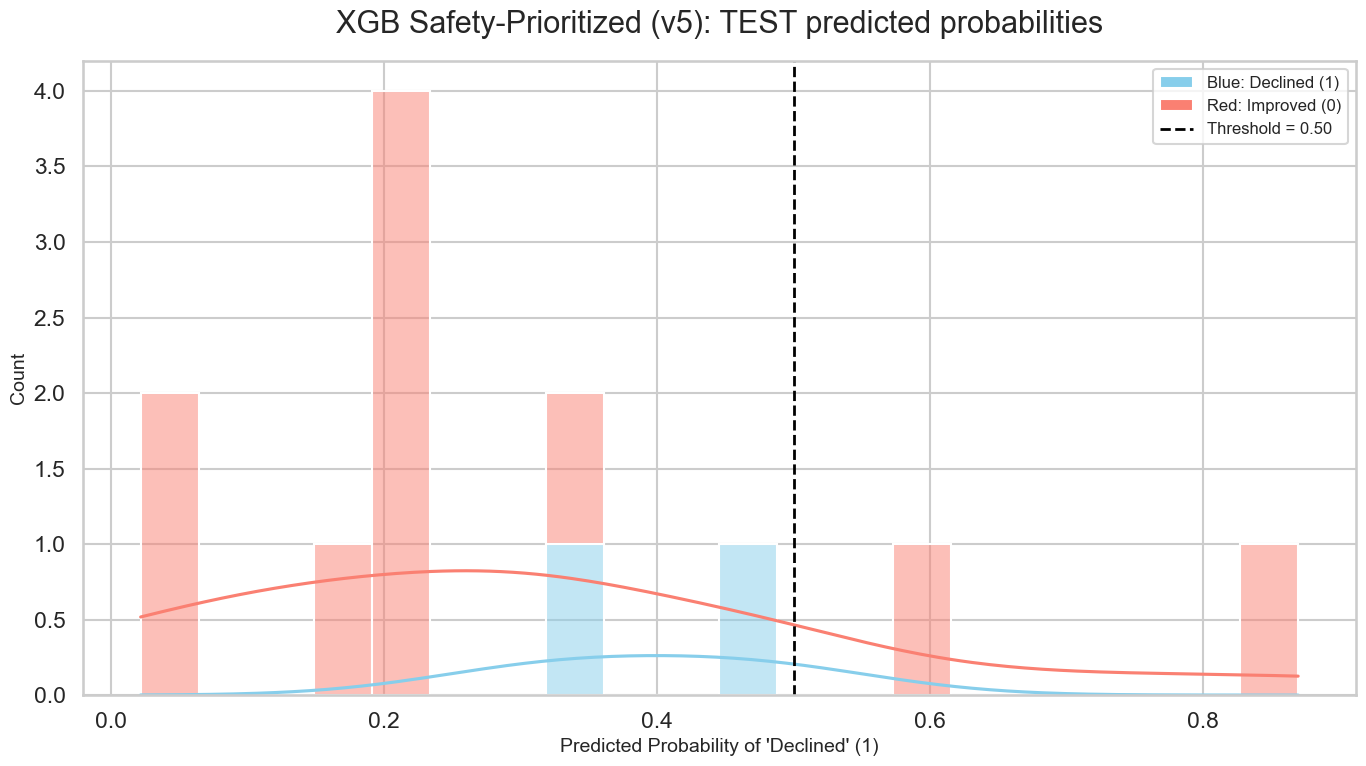

  Saved plots_xgb_main_v11_diag_v5_probability_distribution_xgb_diag.png
[xgb] Tree model: running SHAP for DIAG v5...

[PLOT-xgb] SHAP TreeExplainer (diagnostic tree model)...
  Computing SHAP values (this can be slow)...
  SHAP values computed.
  SHAP summary plot (class 1)...


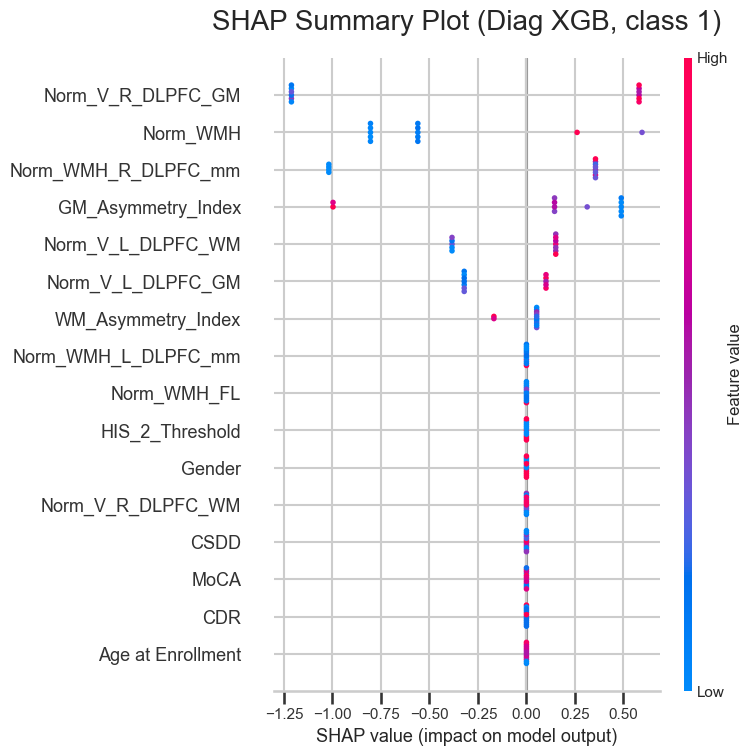

  Saved plots_xgb_main_v11_diag_v5_shap_summary_diag_xgb.png
  SHAP force plot for sample 0...
  Force plot saved to plots_xgb_main_v11_diag_v5_shap_force_sample0_diag_xgb.html
  Permutation importance (diagnostic tree) to select top features...
  Top 3 features (permutation importance): ['Age at Enrollment', 'CDR', 'MoCA']


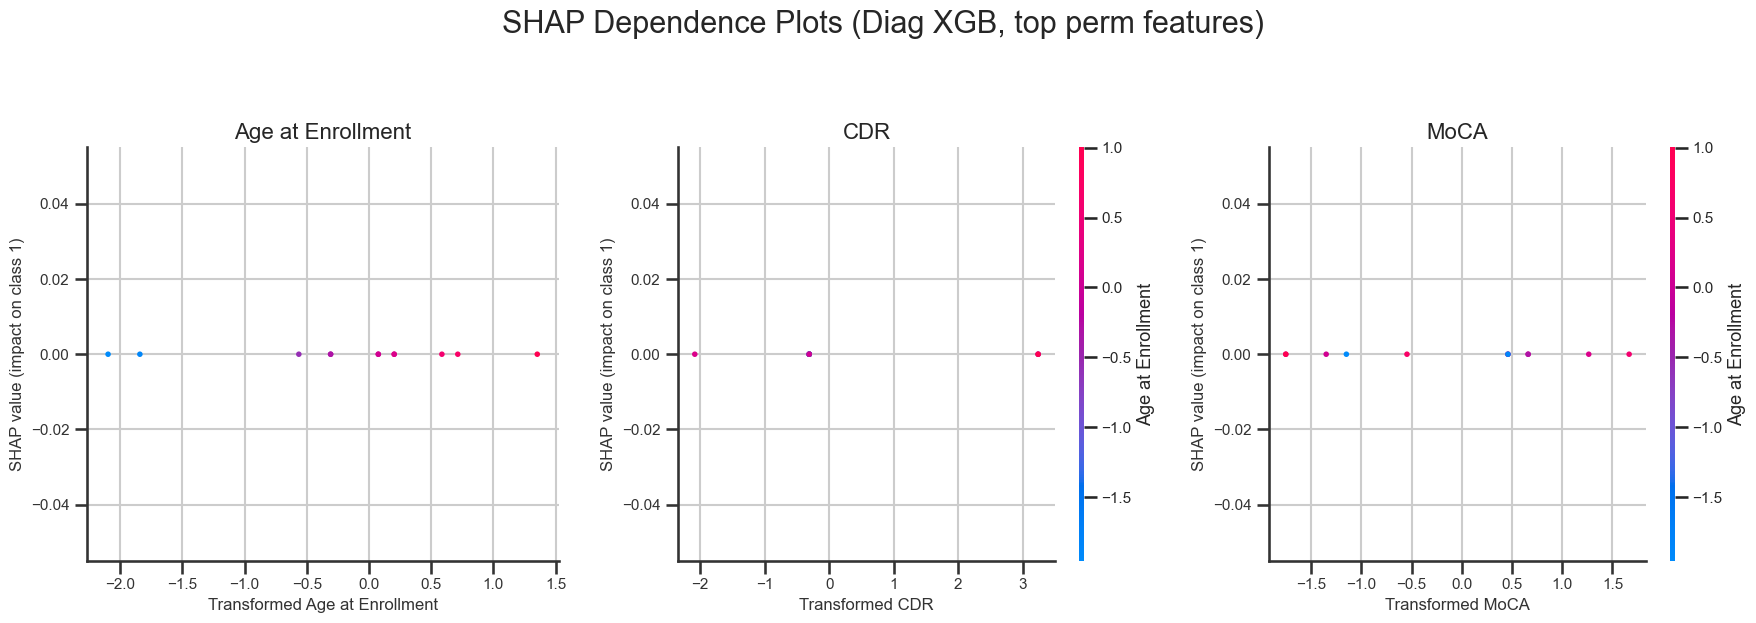

  Saved plots_xgb_main_v11_diag_v5_shap_dependence_diag_xgb.png

[PLOT-xgb_diag] Permutation importance (Diagnostic XGB (v5))...
  This may take some time...


C:\Users\arshi\AppData\Local\Temp\ipykernel_2068\1179551926.py:564: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


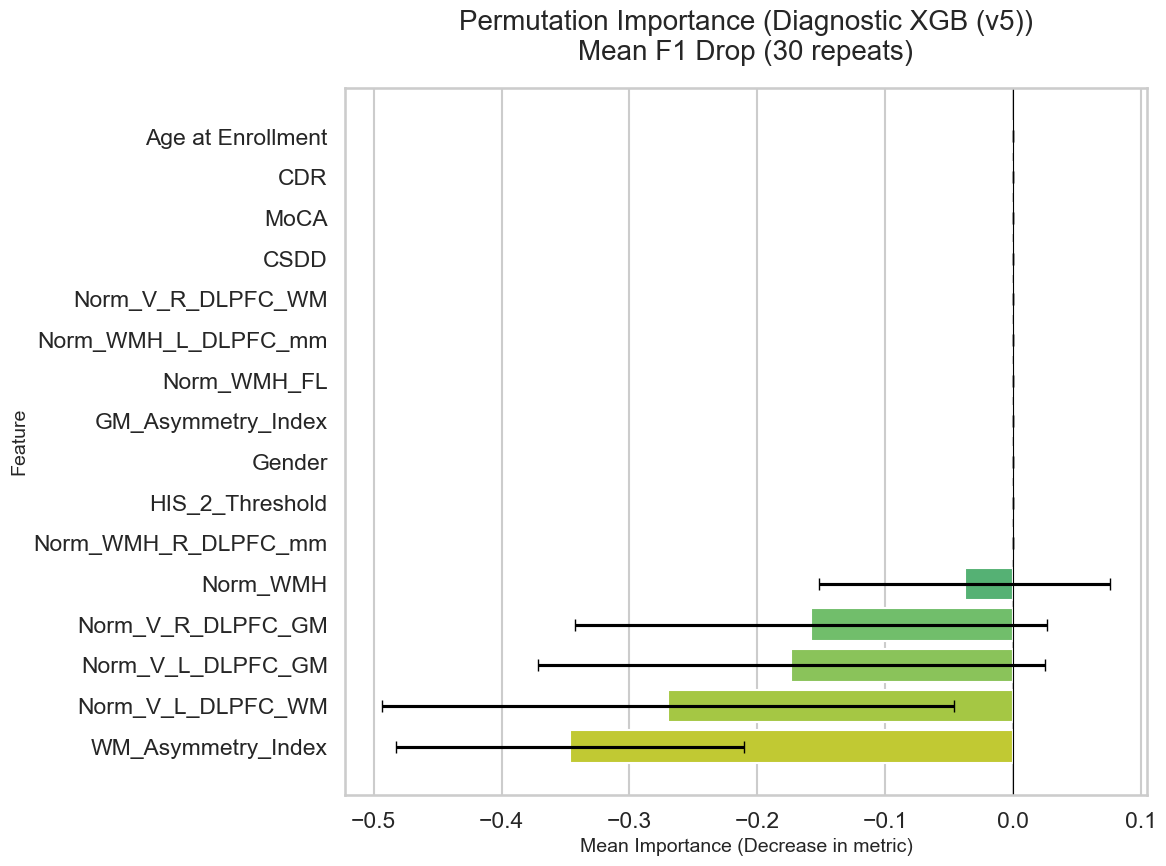

  Top 5 permutation importances:
          feature  importance_mean  importance_std
Age at Enrollment              0.0             0.0
              CDR              0.0             0.0
             MoCA              0.0             0.0
             CSDD              0.0             0.0
Norm_V_R_DLPFC_WM              0.0             0.0
  Saved plots_xgb_main_v11_diag_v5_perm_importance_xgb_diag.png


In [3]:
import os
import platform

# ============================================================
# CONFIGURATION: Set your data path here
# ============================================================
# Option 1: Google Drive Desktop App (syncs to local folder)
#   - Windows default: "G:/My Drive/..." or "C:/Users/<username>/Google Drive/..."
#   - Find your path in File Explorer where Google Drive syncs
#
# Option 2: Download data locally to this project folder
# ============================================================

if platform.system() == "Windows":
    # Local path to Google Drive folder
    PROJECT_DIR = r"D:\My Drive\Dr_Moussavi"
else:
    # Colab / Linux path
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT_DIR = "/content/drive/MyDrive/Dr_Moussavi"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"\nFiles in project directory:")
for f in os.listdir(".")[:20]:  # Show first 20 files
    print(f"  {f}")

"""
Generic Plotting and Interpretation for L1, RF, XGB
===================================================

Works with artifacts saved by the "generic_soft" pipeline:
    ROOT_MODEL_DIR/<model_tag>/...

Models:
    model_tag = "l1", "rf", "xgb"

Per-model folder contains:
    final_pipe_<tag>.pkl          : main tuned pipeline
    diag_pipe_<tag>.pkl           : diagnostic pipeline
    test_metrics_<tag>.pkl        : dict with metrics (f1, recall, precision, pr_auc, roc_auc, confusion_matrix)
    diag_metrics_<tag>.pkl
    feature_effects_<tag>.pkl     : L1: coef+odds; RF/XGB: importances
    diag_feature_effects_<tag>.pkl
    train_test_data_<tag>.pkl     : (X_train, X_test, y_train, y_test)
    feature_names_<tag>.pkl       : original feature names
    random_state_<tag>.pkl        : RND int

This script:

- Loads artifacts using a generic loader.
- Provides generic plots:
    * Confusion matrices (main vs diagnostic)
    * Test metric comparison barplots (main vs diagnostic, or across models)
    * Probability distributions of predicted probabilities
- Provides L1-specific:
    * Coefficient barplots with odds ratios
    * L1 vs diagnostic coefficient comparison
    * Permutation importance (F1 drop)
    * SHAP LinearExplainer summary and dependence plots
- Provides tree-specific (RF/XGB):
    * Feature importance comparison across RF/XGB
    * Permutation importance
    * SHAP TreeExplainer summary, force, and dependence plots

Use:
    - Call run_plots_for_model("l1")
    - Call run_plots_for_model("rf")
    - Call run_plots_for_model("xgb")
    - Call run_combined_tree_plots() for RF+XGB comparison
"""

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
import shap

ROOT_MODEL_DIR = "model_params_generic_soft"

import re

def get_model_version_dir(model_tag: str, version: int = None) -> str:
    """
    Return the directory for a given model_tag and version.

    Folder names can be:
        version_18
        version_18_l1
        version_18_something_else
    This function:
        - extracts the number immediately after 'version_'
        - ignores anything after that
    If version is None, use the highest existing version_<N*> under ROOT_MODEL_DIR/model_tag.
    """
    base_dir = os.path.join(ROOT_MODEL_DIR, model_tag)

    if not os.path.exists(base_dir):
        raise FileNotFoundError(f"No directory found for model_tag={model_tag} at {base_dir}")

    # Helper to extract version number from folder name
    def extract_version_num(name: str):
        # match 'version_' followed by digits
        m = re.match(r"version_(\d+)", name)
        if m:
            return int(m.group(1))
        return None

    # Collect (version_num, folder_name)
    candidates = []
    for name in os.listdir(base_dir):
        v = extract_version_num(name)
        if v is not None and os.path.isdir(os.path.join(base_dir, name)):
            candidates.append((v, name))

    if not candidates:
        raise FileNotFoundError(f"No version_* subfolders found in {base_dir}")

    if version is None:
        # pick highest version number
        best_v = max(v for v, _ in candidates)
    else:
        best_v = version

    # find the folder that has this version number (first match)
    for v, name in candidates:
        if v == best_v:
            version_dir = os.path.join(base_dir, name)
            print(f"[LOAD-{model_tag}] Using version {v}: {version_dir}")
            return version_dir

    raise FileNotFoundError(f"No folder with version_{best_v}* found in {base_dir}")


sns.set_theme(style="whitegrid", context="talk")


# =============================================================================
# 1. LOADING ARTIFACTS
# =============================================================================

def load_model_artifacts(model_tag: str, version: int = None):
    model_dir = get_model_version_dir(model_tag, version)
    print(f"\n[LOAD-{model_tag}] Loading artifacts from {model_dir}...")

    v_str = os.path.basename(model_dir).split("_")[1]  # '18' from 'version_18_*'

    final_pipe = joblib.load(os.path.join(model_dir, f"final_pipe_{model_tag}_v{v_str}.pkl"))
    diag_pipe = joblib.load(os.path.join(model_dir, f"diag_pipe_{model_tag}_v{v_str}.pkl"))
    test_metrics = joblib.load(os.path.join(model_dir, f"test_metrics_{model_tag}_v{v_str}.pkl"))
    diag_metrics = joblib.load(os.path.join(model_dir, f"diag_metrics_{model_tag}_v{v_str}.pkl"))
    feat_main = joblib.load(os.path.join(model_dir, f"feature_effects_{model_tag}_v{v_str}.pkl"))
    feat_diag = joblib.load(os.path.join(model_dir, f"diag_feature_effects_{model_tag}_v{v_str}.pkl"))
    X_train, X_test, y_train, y_test = joblib.load(
        os.path.join(model_dir, f"train_test_data_{model_tag}_v{v_str}.pkl")
    )
    feature_names = joblib.load(os.path.join(model_dir, f"feature_names_{model_tag}_v{v_str}.pkl"))
    rnd = joblib.load(os.path.join(model_dir, f"random_state_{model_tag}_v{v_str}.pkl"))

    print(f"  ✓ Loaded final_pipe_{model_tag}")
    print(f"  ✓ Loaded diag_pipe_{model_tag}")
    print(f"  ✓ Loaded test_metrics_{model_tag}")
    print(f"  ✓ Loaded diag_metrics_{model_tag}")
    print(f"  ✓ Loaded feature_effects_{model_tag}")
    print(f"  ✓ Loaded diag_feature_effects_{model_tag}")
    print(f"  ✓ Loaded train/test data for {model_tag}")
    print(f"  ✓ Loaded feature names and random_state_{model_tag}")
    print(f"[LOAD-{model_tag}] All artifacts loaded successfully.\n")

    return (final_pipe, diag_pipe,
            test_metrics, diag_metrics,
            feat_main, feat_diag,
            X_train, X_test, y_train, y_test,
            feature_names, rnd)


def load_main_and_diag_from_versions(model_tag: str,
                                     main_version: int,
                                     diag_version: int):
    """
    Load MAIN artifacts from main_version and DIAG artifacts from diag_version
    for the same model_tag ('l1','rf','xgb').

    MAIN (from main_version):
        - final_pipe, test_metrics, feature_effects, train_test_data,
          feature_names, random_state

    DIAG (from diag_version):
        - diag_pipe, diag_metrics, diag_feature_effects
    """
    # MAIN
    main_dir = get_model_version_dir(model_tag, main_version)
    v_main = os.path.basename(main_dir).split("_")[1]  # numeric part after 'version_'

    final_pipe = joblib.load(os.path.join(main_dir, f"final_pipe_{model_tag}_v{v_main}.pkl"))
    test_metrics = joblib.load(os.path.join(main_dir, f"test_metrics_{model_tag}_v{v_main}.pkl"))
    feat_main = joblib.load(os.path.join(main_dir, f"feature_effects_{model_tag}_v{v_main}.pkl"))
    X_train, X_test, y_train, y_test = joblib.load(
        os.path.join(main_dir, f"train_test_data_{model_tag}_v{v_main}.pkl")
    )
    feature_names = joblib.load(os.path.join(main_dir, f"feature_names_{model_tag}_v{v_main}.pkl"))
    rnd = joblib.load(os.path.join(main_dir, f"random_state_{model_tag}_v{v_main}.pkl"))

    # DIAG
    diag_dir = get_model_version_dir(model_tag, diag_version)
    v_diag = os.path.basename(diag_dir).split("_")[1]

    diag_pipe = joblib.load(os.path.join(diag_dir, f"diag_pipe_{model_tag}_v{v_diag}.pkl"))
    diag_metrics = joblib.load(os.path.join(diag_dir, f"diag_metrics_{model_tag}_v{v_diag}.pkl"))
    feat_diag = joblib.load(os.path.join(diag_dir, f"diag_feature_effects_{model_tag}_v{v_diag}.pkl"))

    print(f"\n[LOAD-{model_tag}] MAIN v{v_main} from {main_dir}")
    print(f"[LOAD-{model_tag}] DIAG v{v_diag} from {diag_dir}")

    return (final_pipe, diag_pipe,
            test_metrics, diag_metrics,
            feat_main, feat_diag,
            X_train, X_test, y_train, y_test,
            feature_names, rnd)


# =============================================================================
# 2. GENERIC PLOTS (MAIN vs DIAG FOR ONE MODEL)
# =============================================================================

def plot_confusion_matrix_single(model_tag: str, metrics: dict, model_name: str, fname_prefix: str, cmap: str = "Blues"):
    """
    Plot a single confusion matrix heatmap for one model (main or diagnostic).

    Parameters:
        model_tag: Model type ('l1', 'rf', 'xgb')
        metrics: Dictionary containing 'confusion_matrix' and 'f1'
        model_name: Display name for the model (e.g., 'Main', 'Diagnostic')
        fname_prefix: Prefix for saving the file
        cmap: Colormap for the heatmap
    """
    print(f"\n[PLOT-{model_tag}] Confusion matrix ({model_name} model)...")

    cm = metrics["confusion_matrix"]
    cm_labels = ["Improved (0)", "Declined (1)"]
    cm_quadrant_labels = [
        ["True Negative (TN)", "False Positive (FP)"],
        ["False Negative (FN)", "True Positive (TP)"],
    ]

    fig, ax = plt.subplots(figsize=(10, 8))

    labels = np.asarray([
        f"{cm_quadrant_labels[0][0]}\n{cm[0,0]}",
        f"{cm_quadrant_labels[0][1]}\n{cm[0,1]}",
        f"{cm_quadrant_labels[1][0]}\n{cm[1,0]}",
        f"{cm_quadrant_labels[1][1]}\n{cm[1,1]}"
    ]).reshape(2, 2)

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap=cmap,
        cbar=False,
        ax=ax,
        annot_kws={"size": 16},
    )
    ax.set_title(f"{model_tag.upper()} {model_name} Model\nF1: {metrics['f1']:.3f}", fontsize=22, pad=20)
    ax.set_xlabel("Predicted Label", fontsize=14)
    ax.set_ylabel("True Label", fontsize=14)
    ax.set_xticklabels(cm_labels)
    ax.set_yticklabels(cm_labels, rotation=0)

    plt.tight_layout()
    fname = f"{fname_prefix}_confusion_matrix_{model_name.lower()}_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


def plot_confusion_matrices(model_tag: str, test_metrics, diag_metrics, fname_prefix: str):
    """
    Plot two confusion matrix heatmaps: main vs diagnostic.
    """
    print(f"\n[PLOT-{model_tag}] Confusion matrices (main vs diagnostic)...")

    cm_main = test_metrics["confusion_matrix"]
    cm_diag = diag_metrics["confusion_matrix"]

    cm_labels = ["Improved (0)", "Declined (1)"]
    cm_quadrant_labels = [
        ["True Negative (TN)", "False Positive (FP)"],
        ["False Negative (FN)", "True Positive (TP)"],
    ]

    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
    fig.suptitle(f"{model_tag.upper()}: Test Set Confusion Matrices", fontsize=24, y=1.05)

    # main
    labels_main = np.asarray([
        f"{cm_quadrant_labels[0][0]}\n{cm_main[0,0]}",
        f"{cm_quadrant_labels[0][1]}\n{cm_main[0,1]}",
        f"{cm_quadrant_labels[1][0]}\n{cm_main[1,0]}",
        f"{cm_quadrant_labels[1][1]}\n{cm_main[1,1]}"
    ]).reshape(2, 2)
    sns.heatmap(
        cm_main,
        annot=labels_main,
        fmt="",
        cmap="Blues",
        cbar=False,
        ax=axes[0],
        annot_kws={"size": 14},
    )
    axes[0].set_title(f"Main model\nF1: {test_metrics['f1']:.3f}", fontsize=18)
    axes[0].set_xlabel("Predicted Label", fontsize=14)
    axes[0].set_ylabel("True Label", fontsize=14)
    axes[0].set_xticklabels(cm_labels)
    axes[0].set_yticklabels(cm_labels, rotation=0)

    # diag
    labels_diag = np.asarray([
        f"{cm_quadrant_labels[0][0]}\n{cm_diag[0,0]}",
        f"{cm_quadrant_labels[0][1]}\n{cm_diag[0,1]}",
        f"{cm_quadrant_labels[1][0]}\n{cm_diag[1,0]}",
        f"{cm_quadrant_labels[1][1]}\n{cm_diag[1,1]}"
    ]).reshape(2, 2)
    sns.heatmap(
        cm_diag,
        annot=labels_diag,
        fmt="",
        cmap="Greens",
        cbar=False,
        ax=axes[1],
        annot_kws={"size": 14},
    )
    axes[1].set_title(f"Safety-Prioritized model\nF1: {diag_metrics['f1']:.3f}", fontsize=18)
    axes[1].set_xlabel("Predicted Label", fontsize=14)
    axes[1].set_xticklabels(cm_labels)
    axes[1].set_yticklabels(cm_labels, rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 1])
    fname = f"{fname_prefix}_confusion_matrices_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


def plot_metric_comparison(model_tag: str, test_metrics, diag_metrics, fname_prefix: str, title_suffix: str = ""):
    """
    Barplot comparing F1, Recall, Precision, PR-AUC, ROC-AUC between main and safety-prioritized models.
    """
    print(f"\n[PLOT-{model_tag}] Test metric comparison (Main vs Safety-Prioritized)...")

    metrics_data = {
        "Model": ["Main", "Main", "Main", "Main", "Main",
                  "Safety-Prioritized", "Safety-Prioritized", "Safety-Prioritized", "Safety-Prioritized", "Safety-Prioritized"],
        "Metric": ["F1", "Recall", "Precision", "PR-AUC", "ROC-AUC"] * 2,
        "Score": [
            float(test_metrics["f1"]),
            float(test_metrics["recall"]),
            float(test_metrics["precision"]),
            float(test_metrics["pr_auc"]),
            float(test_metrics["roc_auc"]),
            float(diag_metrics["f1"]),
            float(diag_metrics["recall"]),
            float(diag_metrics["precision"]),
            float(diag_metrics["pr_auc"]),
            float(diag_metrics["roc_auc"]),
        ],
    }
    df = pd.DataFrame(metrics_data)

    plt.figure(figsize=(14, 8))
    ax = sns.barplot(data=df, x="Metric", y="Score", hue="Model", palette="deep")
    ax.set_title(f"{model_tag.upper()}: Test Performance (Main vs Diagnostic){title_suffix}", fontsize=22, pad=20)
    ax.set_xlabel("Metric", fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    ax.legend(title="Model", fontsize=12, title_fontsize=14, loc="upper right")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    fname = f"{fname_prefix}_metrics_main_vs_diag_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


def plot_probability_distribution(model_tag: str, pipe, X_test, y_test, threshold: float, fname_prefix: str, title: str):
    """
    Histogram of predicted probabilities, colored by true label.
    """
    print(f"\n[PLOT-{model_tag}] Probability distribution on TEST...")

    y_prob = pipe.predict_proba(X_test)[:, 1]
    df = pd.DataFrame({
        "Probability": y_prob,
        "Actual Outcome": y_test.map({0: "Improved (0)", 1: "Declined (1)"})
    })

    plt.figure(figsize=(14, 8))
    ax = sns.histplot(
        data=df,
        x="Probability",
        hue="Actual Outcome",
        multiple="stack",
        kde=True,
        bins=20,
        palette={"Improved (0)": "salmon", "Declined (1)": "skyblue"},
        legend=False
    )
    ax.set_title(title, fontsize=22, pad=20)
    ax.set_xlabel("Predicted Probability of 'Declined' (1)", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    ax.axvline(threshold, color="black", linestyle="--", linewidth=2, label=f"Threshold={threshold:.2f}")

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor="skyblue", label="Blue: Declined (1)"),
        Patch(facecolor="salmon", label="Red: Improved (0)"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label=f"Threshold = {threshold:.2f}")
    ]
    ax.legend(handles=legend_elements, fontsize=12, title_fontsize=14, loc="best")

    plt.tight_layout()
    fname = f"{fname_prefix}_probability_distribution_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


# =============================================================================
# 3. L1-SPECIFIC PLOTS
# =============================================================================

def plot_l1_coefficients(model_tag: str, coef_df: pd.DataFrame, fname_prefix: str):
    """
    Barplot of non-zero L1 coefficients with odds ratios.
    Expects columns: 'feature', 'coef', 'odds_ratio'.
    """
    print(f"\n[PLOT-{model_tag}] L1 coefficients and odds ratios...")

    df = coef_df.copy()
    df = df[df["coef"] != 0].sort_values(by="coef", ascending=False)

    plt.figure(figsize=(14, 8))
    ax = sns.barplot(data=df, x="coef", y="feature", palette="vlag")
    ax.set_title(f"{model_tag.upper()}: Selected Features, Coefficients, and Odds Ratios", fontsize=22, pad=20)
    ax.set_xlabel("Coefficient (Log-Odds)", fontsize=14)
    ax.set_ylabel("Feature", fontsize=14)
    ax.axvline(0, color="black", linewidth=0.8)

    for p in ax.patches:
        coef_val = p.get_width()
        odds_ratio = np.exp(coef_val)
        label_text = f"Coef: {coef_val:.3f}\nOR: {odds_ratio:.3f}"
        x_pos = coef_val - 0.02 if coef_val > 0 else coef_val + 0.02
        ha = "right" if coef_val > 0 else "left"
        ax.annotate(
            label_text,
            (x_pos, p.get_y() + p.get_height() / 2),
            ha=ha,
            va="center",
            fontsize=10,
            xytext=(5 if coef_val > 0 else -5, 0),
            textcoords="offset points"
        )

    plt.tight_layout()
    fname = f"{fname_prefix}_l1_coeffs_odds_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


def plot_l1_vs_diag_coeffs(model_tag: str, coef_main: pd.DataFrame, diag_pipe, fname_prefix: str):
    """
    Compare L1 vs diagnostic coefficients on same features.

    coef_main: DataFrame from feature_effects_<model_tag>.pkl
               columns at least: ['feature', 'coef']
    """
    print(f"\n[PLOT-{model_tag}] Coefficient comparison: L1 vs diagnostic...")

    # Diagnostic coefficients
    feature_names_diag = diag_pipe.named_steps["prep"].get_feature_names_out().tolist()
    coefs_diag = diag_pipe.named_steps["clf"].coef_.ravel()
    diag_coef_df = pd.DataFrame({
        "feature": feature_names_diag,
        "coef_diag": coefs_diag
    })

    coef_main = coef_main.copy()
    coef_main["coef_main"] = coef_main["coef"]

    comp_df = pd.merge(
        coef_main[["feature", "coef_main"]],
        diag_coef_df,
        on="feature",
        how="inner"
    )

    comp_melt = comp_df.melt(id_vars="feature", var_name="Model", value_name="Coefficient")
    comp_melt["Model"] = comp_melt["Model"].map({
        "coef_main": "L1 (main)",
        "coef_diag": "Diagnostic (L2-ish)"
    })

    plt.figure(figsize=(16, 10))
    ax = sns.barplot(
        data=comp_melt,
        x="Coefficient",
        y="feature",
        hue="Model",
        palette="deep"
    )
    ax.set_title("L1 vs Diagnostic Logistic Regression: Coefficient Comparison", fontsize=22, pad=20)
    ax.set_xlabel("Coefficient (Log-Odds)", fontsize=14)
    ax.set_ylabel("Feature", fontsize=14)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.legend(title="Model", fontsize=12, title_fontsize=14, loc="lower right")

    plt.tight_layout()
    fname = f"{fname_prefix}_l1_vs_diag_coeffs_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


def plot_permutation_importance_model(
    model_tag: str,
    pipe,
    X_test,
    y_test,
    rnd: int,
    scoring: str,
    fname_prefix: str,
    title: str
):
    """
    Permutation importance on TEST for a given pipeline.
    """
    print(f"\n[PLOT-{model_tag}] Permutation importance ({title})...")
    print("  This may take some time...")

    perm = permutation_importance(
        pipe,
        X_test,
        y_test,
        n_repeats=30,
        random_state=rnd,
        scoring=scoring
    )

    df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values(by="importance_mean", ascending=False)

    plt.figure(figsize=(12, 9))
    ax = sns.barplot(
        data=df,
        x="importance_mean",
        y="feature",
        palette="viridis"
    )
    ax.errorbar(
        x=df["importance_mean"],
        y=df["feature"],
        xerr=df["importance_std"],
        fmt="none",
        c="black",
        capsize=4
    )
    ax.set_title(f"Permutation Importance ({title})\nMean {scoring.upper()} Drop (30 repeats)", fontsize=20, pad=20)
    ax.set_xlabel("Mean Importance (Decrease in metric)", fontsize=14)
    ax.set_ylabel("Feature", fontsize=14)
    ax.axvline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    fname = f"{fname_prefix}_perm_importance_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print("  Top 5 permutation importances:")
    print(df.head(5).to_string(index=False))
    print(f"  Saved {fname}")


def plot_l1_shap(
    model_tag: str,
    final_pipe,
    X_train,
    X_test,
    fname_prefix: str
):
    """
    SHAP LinearExplainer for L1 logistic.

    - Summary plot
    - Force plot for a single example
    - Dependence plots for top 3 permutation-importance features
      (here we approximate top 3 using coefficient magnitude).
    """
    print(f"\n[PLOT-{model_tag}] SHAP LinearExplainer (L1)...")
    preprocessor = final_pipe.named_steps["prep"]
    classifier = final_pipe.named_steps["clf"]
    feature_names = preprocessor.get_feature_names_out()

    X_train_t = preprocessor.transform(X_train)
    X_test_t = preprocessor.transform(X_test)
    X_train_df = pd.DataFrame(X_train_t, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_t, columns=feature_names)

    explainer = shap.LinearExplainer(classifier, X_train_df)
    shap_values = explainer(X_test_df)

    # Summary plot
    print("  SHAP summary plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_df, plot_type="dot", show=False)
    plt.title("SHAP Summary Plot (L1 Logistic)", fontsize=20, pad=20)
    plt.tight_layout()
    fname_sum = f"{fname_prefix}_shap_summary_{model_tag}.png"
    plt.savefig(fname_sum, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname_sum}")

    # Force plot for one sample
    print("  SHAP force plot for sample 0...")
    sample_index = 0
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = base_value[0]

    force_plot = shap.force_plot(
        base_value=base_value,
        shap_values=shap_values.values[sample_index, :],
        features=X_test_df.iloc[sample_index, :],
        feature_names=feature_names,
        matplotlib=False,
        show=False
    )
    html_fname = f"{fname_prefix}_shap_force_sample0_{model_tag}.html"
    shap.save_html(html_fname, force_plot)
    print(f"  Force plot saved to {html_fname}")

    # Dependence plots for top 3 |coef|
    # Use abs(coef) from classifier.coef_
    coefs = classifier.coef_.ravel()
    top_idx = np.argsort(np.abs(coefs))[::-1][:3]
    top_features = [feature_names[i] for i in top_idx]

    print("  SHAP dependence plots for top 3 |coef| features...")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("SHAP Dependence Plots (Top 3 |coef| features)", fontsize=22, y=1.03)
    for i, feat in enumerate(top_features):
        shap.dependence_plot(
            ind=feat,
            shap_values=shap_values.values,
            features=X_test_df,
            feature_names=feature_names,
            ax=axes[i],
            show=False,
            interaction_index=None
        )
        axes[i].set_title(feat, fontsize=16)
        axes[i].set_ylabel("SHAP Value", fontsize=12)
        axes[i].set_xlabel(f"Transformed {feat}", fontsize=12)

    plt.tight_layout()
    fname_dep = f"{fname_prefix}_shap_dependence_{model_tag}.png"
    plt.savefig(fname_dep, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname_dep}")


# =============================================================================
# 4. TREE-SPECIFIC PLOTS AND COMBINED RF+XGB
# =============================================================================

def tree_shap_analysis(
    model_tag: str,
    diag_pipe,
    X_train, X_test, y_test,
    feature_names,
    fname_prefix: str
):
    """
    SHAP TreeExplainer for a tree-based diagnostic model (RF or XGB).
    """
    print(f"\n[PLOT-{model_tag}] SHAP TreeExplainer (diagnostic tree model)...")

    preprocessor = diag_pipe.named_steps["prep"]
    classifier = diag_pipe.named_steps["clf"]

    X_train_t = preprocessor.transform(X_train)
    X_test_t = preprocessor.transform(X_test)

    try:
        feat_names_t = preprocessor.get_feature_names_out(feature_names)
    except TypeError:
        feat_names_t = preprocessor.get_feature_names_out()

    X_train_df = pd.DataFrame(X_train_t, columns=feat_names_t)
    X_test_df = pd.DataFrame(X_test_t, columns=feat_names_t)

    # TreeExplainer
    explainer = shap.TreeExplainer(classifier, X_train_df)
    print("  Computing SHAP values (this can be slow)...")
    shap_values = explainer(X_test_df)
    print("  SHAP values computed.")

    # Handle different SHAP value formats for RF vs XGB
    # RF returns 3D (2, n_samples, n_features), XGB returns 2D (n_samples, n_features)
    if len(shap_values.values.shape) == 3:
        # RandomForest case - extract class 1
        sv_class1 = shap_values.values[:, :, 1]
        base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    else:
        # XGBoost case - already represents class 1
        sv_class1 = shap_values.values
        base_value = explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[0]

    # Summary plot (class 1)
    print("  SHAP summary plot (class 1)...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        sv_class1,
        X_test_df,
        plot_type="dot",
        show=False
    )
    plt.title(f"SHAP Summary Plot (Diag {model_tag.upper()}, class 1)", fontsize=20, pad=20)
    plt.tight_layout()
    fname_sum = f"{fname_prefix}_shap_summary_diag_{model_tag}.png"
    plt.savefig(fname_sum, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname_sum}")

    # Force plot for sample 0
    print("  SHAP force plot for sample 0...")
    sample_index = 0

    fp = shap.force_plot(
        base_value=base_value,
        shap_values=sv_class1[sample_index, :],
        features=X_test_df.iloc[sample_index, :],
        feature_names=feat_names_t,
        matplotlib=False,
        show=False
    )
    html_fname = f"{fname_prefix}_shap_force_sample0_diag_{model_tag}.html"
    shap.save_html(html_fname, fp)
    print(f"  Force plot saved to {html_fname}")

    # Dependence plots: top 3 from permutation importance
    print("  Permutation importance (diagnostic tree) to select top features...")
    perm = permutation_importance(
        diag_pipe,
        X_test,
        y_test,
        n_repeats=20,
        random_state=42,
        scoring="f1"
    )
    perm_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values(by="importance_mean", ascending=False)
    top_features = perm_df["feature"].head(3).tolist()

    print(f"  Top 3 features (permutation importance): {top_features}")

    fig, axes = plt.subplots(1, len(top_features), figsize=(6 * len(top_features), 6))
    if len(top_features) == 1:
        axes = [axes]
    fig.suptitle(f"SHAP Dependence Plots (Diag {model_tag.upper()}, top perm features)", fontsize=22, y=1.05)

    for i, feat in enumerate(top_features):
        ax = axes[i]
        shap.dependence_plot(
            ind=feat,
            shap_values=sv_class1,
            features=X_test_df,
            feature_names=feat_names_t,
            ax=ax,
            show=False,
            interaction_index="auto"
        )
        ax.set_title(f"{feat}", fontsize=16)
        ax.set_ylabel("SHAP value (impact on class 1)", fontsize=12)
        ax.set_xlabel(f"Transformed {feat}", fontsize=12)

    plt.tight_layout()
    fname_dep = f"{fname_prefix}_shap_dependence_diag_{model_tag}.png"
    plt.savefig(fname_dep, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname_dep}")


def combined_tree_importance_plot(
    feat_rf_main: pd.DataFrame,
    feat_rf_diag: pd.DataFrame,
    feat_xgb_main: pd.DataFrame,
    feat_xgb_diag: pd.DataFrame,
    fname_prefix: str
):
    """
    Combine and compare feature importances across RF/XGB main/diag.

    Assumes:
        feat_rf_main columns: ['feature','importance']
        feat_rf_diag columns: ['feature','importance_diag']
        feat_xgb_main columns: ['feature','importance']
        feat_xgb_diag columns: ['feature','importance_diag']
    """
    print("\n[PLOT-RFXGB] Combined tree feature importance comparison...")

    imp_rf_main = feat_rf_main.rename(columns={"importance": "RF (main)"})
    imp_rf_diag = feat_rf_diag.rename(columns={"importance_diag": "RF (diag)"})
    imp_xgb_main = feat_xgb_main.rename(columns={"importance": "XGB (main)"})
    imp_xgb_diag = feat_xgb_diag.rename(columns={"importance_diag": "XGB (diag)"})

    df = pd.merge(imp_rf_main, imp_rf_diag, on="feature", how="outer")
    df = pd.merge(df, imp_xgb_main, on="feature", how="outer")
    df = pd.merge(df, imp_xgb_diag, on="feature", how="outer")
    df = df.fillna(0)

    df["mean_imp"] = df[["RF (main)", "RF (diag)", "XGB (main)", "XGB (diag)"]].mean(axis=1)
    df = df.sort_values(by="mean_imp", ascending=False).drop(columns="mean_imp")

    df_melt = df.melt(id_vars="feature", var_name="Model", value_name="Importance")

    plt.figure(figsize=(16, 12))
    ax = sns.barplot(
        data=df_melt,
        x="Importance",
        y="feature",
        hue="Model",
        palette="viridis"
    )
    ax.set_title("Tree Models: Feature Importance Comparison (Gini/Gain)", fontsize=24, pad=20)
    ax.set_xlabel("Importance", fontsize=14)
    ax.set_ylabel("Feature", fontsize=14)
    ax.legend(title="Model", fontsize=12, title_fontsize=14, loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    fname = f"{fname_prefix}_tree_importance_comparison_rf_xgb.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


# =============================================================================
# 5. TOP-LEVEL WRAPPERS
# =============================================================================

def run_plots_for_model(model_tag: str, version: int = None):
    """
    Run all plots for a single model_tag ('l1','rf','xgb') and optional version.
    If version is None, latest version is used.
    """
    (final_pipe, diag_pipe,
     test_metrics, diag_metrics,
     feat_main, feat_diag,
     X_train, X_test, y_train, y_test,
     feature_names, rnd) = load_model_artifacts(model_tag, version)

    version_dir = get_model_version_dir(model_tag, version)
    version_name = os.path.basename(version_dir)  # e.g. 'version_18_inner_splits=3'
    fname_prefix = f"plots_{model_tag}_{version_name}"

    # Generic plots
    # Individual confusion matrices first
    plot_confusion_matrix_single(model_tag, test_metrics, "Main", fname_prefix, cmap="Blues")
    plot_confusion_matrix_single(model_tag, diag_metrics, "Safety-Prioritized", fname_prefix, cmap="Greens")
    # Combined confusion matrices
    plot_confusion_matrices(model_tag, test_metrics, diag_metrics, fname_prefix)
    plot_metric_comparison(model_tag, test_metrics, diag_metrics, fname_prefix)
    plot_probability_distribution(
        model_tag,
        final_pipe,
        X_test,
        y_test,
        threshold=0.5,
        fname_prefix=fname_prefix,
        title=f"{model_tag.upper()} Main model: TEST predicted probabilities"
    )
    plot_probability_distribution(
        model_tag + "_diag",
        diag_pipe,
        X_test,
        y_test,
        threshold=0.5,
        fname_prefix=fname_prefix,
        title=f"{model_tag.upper()} Safety-Prioritized model: TEST predicted probabilities"
    )

    # Model-specific
    if model_tag == "l1":
        # feat_main: columns ['feature','coef','odds_ratio',...]
        plot_l1_coefficients(model_tag, feat_main, fname_prefix)
        plot_l1_vs_diag_coeffs(model_tag, feat_main, diag_pipe, fname_prefix)
        plot_permutation_importance_model(
            model_tag,
            final_pipe,
            X_test,
            y_test,
            rnd,
            scoring="f1",
            fname_prefix=fname_prefix,
            title="L1 main model"
        )
        plot_l1_shap(model_tag, final_pipe, X_train, X_test, fname_prefix)

    elif model_tag in ("rf", "xgb"):
        # feat_main: ['feature','importance'], feat_diag: ['feature','importance_diag']
        print(f"[{model_tag}] Tree model: running SHAP for diagnostic pipeline...")
        tree_shap_analysis(
            model_tag,
            diag_pipe,
            X_train, X_test, y_test,
            feature_names,
            fname_prefix=fname_prefix
        )
        plot_permutation_importance_model(
            model_tag + "_diag",
            diag_pipe,
            X_test,
            y_test,
            rnd,
            scoring="f1",
            fname_prefix=fname_prefix,
            title=f"Diagnostic {model_tag.upper()}"
        )
    else:
        print(f"[{model_tag}] No specific extra plots configured.")


def run_plots_for_model_split(model_tag: str,
                              main_version: int,
                              diag_version: int):
    """
    Run all plots for one model_tag, using:
      - main model from main_version
      - diagnostic model from diag_version
    """
    (final_pipe, diag_pipe,
     test_metrics, diag_metrics,
     feat_main, feat_diag,
     X_train, X_test, y_train, y_test,
     feature_names, rnd) = load_main_and_diag_from_versions(
        model_tag, main_version, diag_version
    )

    fname_prefix = f"plots_{model_tag}_main_v{main_version}_diag_v{diag_version}"

    # Generic plots
    # Individual confusion matrices first
    plot_confusion_matrix_single(model_tag, test_metrics, "Main", fname_prefix, cmap="Blues")
    plot_confusion_matrix_single(model_tag, diag_metrics, "Safety-Prioritized", fname_prefix, cmap="Greens")
    # Combined confusion matrices
    plot_confusion_matrices(model_tag, test_metrics, diag_metrics, fname_prefix)
    plot_metric_comparison(model_tag, test_metrics, diag_metrics, fname_prefix)
    plot_probability_distribution(
        model_tag,
        final_pipe,
        X_test,
        y_test,
        threshold=0.5,
        fname_prefix=fname_prefix,
        title=f"{model_tag.upper()} Main (v{main_version}): TEST predicted probabilities",
    )
    plot_probability_distribution(
        model_tag + "_diag",
        diag_pipe,
        X_test,
        y_test,
        threshold=0.5,
        fname_prefix=fname_prefix,
        title=f"{model_tag.upper()} Safety-Prioritized (v{diag_version}): TEST predicted probabilities",
    )

    # Model-specific
    if model_tag == "l1":
        # feat_main: ['feature','coef','odds_ratio',...]
        plot_l1_coefficients(model_tag, feat_main, fname_prefix)
        plot_l1_vs_diag_coeffs(model_tag, feat_main, diag_pipe, fname_prefix)
        plot_permutation_importance_model(
            model_tag,
            final_pipe,
            X_test,
            y_test,
            rnd,
            scoring="f1",
            fname_prefix=fname_prefix,
            title=f"L1 main model (v{main_version})"
        )
        plot_l1_shap(model_tag, final_pipe, X_train, X_test, fname_prefix)

    elif model_tag in ("rf", "xgb"):
        print(f"[{model_tag}] Tree model: running SHAP for DIAG v{diag_version}...")
        tree_shap_analysis(
            model_tag,
            diag_pipe,
            X_train, X_test, y_test,
            feature_names,
            fname_prefix=fname_prefix
        )
        plot_permutation_importance_model(
            model_tag + "_diag",
            diag_pipe,
            X_test,
            y_test,
            rnd,
            scoring="f1",
            fname_prefix=fname_prefix,
            title=f"Diagnostic {model_tag.upper()} (v{diag_version})"
        )
    else:
        print(f"[{model_tag}] No specific extra plots configured.")


def run_combined_tree_plots(l1_version=None, rf_version=None, xgb_version=None):
    """
    Run combined RF+XGB plots:
    - metric comparison across all 6 models (L1 main/diag, RF main/diag, XGB main/diag)
    - tree feature importance comparison (RF/XGB)
    """
    print("\n[COMBINED] Loading L1, RF, XGB for combined plots...")

    # L1
    (_, _, test_l1, diag_l1,
     _, _,
     _, _, _, _, _, _) = load_model_artifacts("l1", l1_version)

    # RF
    (final_rf, diag_rf,
     test_rf, diag_rf_m,
     feat_rf_main, feat_rf_diag,
     X_train_rf, X_test_rf, y_train_rf, y_test_rf,
     feat_names_rf, rnd_rf) = load_model_artifacts("rf", rf_version)

    # XGB
    (final_xgb, diag_xgb,
     test_xgb, diag_xgb_m,
     feat_xgb_main, feat_xgb_diag,
     X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb,
     feat_names_xgb, rnd_xgb) = load_model_artifacts("xgb", xgb_version)

    # Combined metric comparison across all main/diag
    print("\n[COMBINED] Test metric comparison across L1, RF, XGB...")
    metrics_data_all = {
        "Model": [
            "L1 (main)", "L1 (main)", "L1 (main)", "L1 (main)", "L1 (main)",
            "L1 (diag)", "L1 (diag)", "L1 (diag)", "L1 (diag)", "L1 (diag)",
            "RF (main)", "RF (main)", "RF (main)", "RF (main)", "RF (main)",
            "RF (diag)", "RF (diag)", "RF (diag)", "RF (diag)", "RF (diag)",
            "XGB (main)", "XGB (main)", "XGB (main)", "XGB (main)", "XGB (main)",
            "XGB (diag)", "XGB (diag)", "XGB (diag)", "XGB (diag)", "XGB (diag)",
        ],
        "Metric": ["F1", "Recall", "Precision", "PR-AUC", "ROC-AUC"] * 6,
        "Score": [
            float(test_l1["f1"]), float(test_l1["recall"]), float(test_l1["precision"]), float(test_l1["pr_auc"]), float(test_l1["roc_auc"]),
            float(diag_l1["f1"]), float(diag_l1["recall"]), float(diag_l1["precision"]), float(diag_l1["pr_auc"]), float(diag_l1["roc_auc"]),
            float(test_rf["f1"]), float(test_rf["recall"]), float(test_rf["precision"]), float(test_rf["pr_auc"]), float(test_rf["roc_auc"]),
            float(diag_rf_m["f1"]), float(diag_rf_m["recall"]), float(diag_rf_m["precision"]), float(diag_rf_m["pr_auc"]), float(diag_rf_m["roc_auc"]),
            float(test_xgb["f1"]), float(test_xgb["recall"]), float(test_xgb["precision"]), float(test_xgb["pr_auc"]), float(test_xgb["roc_auc"]),
            float(diag_xgb_m["f1"]), float(diag_xgb_m["recall"]), float(diag_xgb_m["precision"]), float(diag_xgb_m["pr_auc"]), float(diag_xgb_m["roc_auc"]),
        ]
    }
    df_all = pd.DataFrame(metrics_data_all)
    plt.figure(figsize=(20, 10))
    ax = sns.barplot(
        data=df_all,
        x="Metric",
        y="Score",
        hue="Model",
        palette="tab20"
    )
    ax.set_title("All Models: Test Performance Comparison", fontsize=24, pad=20)
    ax.set_xlabel("Metric", fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    ax.legend(title="Model", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12, title_fontsize=14)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    fname = "plots_combined_all_models_metrics.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")

    # Tree importance comparison
    combined_tree_importance_plot(
        feat_rf_main, feat_rf_diag,
        feat_xgb_main, feat_xgb_diag,
        fname_prefix="plots_combined"
    )

def run_combined_tree_plots_split(l1_main_version: int,
                            l1_diag_version: int,
                            rf_main_version: int,
                            rf_diag_version: int,
                            xgb_main_version: int,
                            xgb_diag_version: int):
    """
    Run combined RF+XGB plots + metrics comparison using explicit
    main/diag versions for each model:
      - L1 main/diag
      - RF main/diag
      - XGB main/diag
    """
    print("\n[COMBINED] Loading L1, RF, XGB for combined plots...")

    # L1
    (_, _, test_l1, diag_l1,
     _, _,
     _, _, _, _, _, _) = load_main_and_diag_from_versions(
        "l1", l1_main_version, l1_diag_version
    )

    # RF
    (final_rf, diag_rf,
     test_rf, diag_rf_m,
     feat_rf_main, feat_rf_diag,
     X_train_rf, X_test_rf, y_train_rf, y_test_rf,
     feat_names_rf, rnd_rf) = load_main_and_diag_from_versions(
        "rf", rf_main_version, rf_diag_version
    )

    # XGB
    (final_xgb, diag_xgb,
     test_xgb, diag_xgb_m,
     feat_xgb_main, feat_xgb_diag,
     X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb,
     feat_names_xgb, rnd_xgb) = load_main_and_diag_from_versions(
        "xgb", xgb_main_version, xgb_diag_version
    )

    # Combined metric comparison across all main/diag
    print("\n[COMBINED] Test metric comparison across L1, RF, XGB...")
    metrics_data_all = {
        "Model": [
            "L1 (main)", "L1 (main)", "L1 (main)", "L1 (main)", "L1 (main)",
            "L1 (diag)", "L1 (diag)", "L1 (diag)", "L1 (diag)", "L1 (diag)",
            "RF (main)", "RF (main)", "RF (main)", "RF (main)", "RF (main)",
            "RF (diag)", "RF (diag)", "RF (diag)", "RF (diag)", "RF (diag)",
            "XGB (main)", "XGB (main)", "XGB (main)", "XGB (main)", "XGB (main)",
            "XGB (diag)", "XGB (diag)", "XGB (diag)", "XGB (diag)", "XGB (diag)",
        ],
        "Metric": ["F1", "Recall", "Precision", "PR-AUC", "ROC-AUC"] * 6,
        "Score": [
            float(test_l1["f1"]),   float(test_l1["recall"]),   float(test_l1["precision"]),   float(test_l1["pr_auc"]),   float(test_l1["roc_auc"]),
            float(diag_l1["f1"]),   float(diag_l1["recall"]),   float(diag_l1["precision"]),   float(diag_l1["pr_auc"]),   float(diag_l1["roc_auc"]),
            float(test_rf["f1"]),   float(test_rf["recall"]),   float(test_rf["precision"]),   float(test_rf["pr_auc"]),   float(test_rf["roc_auc"]),
            float(diag_rf_m["f1"]), float(diag_rf_m["recall"]), float(diag_rf_m["precision"]), float(diag_rf_m["pr_auc"]), float(diag_rf_m["roc_auc"]),
            float(test_xgb["f1"]),  float(test_xgb["recall"]),  float(test_xgb["precision"]),  float(test_xgb["pr_auc"]),  float(test_xgb["roc_auc"]),
            float(diag_xgb_m["f1"]),float(diag_xgb_m["recall"]),float(diag_xgb_m["precision"]),float(diag_xgb_m["pr_auc"]),float(diag_xgb_m["roc_auc"]),
        ]
    }
    df_all = pd.DataFrame(metrics_data_all)
    plt.figure(figsize=(20, 10))
    ax = sns.barplot(
        data=df_all,
        x="Metric",
        y="Score",
        hue="Model",
        palette="tab20"
    )
    ax.set_title("All Models: Test Performance Comparison", fontsize=24, pad=20)
    ax.set_xlabel("Metric", fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    ax.legend(title="Model", loc="center left", bbox_to_anchor=(1, 0.5),
              fontsize=12, title_fontsize=14)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    fname = "plots_combined_all_models_metrics.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")

    # Tree importance comparison (RF/XGB)
    combined_tree_importance_plot(
        feat_rf_main, feat_rf_diag,
        feat_xgb_main, feat_xgb_diag,
        fname_prefix="plots_combined"
    )


# =============================================================================
# 6. MAIN ENTRY POINTS
# =============================================================================

if __name__ == "__main__":
    # Latest versions
    # run_plots_for_model("l1")          # uses latest l1/version_*
    # run_plots_for_model("rf")          # latest rf
    # run_plots_for_model("xgb")         # latest xgb

    # Specific versions
    # run_plots_for_model("l1", version=16)
    # run_plots_for_model("rf", version=5)
    # run_plots_for_model("xgb", version=20)

    # run_combined_tree_plots(l1_version=18, rf_version=5, xgb_version=11)

    # run_combined_tree_plots()



    # # L1, RF, XGB using the same version for main and diag
    # run_plots_for_model("l1", version=16)
    # run_plots_for_model("rf", version=2)
    # run_plots_for_model("xgb", version=11)

    # # Combined metrics/importance using those same versions
    # run_combined_tree_plots(
    #     l1_main_version=16, l1_diag_version=16,
    #     rf_main_version=2,  rf_diag_version=2,
    #     xgb_main_version=11, xgb_diag_version=11
    # )



    # Example choices:
    # L1: main v16, diag v26
    # run_plots_for_model_split("l1", main_version=7, diag_version=26)

    # # RF: main v2, diag v6
    # run_plots_for_model_split("rf", main_version=2, diag_version=6)

    # # XGB: main v11 (version_11_k=5), diag v5
    run_plots_for_model_split("xgb", main_version=11, diag_version=5)


    # # ... optionally call individual splits above ...

    # run_combined_tree_plots_split(
    #     l1_main_version=16, l1_diag_version=26,
    #     rf_main_version=2,  rf_diag_version=6,
    #     xgb_main_version=11, xgb_diag_version=5
    # )



---

## 9. Appendix: Data Scaling Pipeline (Optional)

Alternative preprocessing approach using StandardScaler for numeric features.


## Picking the Best Model

In [ ]:
import os
import re
import joblib
import pandas as pd

ROOT_MODEL_DIR = "model_params_generic_soft"  # already defined in your code


def list_all_versions(model_tag: str):
    """
    Return a sorted list of (version_num, folder_name) for a given model_tag.
    Handles names like 'version_18', 'version_18_inner_splits=3', etc.
    """
    base_dir = os.path.join(ROOT_MODEL_DIR, model_tag)
    if not os.path.exists(base_dir):
        raise FileNotFoundError(f"No directory for model_tag={model_tag} at {base_dir}")

    def extract_version_num(name: str):
        m = re.match(r"version_(\d+)", name)
        if m:
            return int(m.group(1))
        return None

    versions = []
    for name in os.listdir(base_dir):
        path = os.path.join(base_dir, name)
        if not os.path.isdir(path):
            continue
        v = extract_version_num(name)
        if v is not None:
            versions.append((v, name))

    versions.sort(key=lambda x: x[0])  # sort by numeric version
    return versions


def collect_metrics_for_model(model_tag: str) -> pd.DataFrame:
    """
    Loop over all versions for a model_tag ('l1','rf','xgb'),
    load test_metrics and diag_metrics, and return a tidy DataFrame.

    Columns:
        model_tag, version, folder, which ('main' or 'diag'),
        roc_auc, pr_auc, accuracy, f1, precision, recall,
        tn, fp, fn, tp
    """
    rows = []
    versions = list_all_versions(model_tag)

    for v_num, folder_name in versions:
        version_dir = os.path.join(ROOT_MODEL_DIR, model_tag, folder_name)
        v_str = str(v_num)

        # file stems follow your save_artifacts convention: *_v{version}.pkl
        test_path = os.path.join(version_dir, f"test_metrics_{model_tag}_v{v_str}.pkl")
        diag_path = os.path.join(version_dir, f"diag_metrics_{model_tag}_v{v_str}.pkl")

        if not os.path.exists(test_path):
            # skip if somehow test_metrics not saved for this version
            continue

        test_metrics = joblib.load(test_path)
        diag_metrics = joblib.load(diag_path) if os.path.exists(diag_path) else None

        # helper to unpack one metrics dict into a row
        def add_row(which: str, m: dict):
            cm = m.get("confusion_matrix")
            if cm is not None:
                tn, fp, fn, tp = cm.ravel()
            else:
                tn = fp = fn = tp = None

            rows.append({
                "model_tag": model_tag,
                "version": v_num,
                "folder": folder_name,
                "which": which,  # "main" or "diag"
                "roc_auc": float(m.get("roc_auc", float("nan"))),
                "pr_auc": float(m.get("pr_auc", float("nan"))),
                "accuracy": float(m.get("accuracy", float("nan"))),
                "f1": float(m.get("f1", float("nan"))),
                "precision": float(m.get("precision", float("nan"))),
                "recall": float(m.get("recall", float("nan"))),
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
            })

        add_row("main", test_metrics)
        if diag_metrics is not None:
            add_row("diag", diag_metrics)

    df = pd.DataFrame(rows)
    return df


def collect_all_models_metrics() -> pd.DataFrame:
    """
    Collect metrics for all three model types into one DataFrame.
    """
    all_tags = ["l1", "rf", "xgb"]
    dfs = []
    for tag in all_tags:
        try:
            df_tag = collect_metrics_for_model(tag)
            dfs.append(df_tag)
        except FileNotFoundError:
            # model_tag may not exist yet; skip
            continue

    if not dfs:
        return pd.DataFrame()

    df_all = pd.concat(dfs, ignore_index=True)
    return df_all


def sort_metrics_df(df: pd.DataFrame,
                    sort_order=None,
                    ascending=None) -> pd.DataFrame:
    """
    Sort a metrics DataFrame with a configurable order.

    Default:
        recall ↓, f1 ↓, pr_auc ↓, model_tag ↑, which ↑
    """
    if sort_order is None:
        sort_order = ["recall", "f1", "pr_auc", "model_tag", "which"]
    if ascending is None:
        ascending = [False, False, False, True, True]

    # Only keep columns that actually exist in df (in case of per-model df without model_tag)
    cols = [c for c in sort_order if c in df.columns]
    asc = [ascending[sort_order.index(c)] for c in cols]

    return df.sort_values(by=cols, ascending=asc)


# # All models together
# df_metrics = collect_all_models_metrics()
# df_sorted_all = sort_metrics_df(df_metrics)  # or pass custom sort_order/ascending

# print(df_sorted_all[[
#     "model_tag", "version", "which",
#     "roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall",
#     "tn", "fp", "fn", "tp",
#     "folder",
# ]].to_string(index=False))

# Single model (e.g. L1)
df_l1 = collect_metrics_for_model("xgb")
df_l1_sorted = sort_metrics_df(df_l1, ["recall", "pr_auc", "f1"], [False, False, False])

print(df_l1_sorted[[
    "model_tag", "version", "which",
    "roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall",
    "tn", "fp", "fn", "tp",
    "folder",
]].to_string(index=False))


model_tag  version which  roc_auc   pr_auc  accuracy       f1  precision  recall  tn  fp  fn  tp                   folder
      xgb       11  main     0.85 0.500000  0.666667 0.500000   0.333333     1.0   6   4   0   2           version_11_K=5
      xgb       12  main     0.80 0.450000  0.500000 0.400000   0.250000     1.0   4   6   0   2 version_12_k=7_inner_f=5
      xgb        6  main     0.80 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2                version_6
      xgb        8  main     0.80 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2                version_8
      xgb        9  main     0.80 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2      version_9_SMOTE_k=2
      xgb       10  main     0.75 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2     version_10_SMOTE_K=1
      xgb       13  main     0.75 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2               version_13
      xgb       14  main

In [ ]:
# import pandas as pd
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline

# # -------------------------------------------------------------------
# # DATA SCALING PIPELINE
# # -------------------------------------------------------------------
# # Assuming 'df_analysis_binary_1_a' is your current dataframe
# df = df_analysis_binary_1_a.copy()

# # 1. Define Columns
# target_col = "w5_change_binary_one_threshold"

# # Binary columns (0/1) - We usually do NOT scale these, just pass them through
# binary_cols = ["Gender", "HIS_2_Threshold"]

# # Feature columns are everything else (excluding target and binaries)
# feature_cols = [c for c in df.columns if c not in [target_col] + binary_cols]

# print(f"Features to Scale ({len(feature_cols)}): {feature_cols}")
# print(f"Features to Passthrough ({len(binary_cols)}): {binary_cols}")

# # 2. Define the Preprocessor
# preproc = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), feature_cols),
#         ("bin", "passthrough", binary_cols),
#     ],
#     remainder="drop", # Drops the target column from X automatically
#     verbose_feature_names_out=False,
# )

# # 3. Create the Pipeline
# pipe = Pipeline([("prep", preproc)])

# # 4. Fit and Transform
# # We drop the target column before passing to the pipeline
# X_scaled_array = pipe.fit_transform(df.drop(columns=[target_col]))

# # 5. Rebuild the DataFrame
# # Get the new column names from the transformer (ensures correct order)
# scaled_feature_names = pipe.named_steps["prep"].get_feature_names_out()

# df_scaled = pd.DataFrame(X_scaled_array, columns=scaled_feature_names, index=df.index)

# # Add the target column back (ensure it's int for classification)
# df_scaled[target_col] = df[target_col].astype(int)

# print("-" * 30)
# print("Scaling Complete. New DataFrame: 'df_scaled'")

Features to Scale (14): ['Age at Enrollment', 'CDR', 'MoCA', 'CSDD', 'Norm_V_R_DLPFC_GM', 'Norm_V_L_DLPFC_GM', 'Norm_V_R_DLPFC_WM', 'Norm_V_L_DLPFC_WM', 'GM_Asymmetry_Index', 'WM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_FL', 'Norm_WMH_R_DLPFC_mm', 'Norm_WMH_L_DLPFC_mm']
Features to Passthrough (2): ['Gender', 'HIS_2_Threshold']
------------------------------
Scaling Complete. New DataFrame: 'df_scaled'


In [ ]:
# df_scaled.head(5)

,Age at Enrollment,CDR,MoCA,CSDD,Norm_V_R_DLPFC_GM,Norm_V_L_DLPFC_GM,Norm_V_R_DLPFC_WM,Norm_V_L_DLPFC_WM,GM_Asymmetry_Index,WM_Asymmetry_Index,Norm_WMH,Norm_WMH_FL,Norm_WMH_R_DLPFC_mm,Norm_WMH_L_DLPFC_mm,Gender,HIS_2_Threshold,w5_change_binary_one_threshold
0,-0.148884,2.647999,0.461499,0.411013,0.068271,1.021631,-0.962911,0.357411,0.744503,-0.451694,-0.458336,-0.346573,-0.325539,-0.160615,1.0,0.0,0
1,-0.019999,-0.334213,-0.320018,3.425112,1.157598,-0.015856,-1.284041,-0.099620,-0.914433,-0.557809,0.869785,0.800039,1.234028,-0.113107,1.0,1.0,0
2,1.139963,-0.334213,1.243016,0.959031,-0.786329,0.657551,-0.598165,-1.846827,1.442778,1.627798,-0.473017,-0.435255,-0.325539,-0.179248,1.0,1.0,0
3,0.753309,-0.334213,-0.515397,-0.685022,-1.191166,-0.695212,1.279258,0.330020,0.183841,0.508602,1.206631,0.765836,0.655057,-0.171912,1.0,1.0,0
4,-1.308847,-0.334213,0.070741,-0.137004,-0.582435,-0.585135,-0.643797,-0.601749,-0.545521,-0.334202,-0.107248,-0.098417,-0.263946,-0.098160,0.0,0.0,0
